In [2]:
# importing all the libraries i need
import os
import time
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, Model, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

np.random.seed(42)
tf.random.set_seed(42)

# setting up plot style same as previous experiments
# 600 dpi, Times New Roman font, save as .eps
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.dpi'] = 600


def save_plot(filename):
    plt.savefig(f"{filename}.eps", format='eps', dpi=600, bbox_inches='tight')
    print(f"saved {filename}.eps")

In [3]:
# downloading and extracting the UCI HAR dataset (raw inertial signals, not the
# 561 feature vectors) if it isn't already present in the working directory
DATA_DIR = "UCI HAR Dataset"
ZIP_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
ZIP_PATH = "UCI_HAR_Dataset.zip"

if not os.path.isdir(DATA_DIR):
    print("dataset not found locally, downloading...")
    urllib.request.urlretrieve(ZIP_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("download and extraction done")
else:
    print("dataset already present, skipping download")


dataset already present, skipping download


In [4]:
# the 9 raw signal files that make up the 9 channels per the manual
SIGNAL_NAMES = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z"
]

ACTIVITY_NAMES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
                  "SITTING", "STANDING", "LAYING"]


def load_signals(subset):
    """subset is either 'train' or 'test'. Returns array of shape (N, 128, 9)."""
    signals = []
    for name in SIGNAL_NAMES:
        path = os.path.join(DATA_DIR, subset, "Inertial Signals", f"{name}_{subset}.txt")
        channel = np.loadtxt(path)
        signals.append(channel)
    # each channel is (N, 128), stacking along a new last axis gives (N, 128, 9)
    return np.transpose(np.array(signals), (1, 2, 0))


def load_labels(subset):
    path = os.path.join(DATA_DIR, subset, f"y_{subset}.txt")
    y = np.loadtxt(path).astype(int) - 1  # labels are 1-6, converting to 0-5
    return y


X_train_full = load_signals("train")
y_train_full = load_labels("train")
X_test_full = load_signals("test")
y_test_full = load_labels("test")

print("Raw train signals shape:", X_train_full.shape)
print("Raw test signals shape :", X_test_full.shape)

Raw train signals shape: (7352, 128, 9)
Raw test signals shape : (2947, 128, 9)


In [5]:
# recommended lab subset - taking first ~2000 windows from the training partition
# while keeping all six classes represented in roughly balanced numbers
def stratified_subsample(X, y, n_per_class):
    idx_list = []
    for c in np.unique(y):
        class_idx = np.where(y == c)[0][:n_per_class]
        idx_list.append(class_idx)
    idx = np.concatenate(idx_list)
    np.random.shuffle(idx)
    return X[idx], y[idx]


N_PER_CLASS = 330  # roughly gives ~2000 total windows across 6 classes
X_sub, y_sub = stratified_subsample(X_train_full, y_train_full, N_PER_CLASS)
print("Subsampled training pool shape:", X_sub.shape)

Subsampled training pool shape: (1980, 128, 9)


In [6]:
# 70 / 15 / 15 split - splitting the subsampled pool into train/val, and using
# the official UCI test partition as the held-out test set
X_train, X_val, y_train, y_val = train_test_split(
    X_sub, y_sub, test_size=0.176, stratify=y_sub, random_state=42
)  # 0.176 of the 85% pool ~= 15% of the original whole

X_test, y_test = X_test_full, y_test_full


In [7]:
# normalizing using statistics computed ONLY on the training data
train_mean = X_train.mean(axis=(0, 1), keepdims=True)
train_std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_norm = (X_train - train_mean) / train_std
X_val_norm = (X_val - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std


In [8]:
# required preprocessing output
print("Input tensor shape:")
print("Training  :", X_train_norm.shape)
print("Validation:", X_val_norm.shape)
print("Testing   :", X_test_norm.shape)
print("Number of classes:", len(ACTIVITY_NAMES))
print("Number of features per time step:", X_train_norm.shape[2])
print("Sequence length:", X_train_norm.shape[1])


Input tensor shape:
Training  : (1631, 128, 9)
Validation: (349, 128, 9)
Testing   : (2947, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128


In [9]:
# verifying class distribution across the three splits
for split_name, labels in [("train", y_train), ("val", y_val), ("test", y_test)]:
    classes, counts = np.unique(labels, return_counts=True)
    print(f"{split_name} distribution:", dict(zip([ACTIVITY_NAMES[c] for c in classes], counts)))

# Inference: the stratified subsampling keeps all six classes roughly balanced
# in the training and validation sets, and the official test set is left
# completely untouched so it stays a fair measure of generalisation.


train distribution: {'WALKING': np.int64(272), 'WALKING_UPSTAIRS': np.int64(272), 'WALKING_DOWNSTAIRS': np.int64(272), 'SITTING': np.int64(271), 'STANDING': np.int64(272), 'LAYING': np.int64(272)}
val distribution: {'WALKING': np.int64(58), 'WALKING_UPSTAIRS': np.int64(58), 'WALKING_DOWNSTAIRS': np.int64(58), 'SITTING': np.int64(59), 'STANDING': np.int64(58), 'LAYING': np.int64(58)}
test distribution: {'WALKING': np.int64(496), 'WALKING_UPSTAIRS': np.int64(471), 'WALKING_DOWNSTAIRS': np.int64(420), 'SITTING': np.int64(491), 'STANDING': np.int64(532), 'LAYING': np.int64(537)}


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved temporal_signals.eps


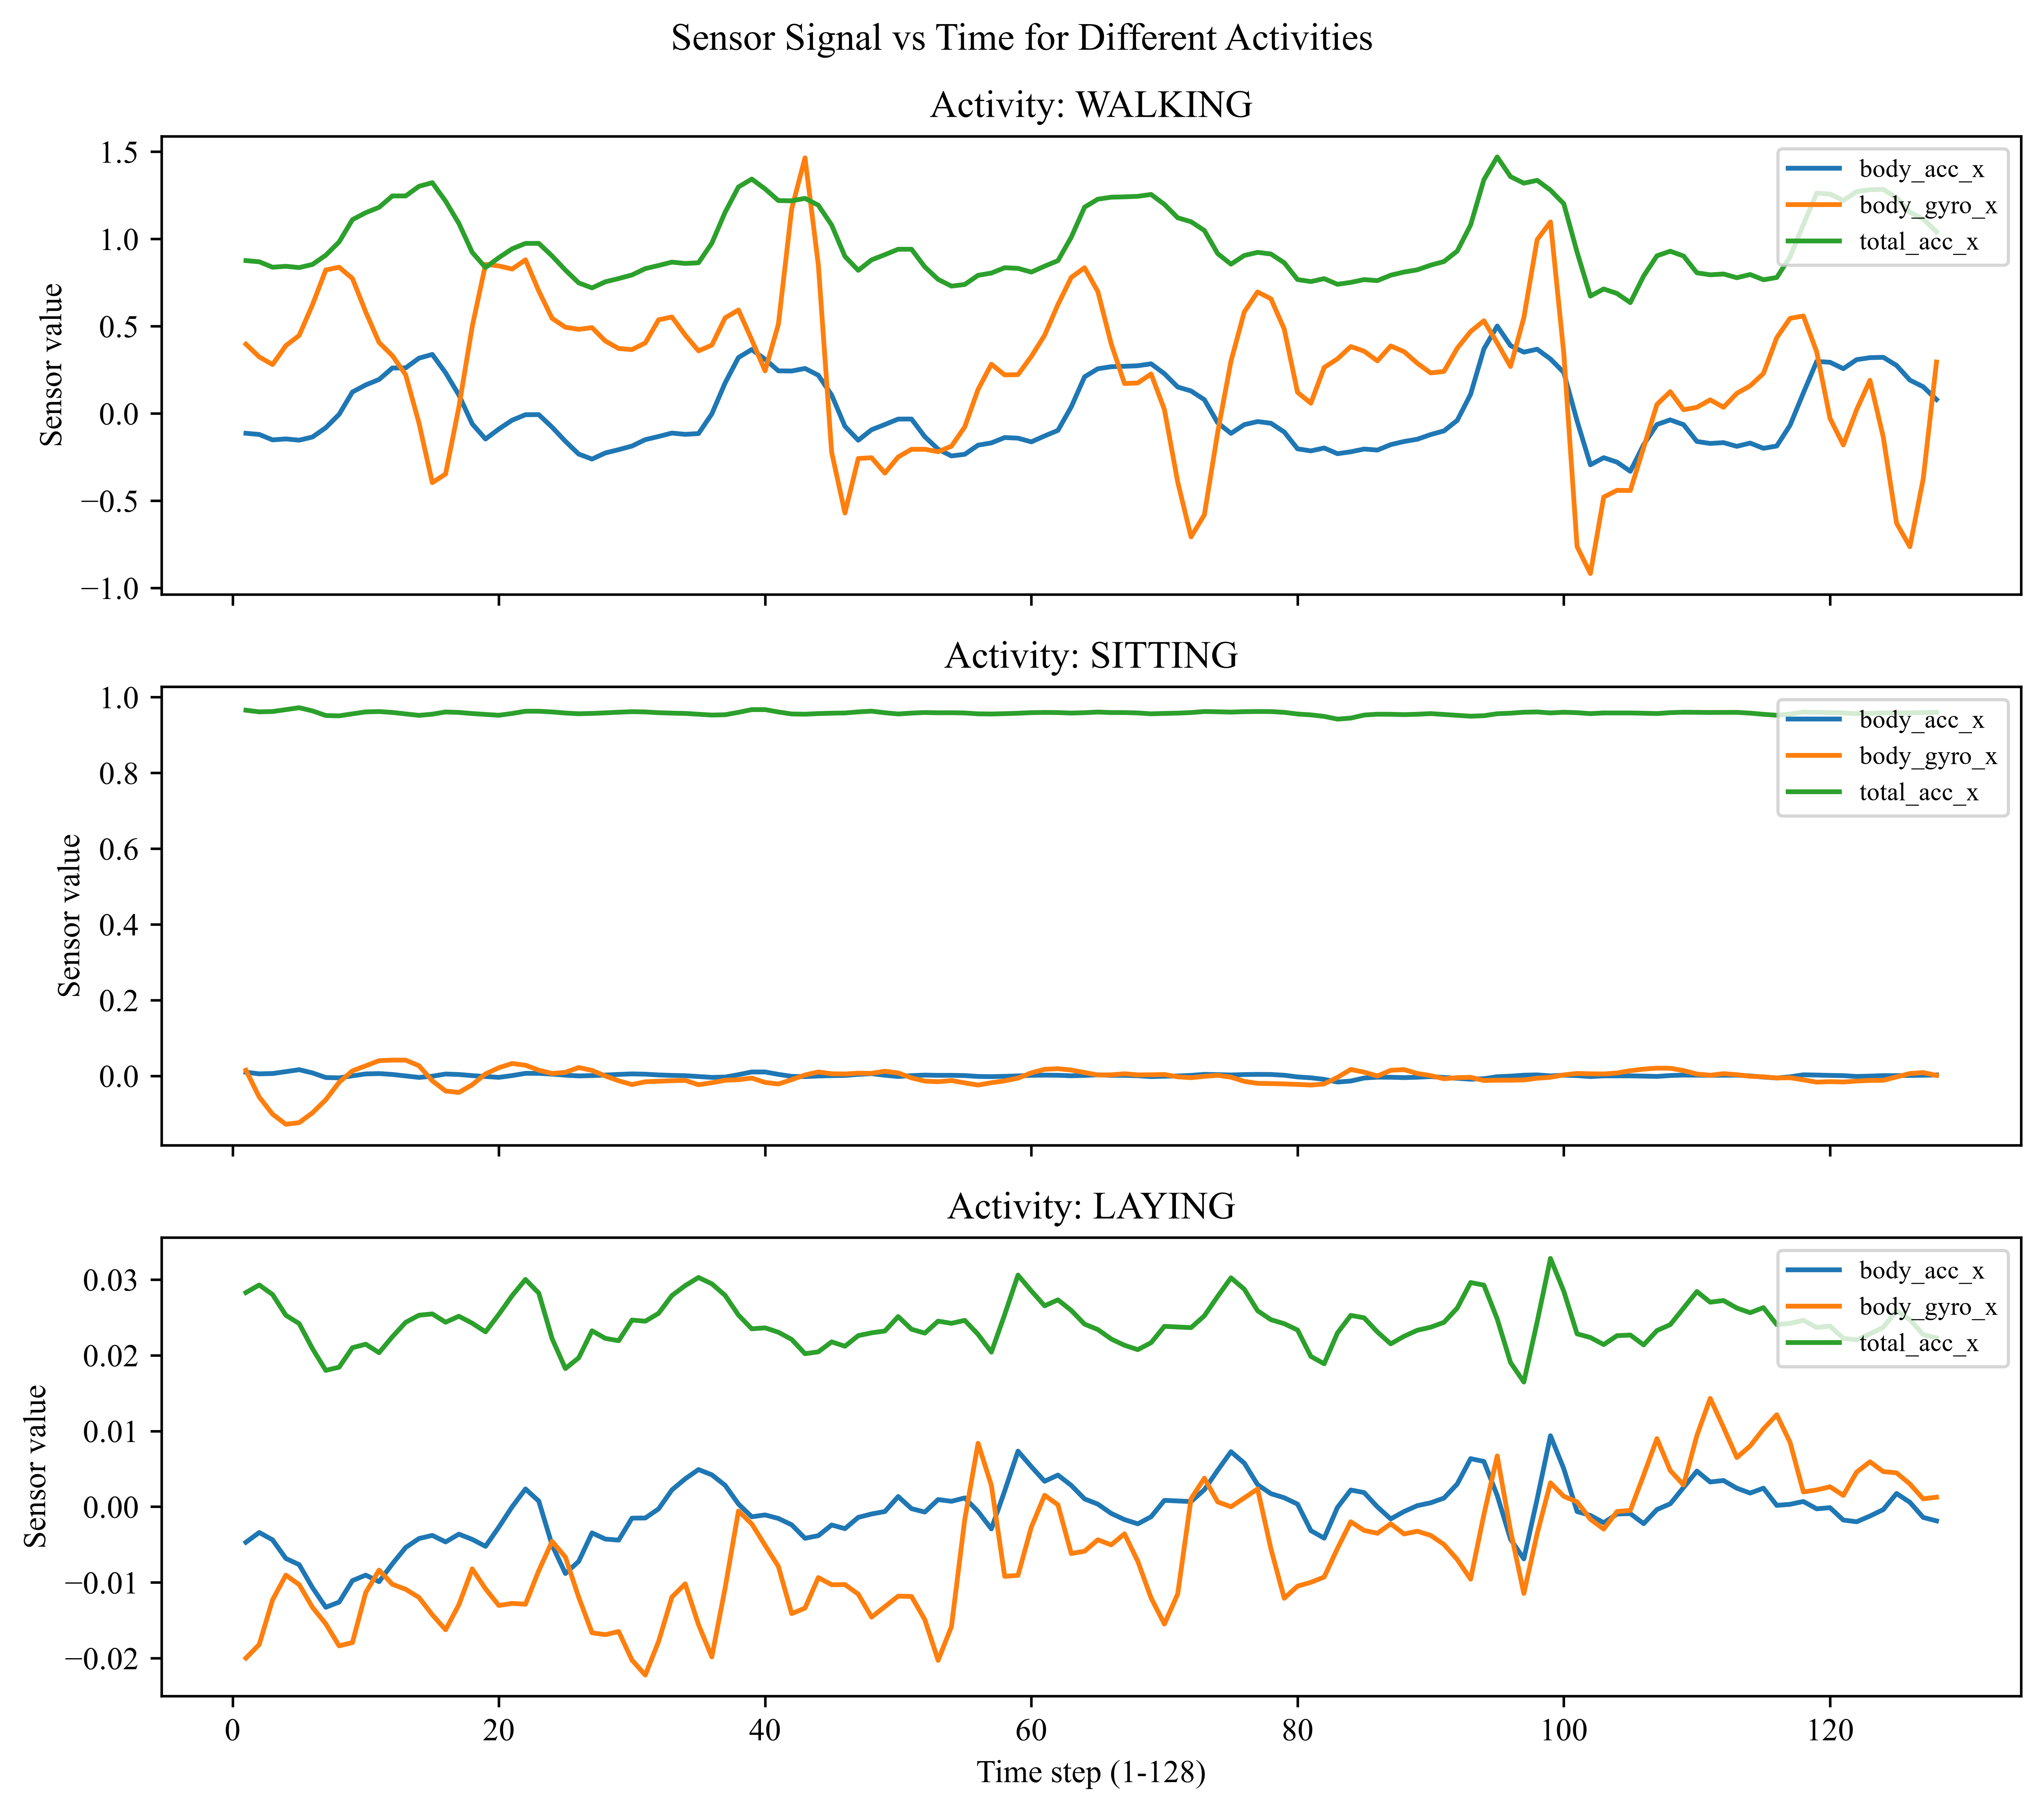

In [10]:
# plot 1 - picking one representative window from three different activities
# and plotting three of the nine channels against time
activities_to_plot = ["WALKING", "SITTING", "LAYING"]
channels_to_plot = [0, 3, 6]  # body_acc_x, body_gyro_x, total_acc_x
channel_labels = ["body_acc_x", "body_gyro_x", "total_acc_x"]

fig, axes = plt.subplots(len(activities_to_plot), 1, figsize=(9, 8), sharex=True)
for row, act_name in enumerate(activities_to_plot):
    act_idx = ACTIVITY_NAMES.index(act_name)
    sample_idx = np.where(y_train == act_idx)[0][0]
    sample = X_train[sample_idx]  # unnormalized, easier to read visually
    for ch, label in zip(channels_to_plot, channel_labels):
        axes[row].plot(range(1, 129), sample[:, ch], label=label)
    axes[row].set_title(f"Activity: {act_name}")
    axes[row].set_ylabel("Sensor value")
    axes[row].legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel("Time step (1-128)")
plt.suptitle("Sensor Signal vs Time for Different Activities")
plt.tight_layout()
save_plot("temporal_signals")
plt.show()

# Inference:
# 1. What temporal pattern is visible? WALKING shows a clear repeating
#    oscillation because the body accelerates and decelerates with every
#    step, while LAYING is almost flat since there is very little movement.
# 2. Which activities exhibit similar patterns? SITTING and STANDING (not
#    plotted here) look similar to LAYING in that they are all low-motion,
#    static postures, so they are harder to tell apart from signal shape alone.
# 3. Why is the ordering of measurements important? The activity is defined
#    by how the signal changes over time (e.g. the rhythm of footsteps), so
#    shuffling the time steps would destroy that information completely.


In [11]:
# manually computing h1, h2, h3 using ht = tanh(Wx*xt + Wh*ht-1 + b)
x_vals = [0.5, 0.7, 0.2]
Wx, Wh, b = 0.5, 0.8, 0.1
h_prev = 0.0

print("Manual BPTT calculation:")
for t, xt in enumerate(x_vals, start=1):
    z = Wx * xt + Wh * h_prev + b
    h_t = np.tanh(z)
    print(f"h{t} = tanh({Wx}*{xt} + {Wh}*{h_prev:.4f} + {b}) = tanh({z:.4f}) = {h_t:.4f}")
    h_prev = h_t

# Inference: each hidden state depends on the previous one, so the same pair
# of weights (Wx, Wh) is applied repeatedly. Because the same Wh is reused at
# every step, if |Wh| < 1 the contribution of early inputs shrinks with every
# multiplication (vanishing gradient tendency), and if |Wh| > 1 it would grow
# without bound (exploding gradient tendency).

Manual BPTT calculation:
h1 = tanh(0.5*0.5 + 0.8*0.0000 + 0.1) = tanh(0.3500) = 0.3364
h2 = tanh(0.5*0.7 + 0.8*0.3364 + 0.1) = tanh(0.7191) = 0.6164
h3 = tanh(0.5*0.2 + 0.8*0.6164 + 0.1) = tanh(0.6931) = 0.6000


In [12]:
NUM_CLASSES = len(ACTIVITY_NAMES)
INPUT_SHAPE = (X_train_norm.shape[1], X_train_norm.shape[2])  # (128, 9)


def build_model(recurrent_type, units=32, input_shape=INPUT_SHAPE):
    """Builds the classifier described in the manual, swapping only the
    recurrent layer between SimpleRNN, LSTM and GRU."""
    if recurrent_type == "RNN":
        rec_layer = layers.SimpleRNN(units)
    elif recurrent_type == "LSTM":
        rec_layer = layers.LSTM(units)
    elif recurrent_type == "GRU":
        rec_layer = layers.GRU(units)
    else:
        raise ValueError("unknown recurrent_type")

    model = models.Sequential([
        layers.Input(shape=input_shape),
        rec_layer,
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


def train_and_evaluate(recurrent_type, X_tr, y_tr, X_va, y_va, X_te, y_te,
                        units=32, epochs=30, batch_size=32, verbose=0):
    """Trains one model and returns history plus all the required metrics."""
    model = build_model(recurrent_type, units=units, input_shape=(X_tr.shape[1], X_tr.shape[2]))

    start = time.time()
    history = model.fit(X_tr, y_tr,
                         validation_data=(X_va, y_va),
                         epochs=epochs, batch_size=batch_size, verbose=verbose)
    train_time = time.time() - start

    y_pred = np.argmax(model.predict(X_te, verbose=0), axis=1)

    results = {
        "model": model,
        "history": history,
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred, average='macro', zero_division=0),
        "recall": recall_score(y_te, y_pred, average='macro', zero_division=0),
        "f1": f1_score(y_te, y_pred, average='macro', zero_division=0),
        "confusion_matrix": confusion_matrix(y_te, y_pred),
        "params": model.count_params(),
        "train_time": train_time,
        "y_pred": y_pred
    }
    print(f"[{recurrent_type}] acc={results['accuracy']:.4f}  "
          f"prec={results['precision']:.4f}  rec={results['recall']:.4f}  "
          f"f1={results['f1']:.4f}  params={results['params']}  "
          f"time={results['train_time']:.1f}s")
    return results



In [13]:
# training the three models with identical settings so the comparison is fair
results = {}
for rec_type in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {rec_type} ...")
    results[rec_type] = train_and_evaluate(
        rec_type, X_train_norm, y_train, X_val_norm, y_val, X_test_norm, y_test,
        units=32, epochs=30, batch_size=32, verbose=0
    )

# Inference (role of gates - required for the LSTM section): the forget gate
# lets the LSTM drop information from the cell state that is no longer
# relevant, the input gate lets it write new information in, and because the
# cell state is updated mostly by addition/multiplication with these gates
# (rather than being fully recomputed every step like a plain RNN's hidden
# state), gradients can flow through many time steps without vanishing as
# quickly - this is what lets LSTM (and GRU, through its update gate) retain
# useful signal from much earlier in the 128-step window than a vanilla RNN.


Training RNN ...
[RNN] acc=0.7353  prec=0.7376  rec=0.7319  f1=0.7313  params=1974  time=13.5s

Training LSTM ...
[LSTM] acc=0.8846  prec=0.8890  rec=0.8855  f1=0.8843  params=6006  time=26.8s

Training GRU ...
[GRU] acc=0.8436  prec=0.8458  rec=0.8437  f1=0.8413  params=4758  time=41.2s


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved rnn_loss_curve.eps


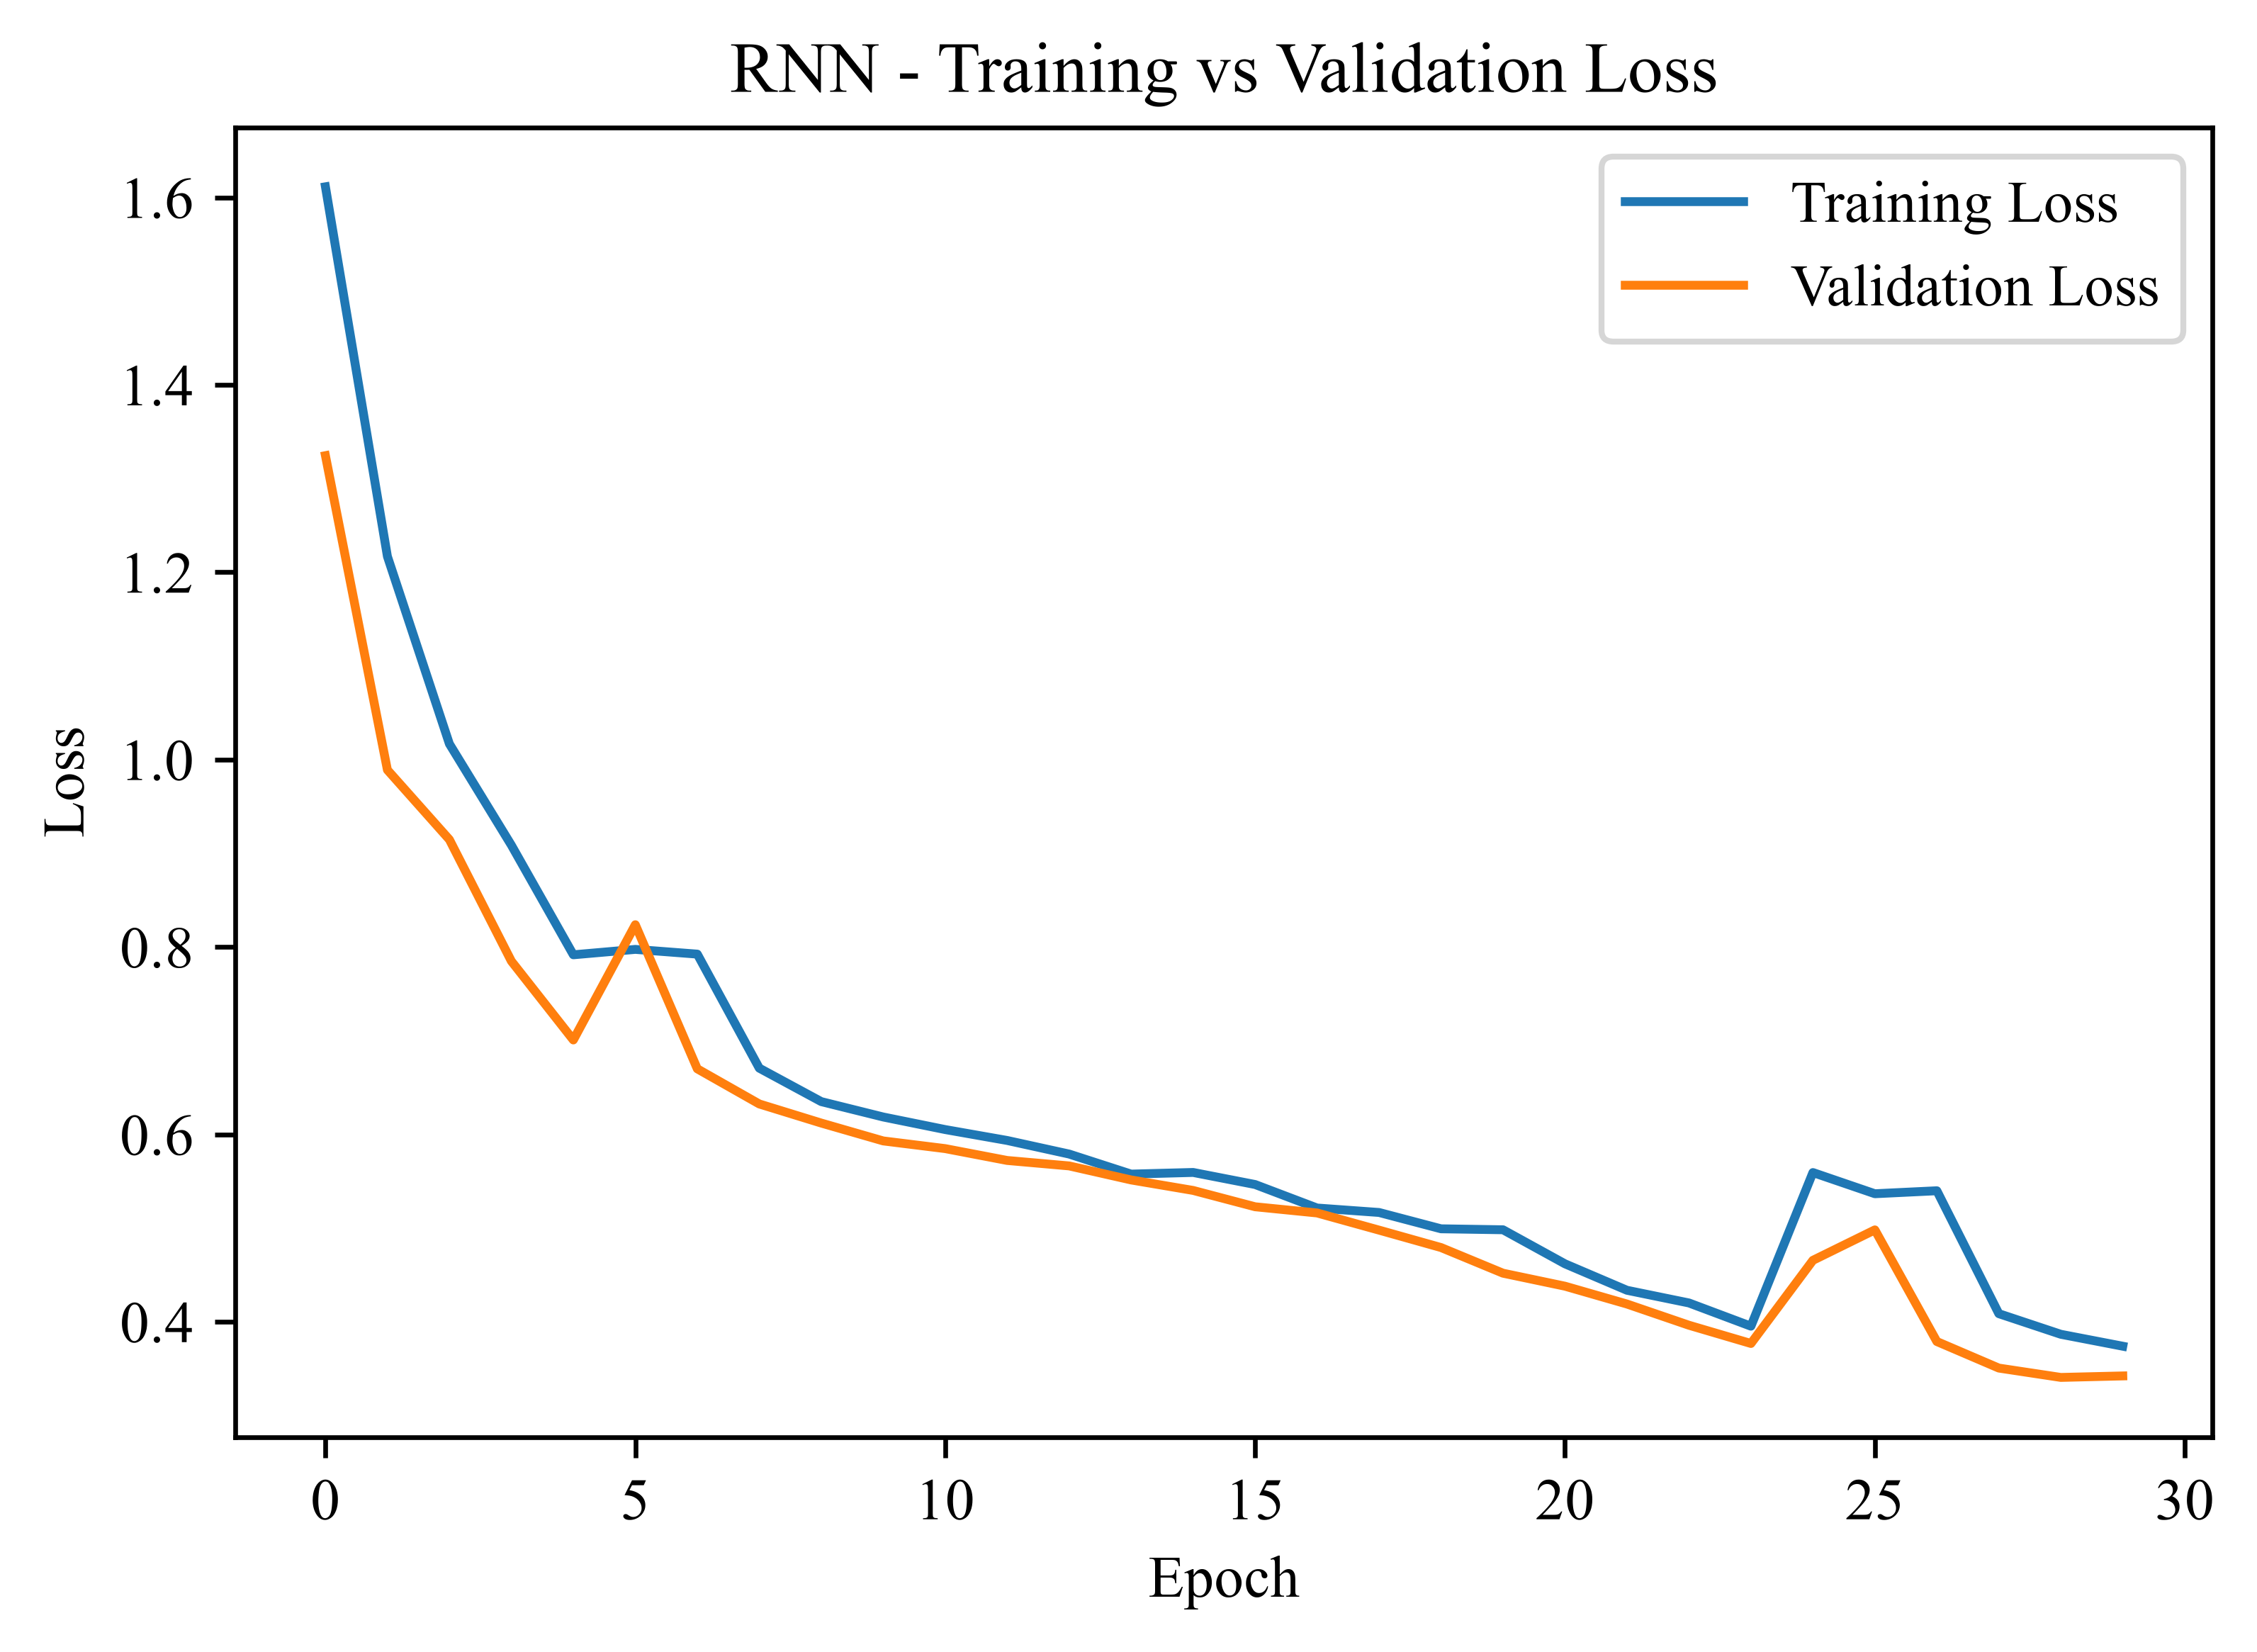

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved rnn_accuracy_curve.eps


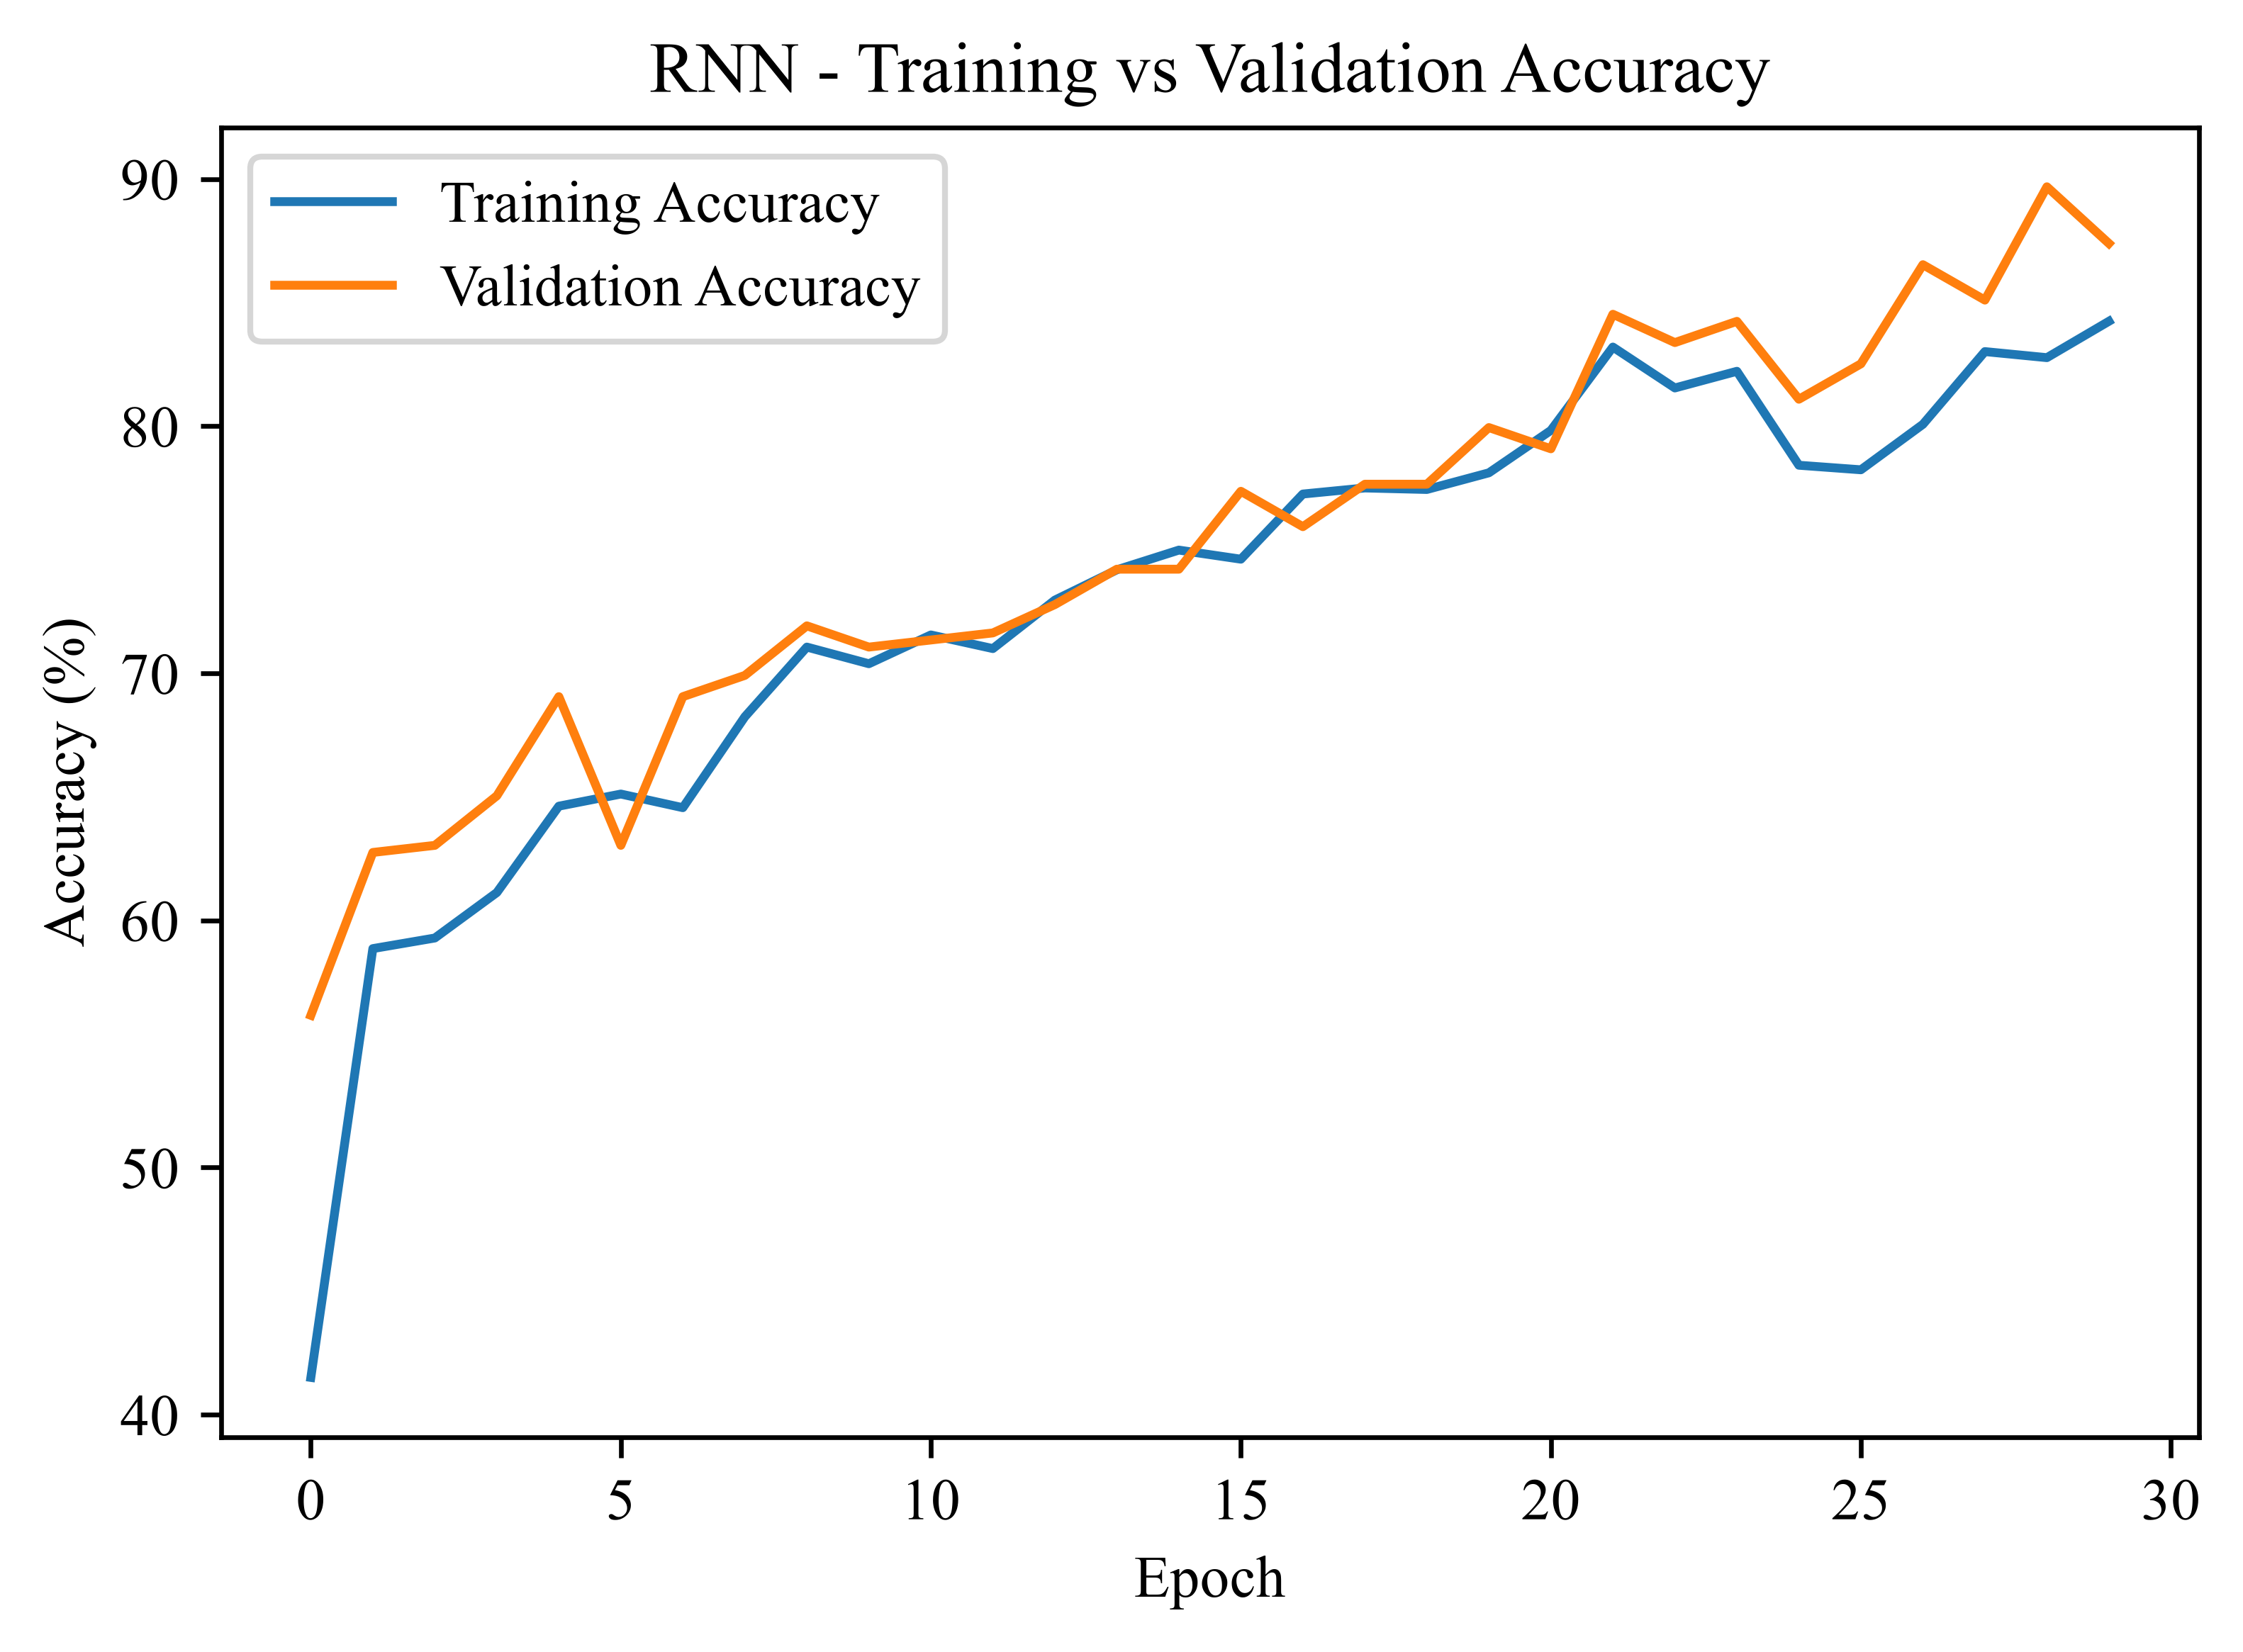

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved lstm_loss_curve.eps


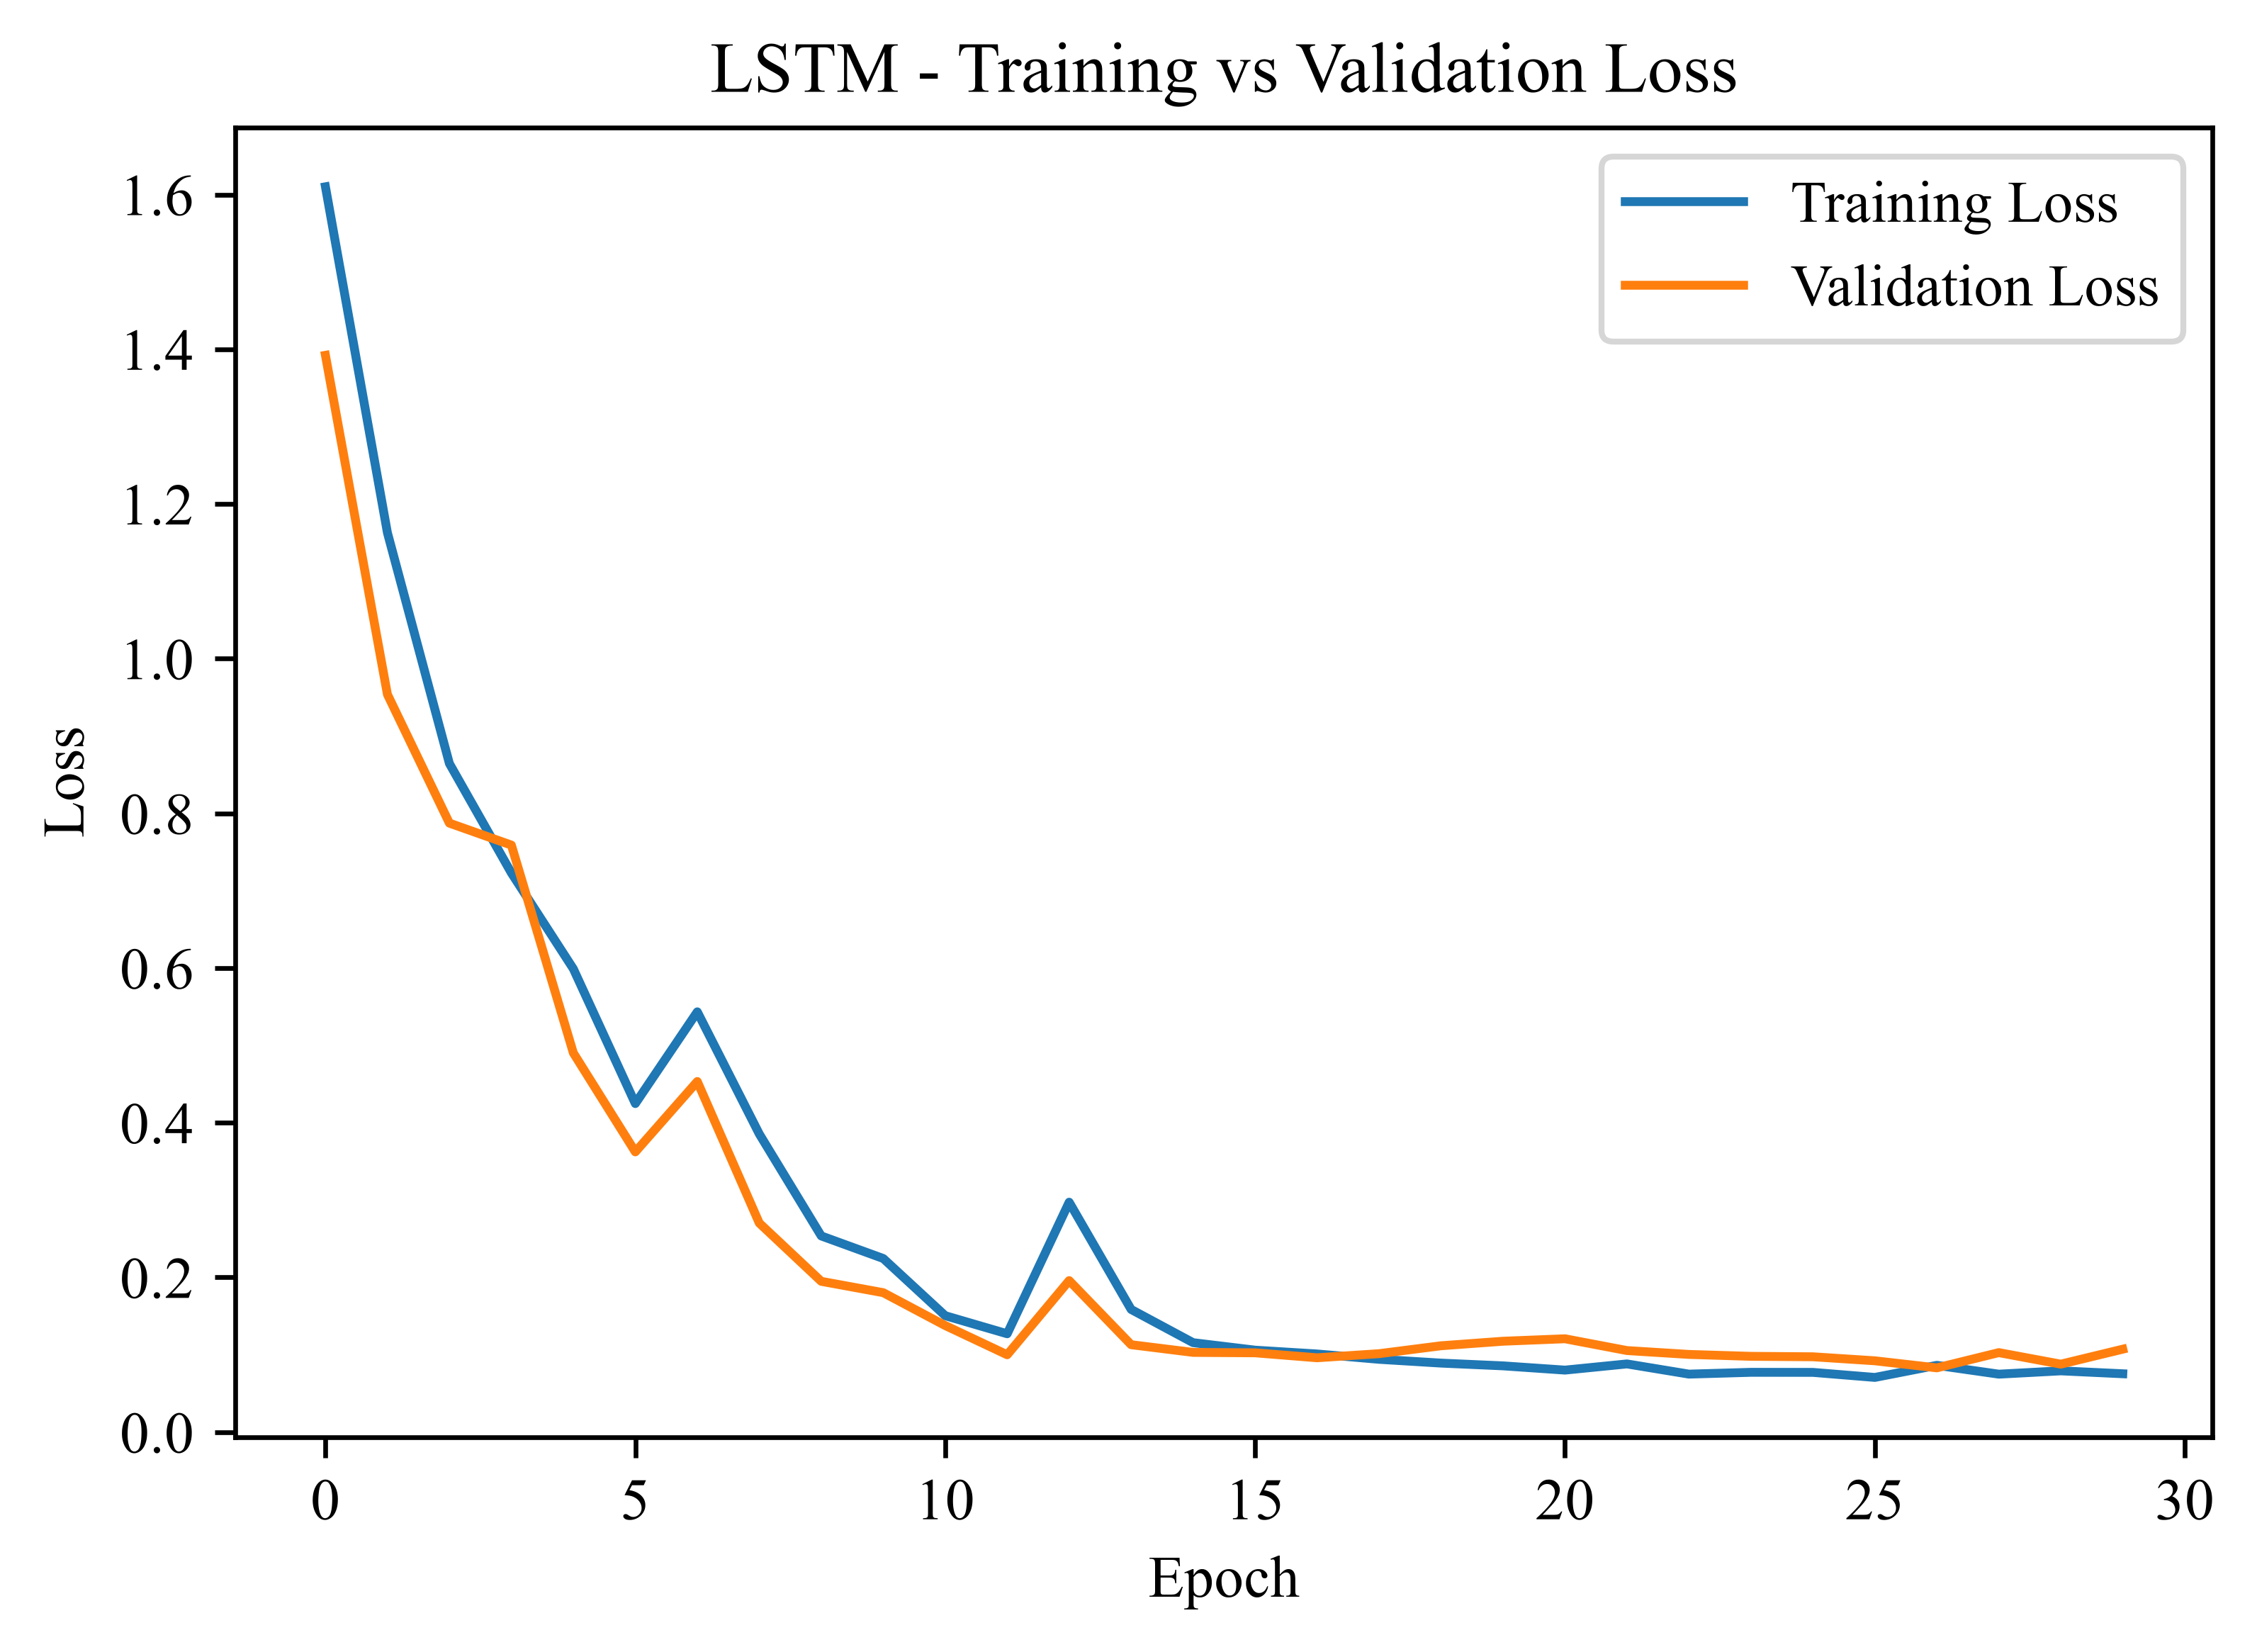

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved lstm_accuracy_curve.eps


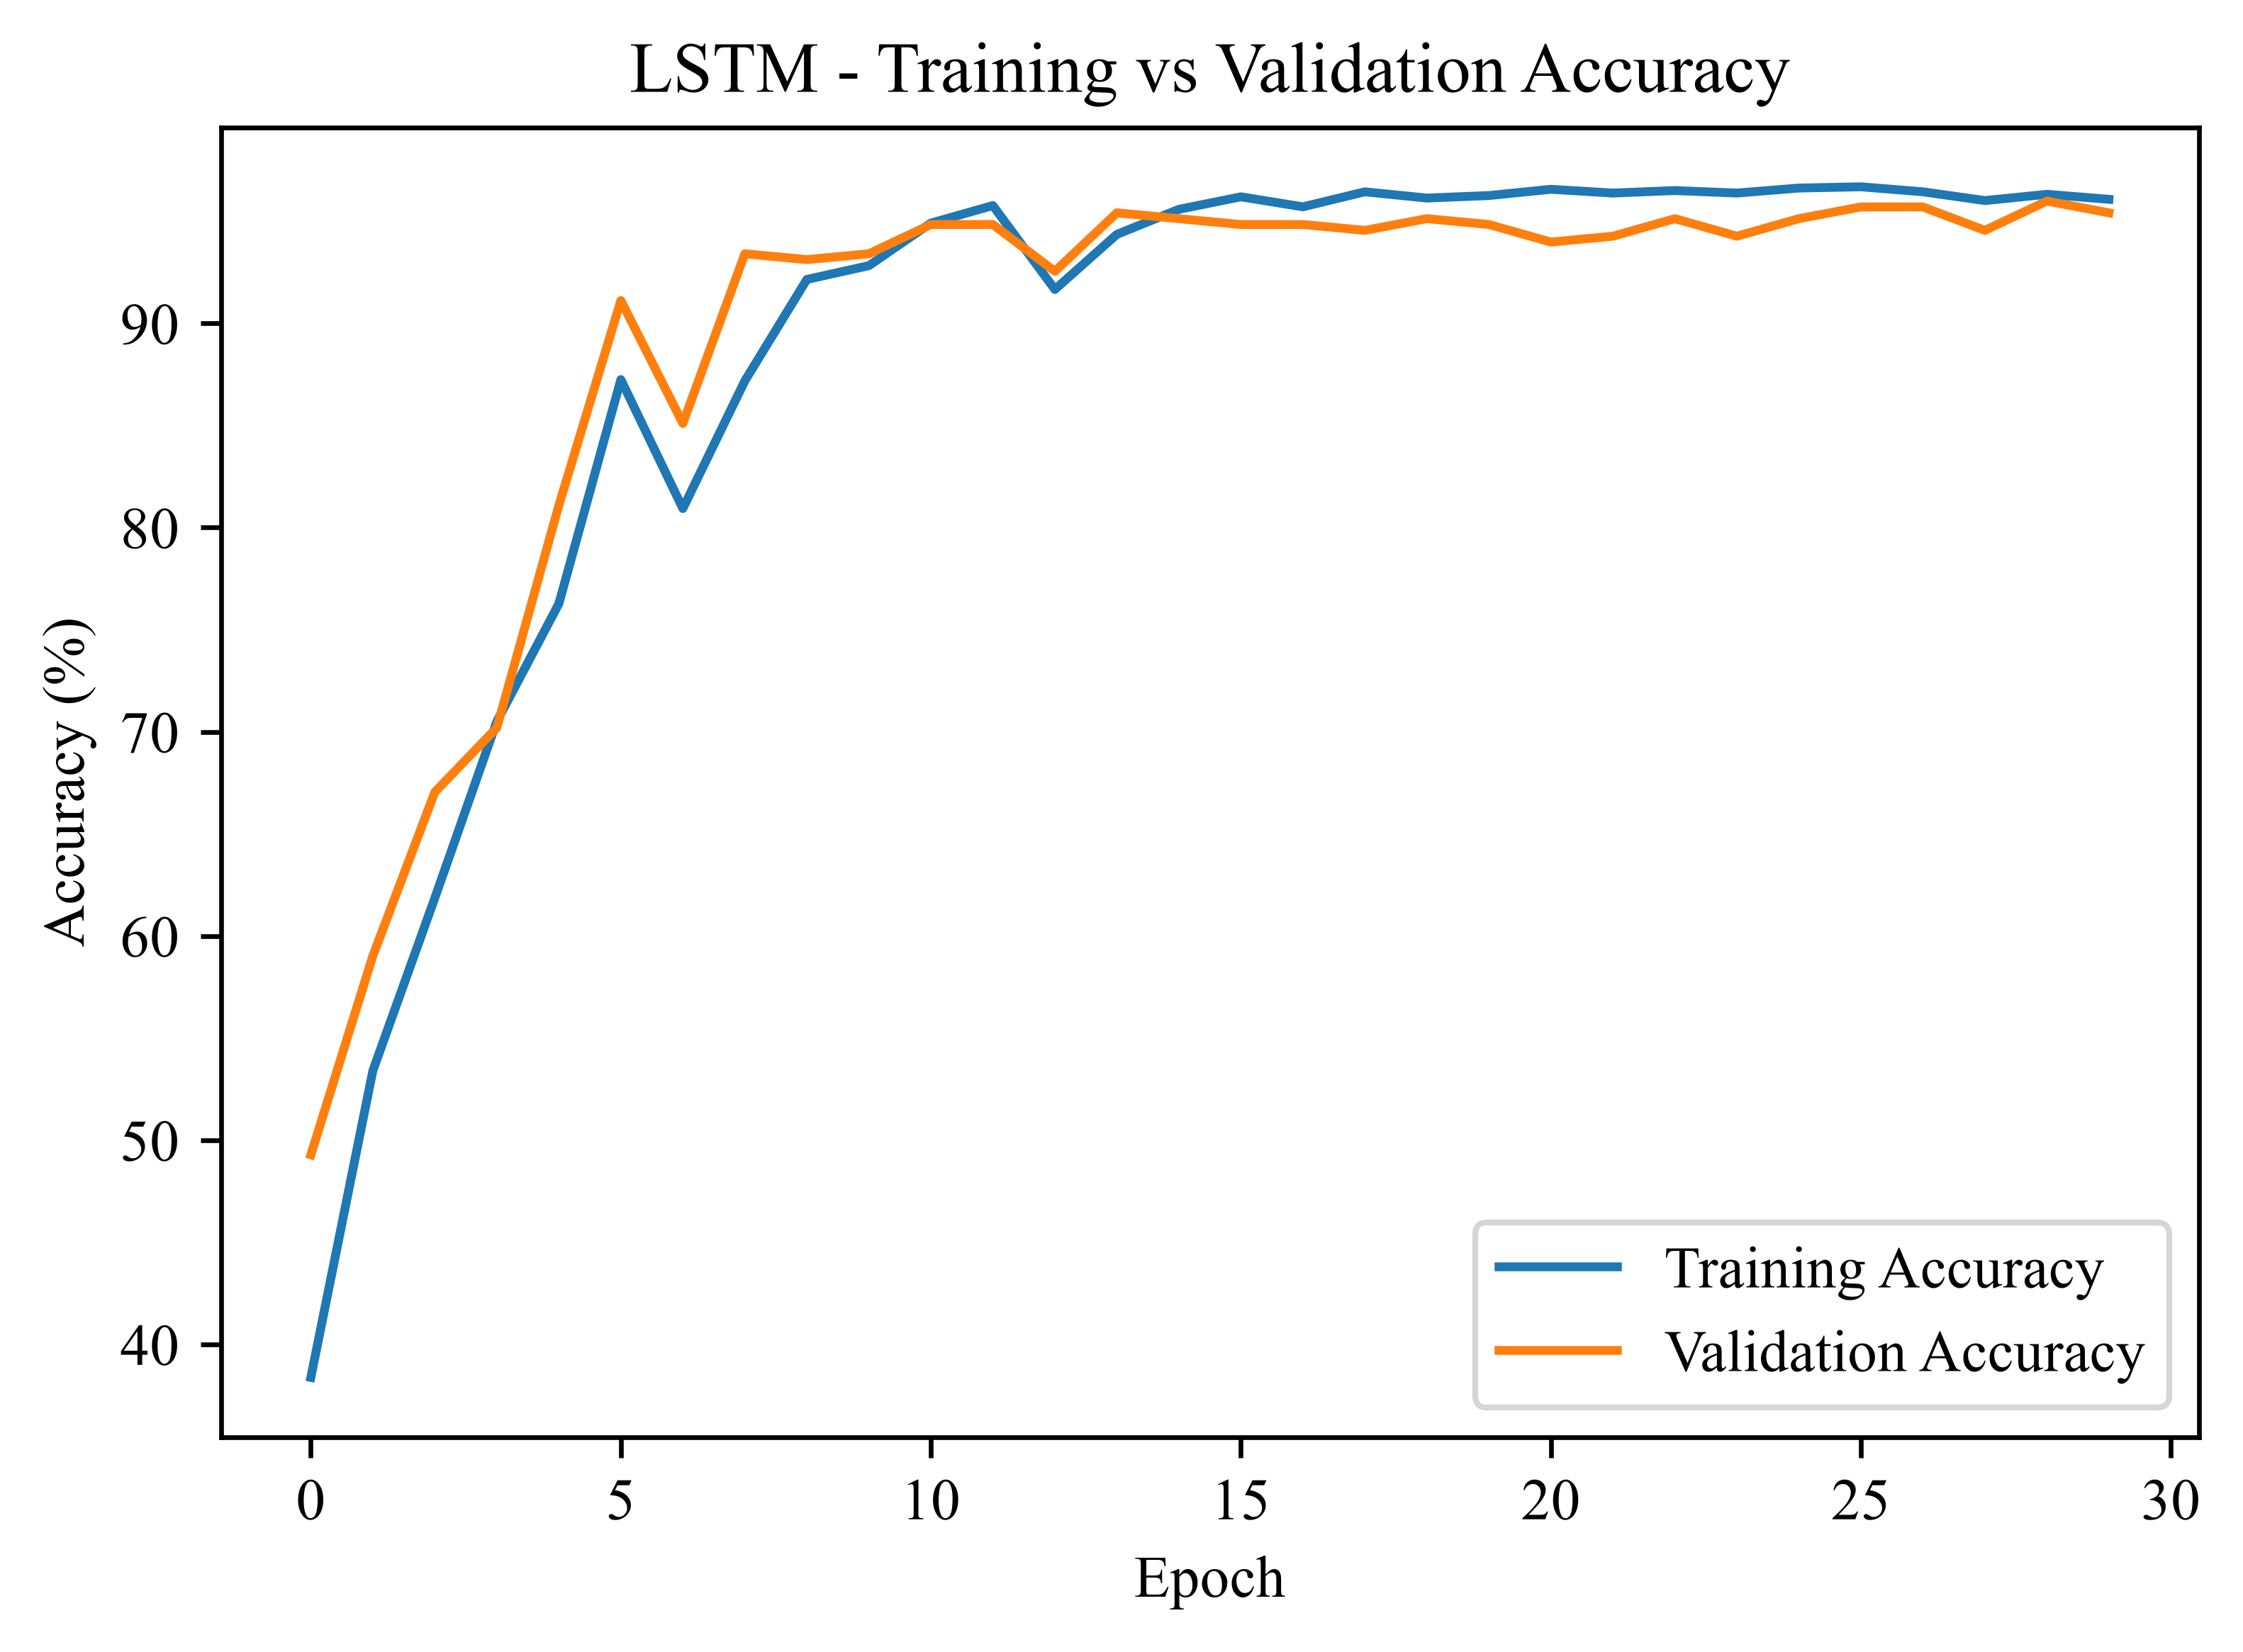

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved gru_loss_curve.eps


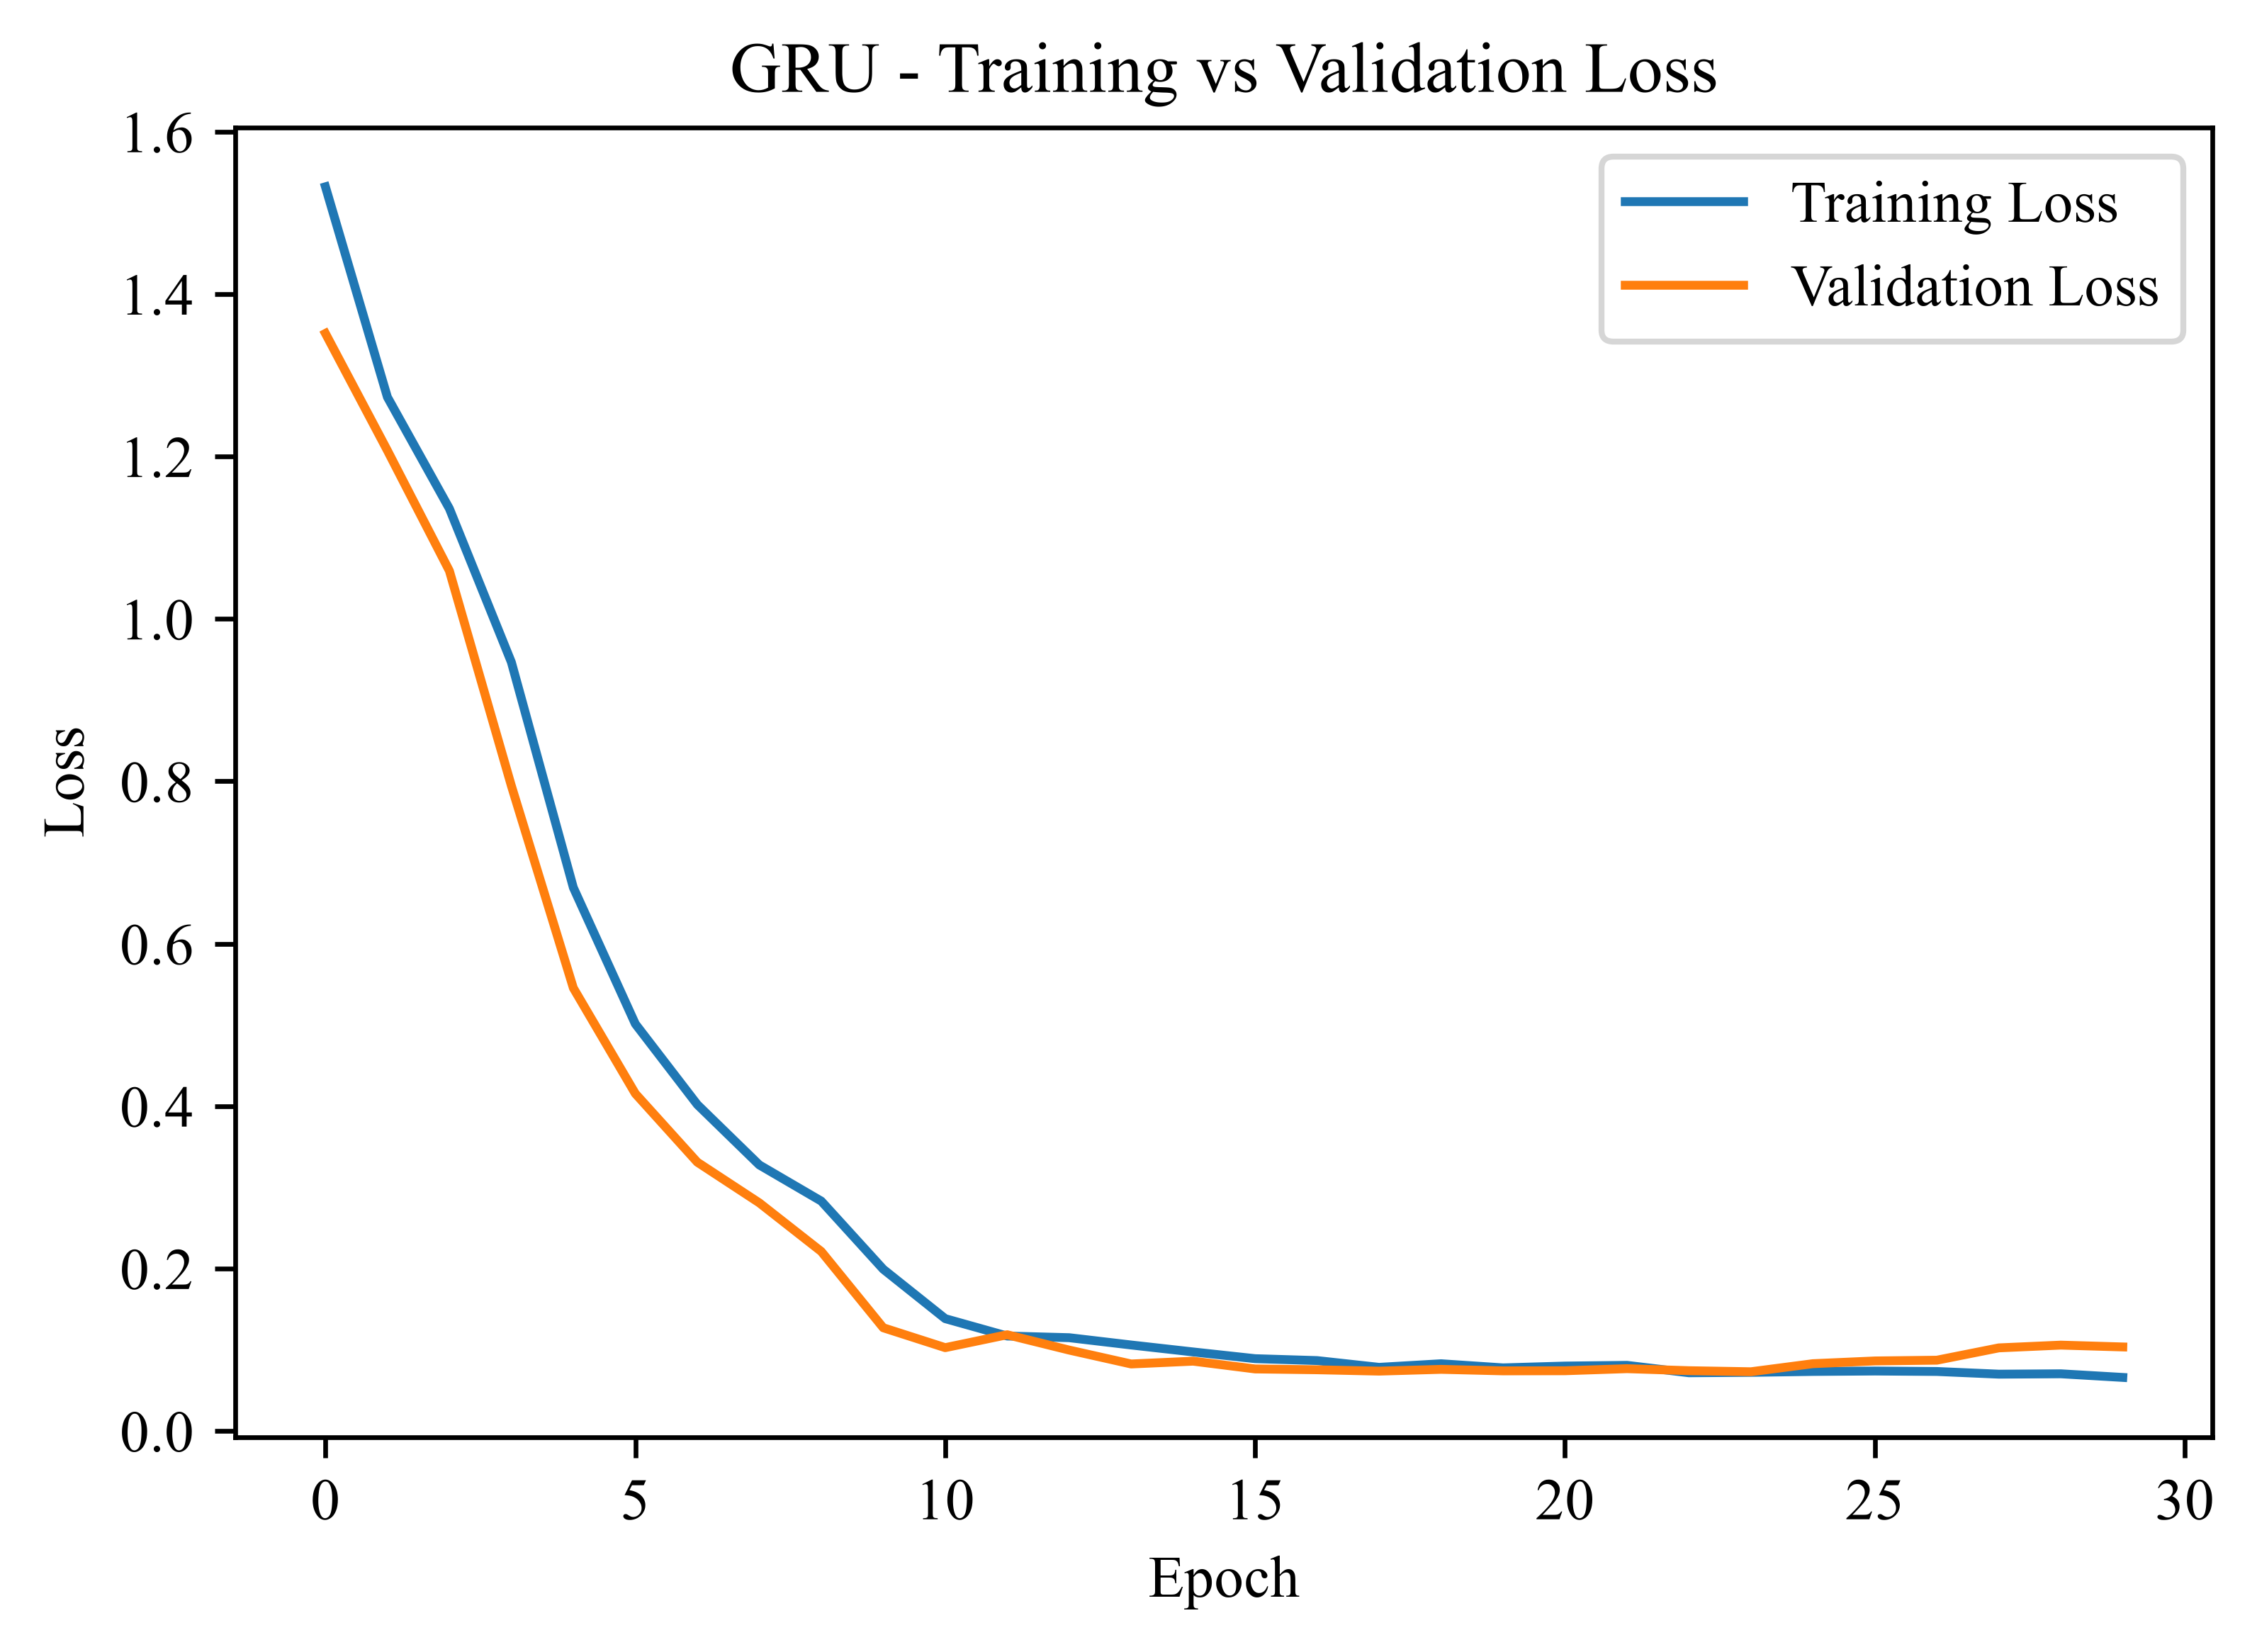

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved gru_accuracy_curve.eps


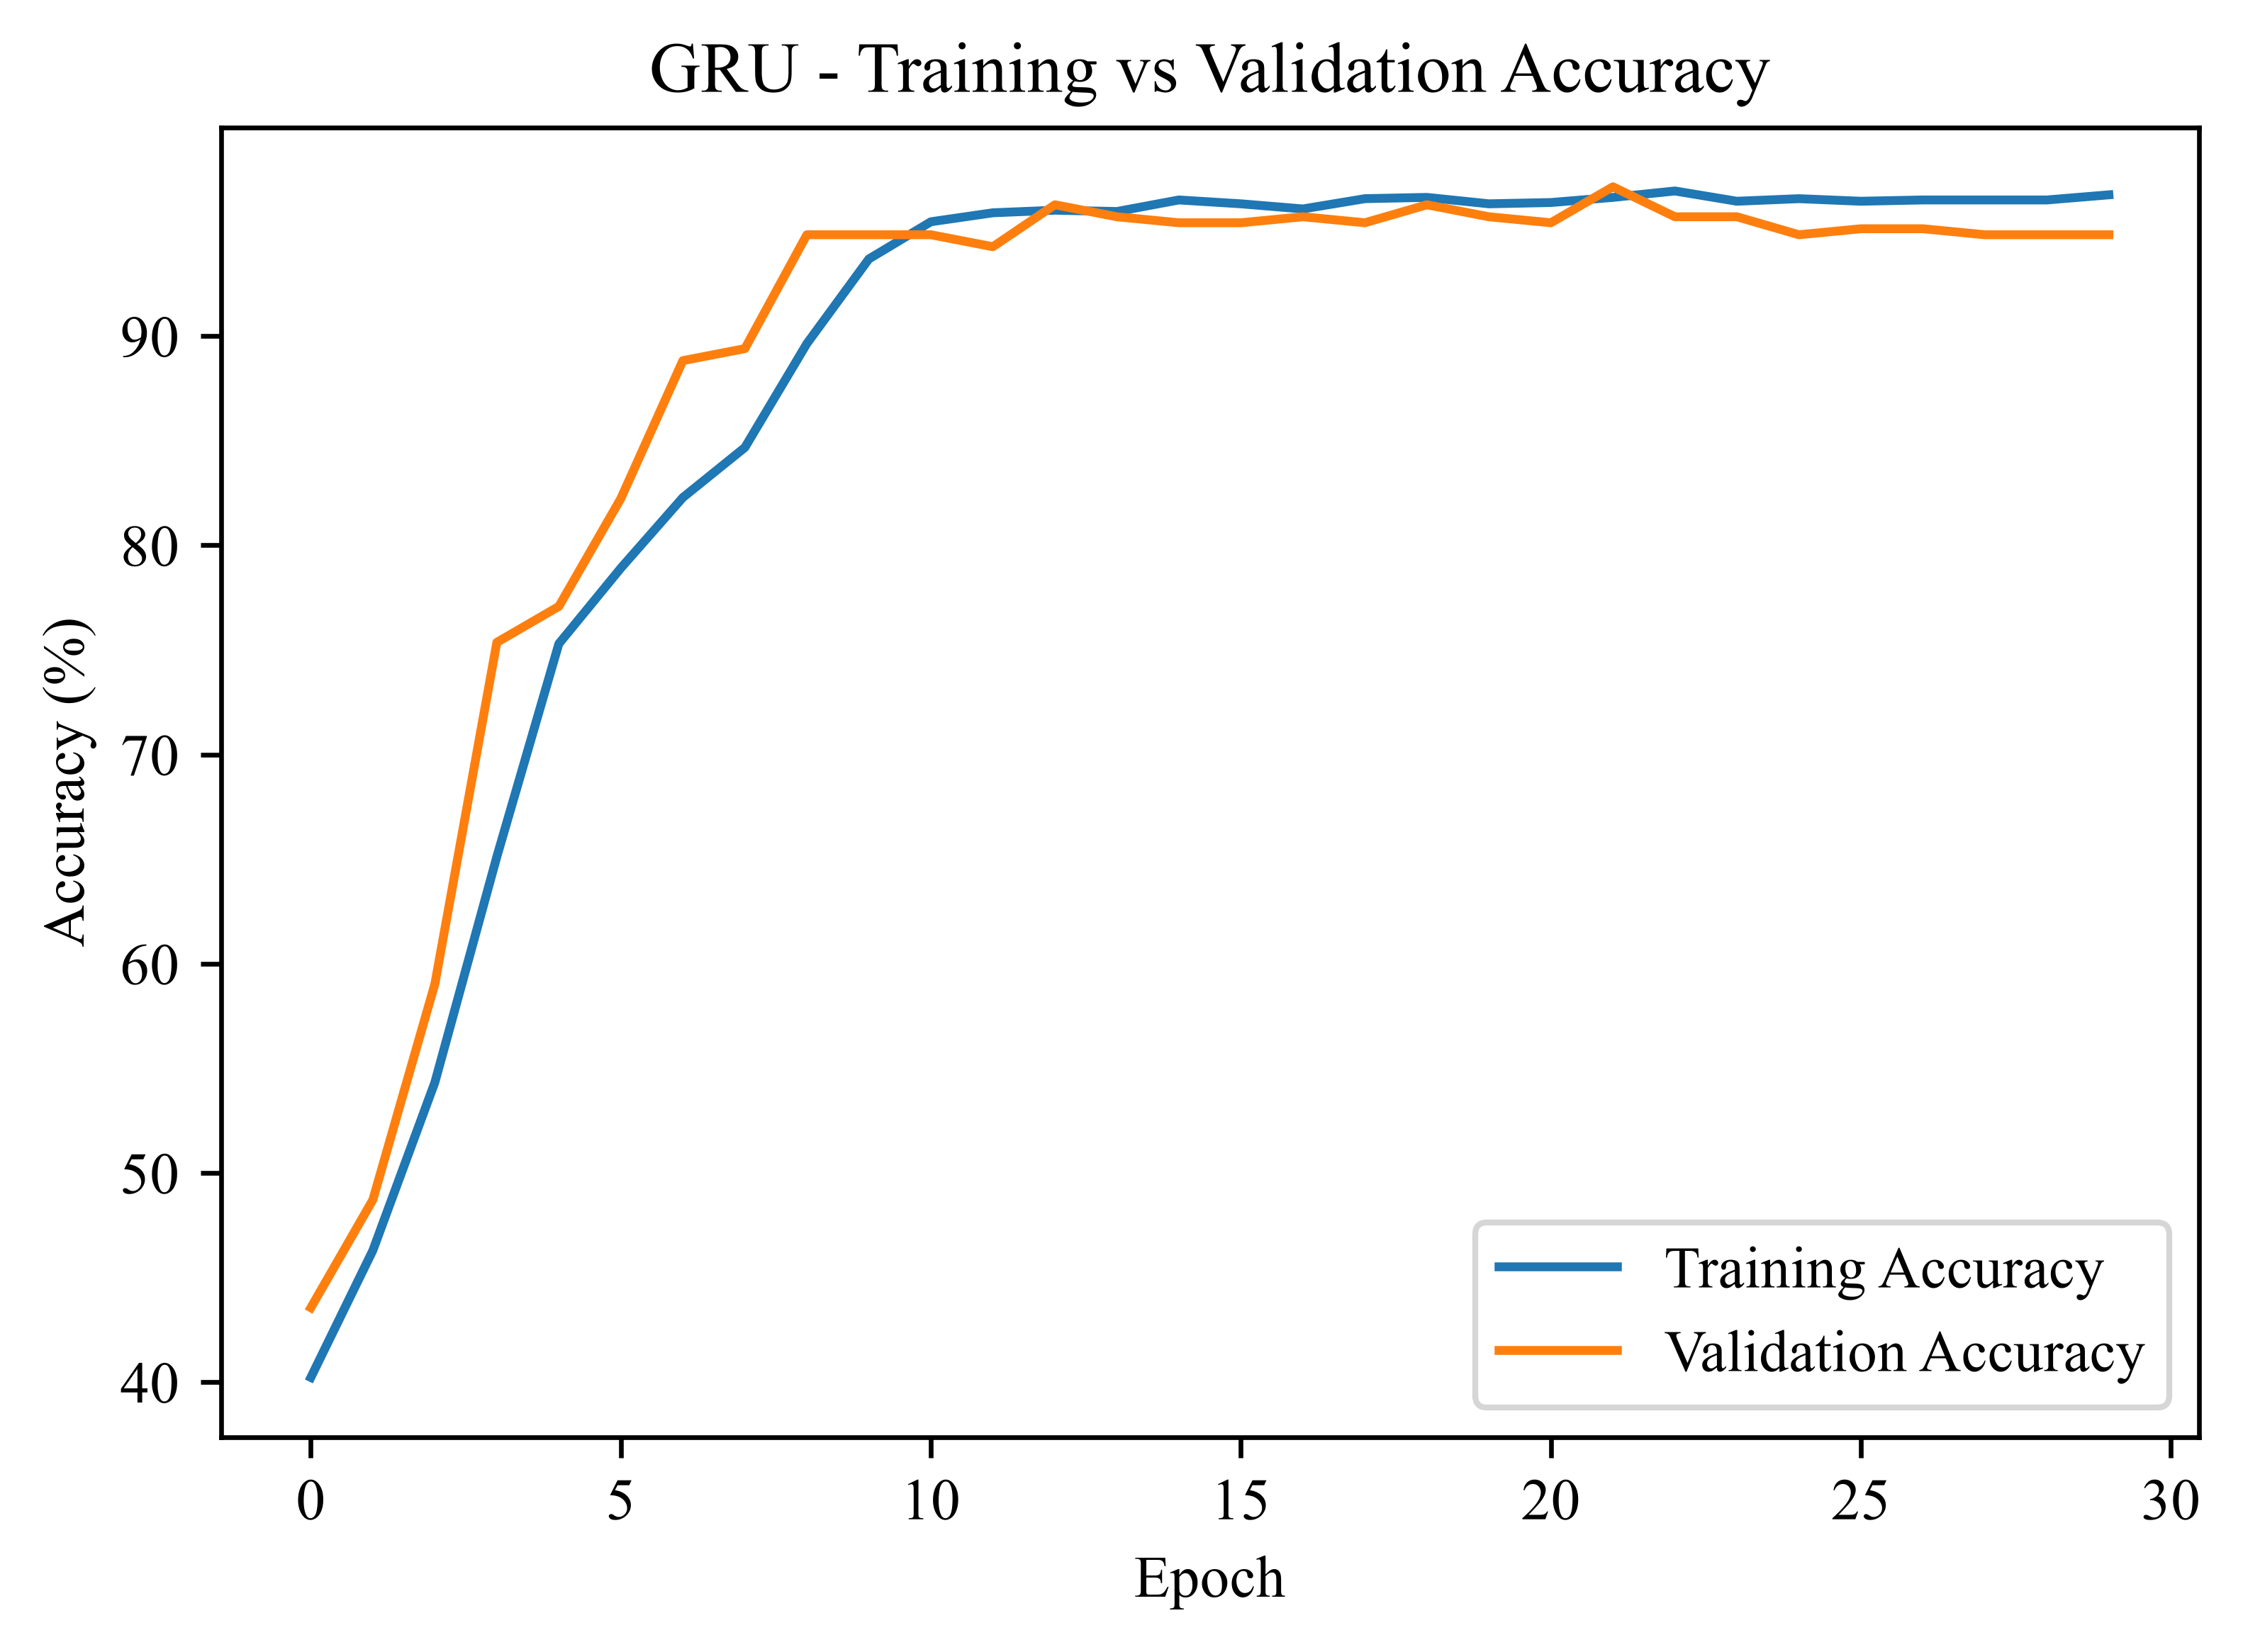

In [14]:
for rec_type in ["RNN", "LSTM", "GRU"]:
    hist = results[rec_type]["history"].history

    plt.figure(figsize=(6, 4))
    plt.plot(hist['loss'], label='Training Loss')
    plt.plot(hist['val_loss'], label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{rec_type} - Training vs Validation Loss")
    plt.legend()
    save_plot(f"{rec_type.lower()}_loss_curve")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(np.array(hist['accuracy']) * 100, label='Training Accuracy')
    plt.plot(np.array(hist['val_accuracy']) * 100, label='Validation Accuracy')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{rec_type} - Training vs Validation Accuracy")
    plt.legend()
    save_plot(f"{rec_type.lower()}_accuracy_curve")
    plt.show()

# Inference (convergence behaviour):
# - RNN: loss decreases but tends to plateau earlier and less smoothly than
#   LSTM/GRU, since plain RNNs struggle to carry information over 128 steps.
# - LSTM: converges more steadily thanks to the gated cell state, usually
#   reaching a lower validation loss than the vanilla RNN.
# - GRU: converges at a similar speed to LSTM, sometimes slightly faster per
#   epoch since it has fewer gates and therefore fewer computations.
# Overfitting/underfitting: if training accuracy keeps rising while
# validation accuracy flattens or drops, that gap indicates overfitting;
# if both curves stay low, that indicates underfitting.


In [15]:
comparison_table = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "Accuracy (%)": [results[m]["accuracy"] * 100 for m in ["RNN", "LSTM", "GRU"]],
    "Macro Precision (%)": [results[m]["precision"] * 100 for m in ["RNN", "LSTM", "GRU"]],
    "Macro Recall (%)": [results[m]["recall"] * 100 for m in ["RNN", "LSTM", "GRU"]],
    "Macro F1 (%)": [results[m]["f1"] * 100 for m in ["RNN", "LSTM", "GRU"]],
    "Parameters": [results[m]["params"] for m in ["RNN", "LSTM", "GRU"]],
    "Training Time (s)": [results[m]["train_time"] for m in ["RNN", "LSTM", "GRU"]],
})
print(comparison_table.to_string(index=False))


Model  Accuracy (%)  Macro Precision (%)  Macro Recall (%)  Macro F1 (%)  Parameters  Training Time (s)
  RNN     73.532406            73.759939         73.188150     73.125112        1974          13.497173
 LSTM     88.462844            88.895746         88.550314     88.434090        6006          26.849205
  GRU     84.356973            84.583162         84.367539     84.134436        4758          41.218379


saved rnn_confusion_matrix.eps


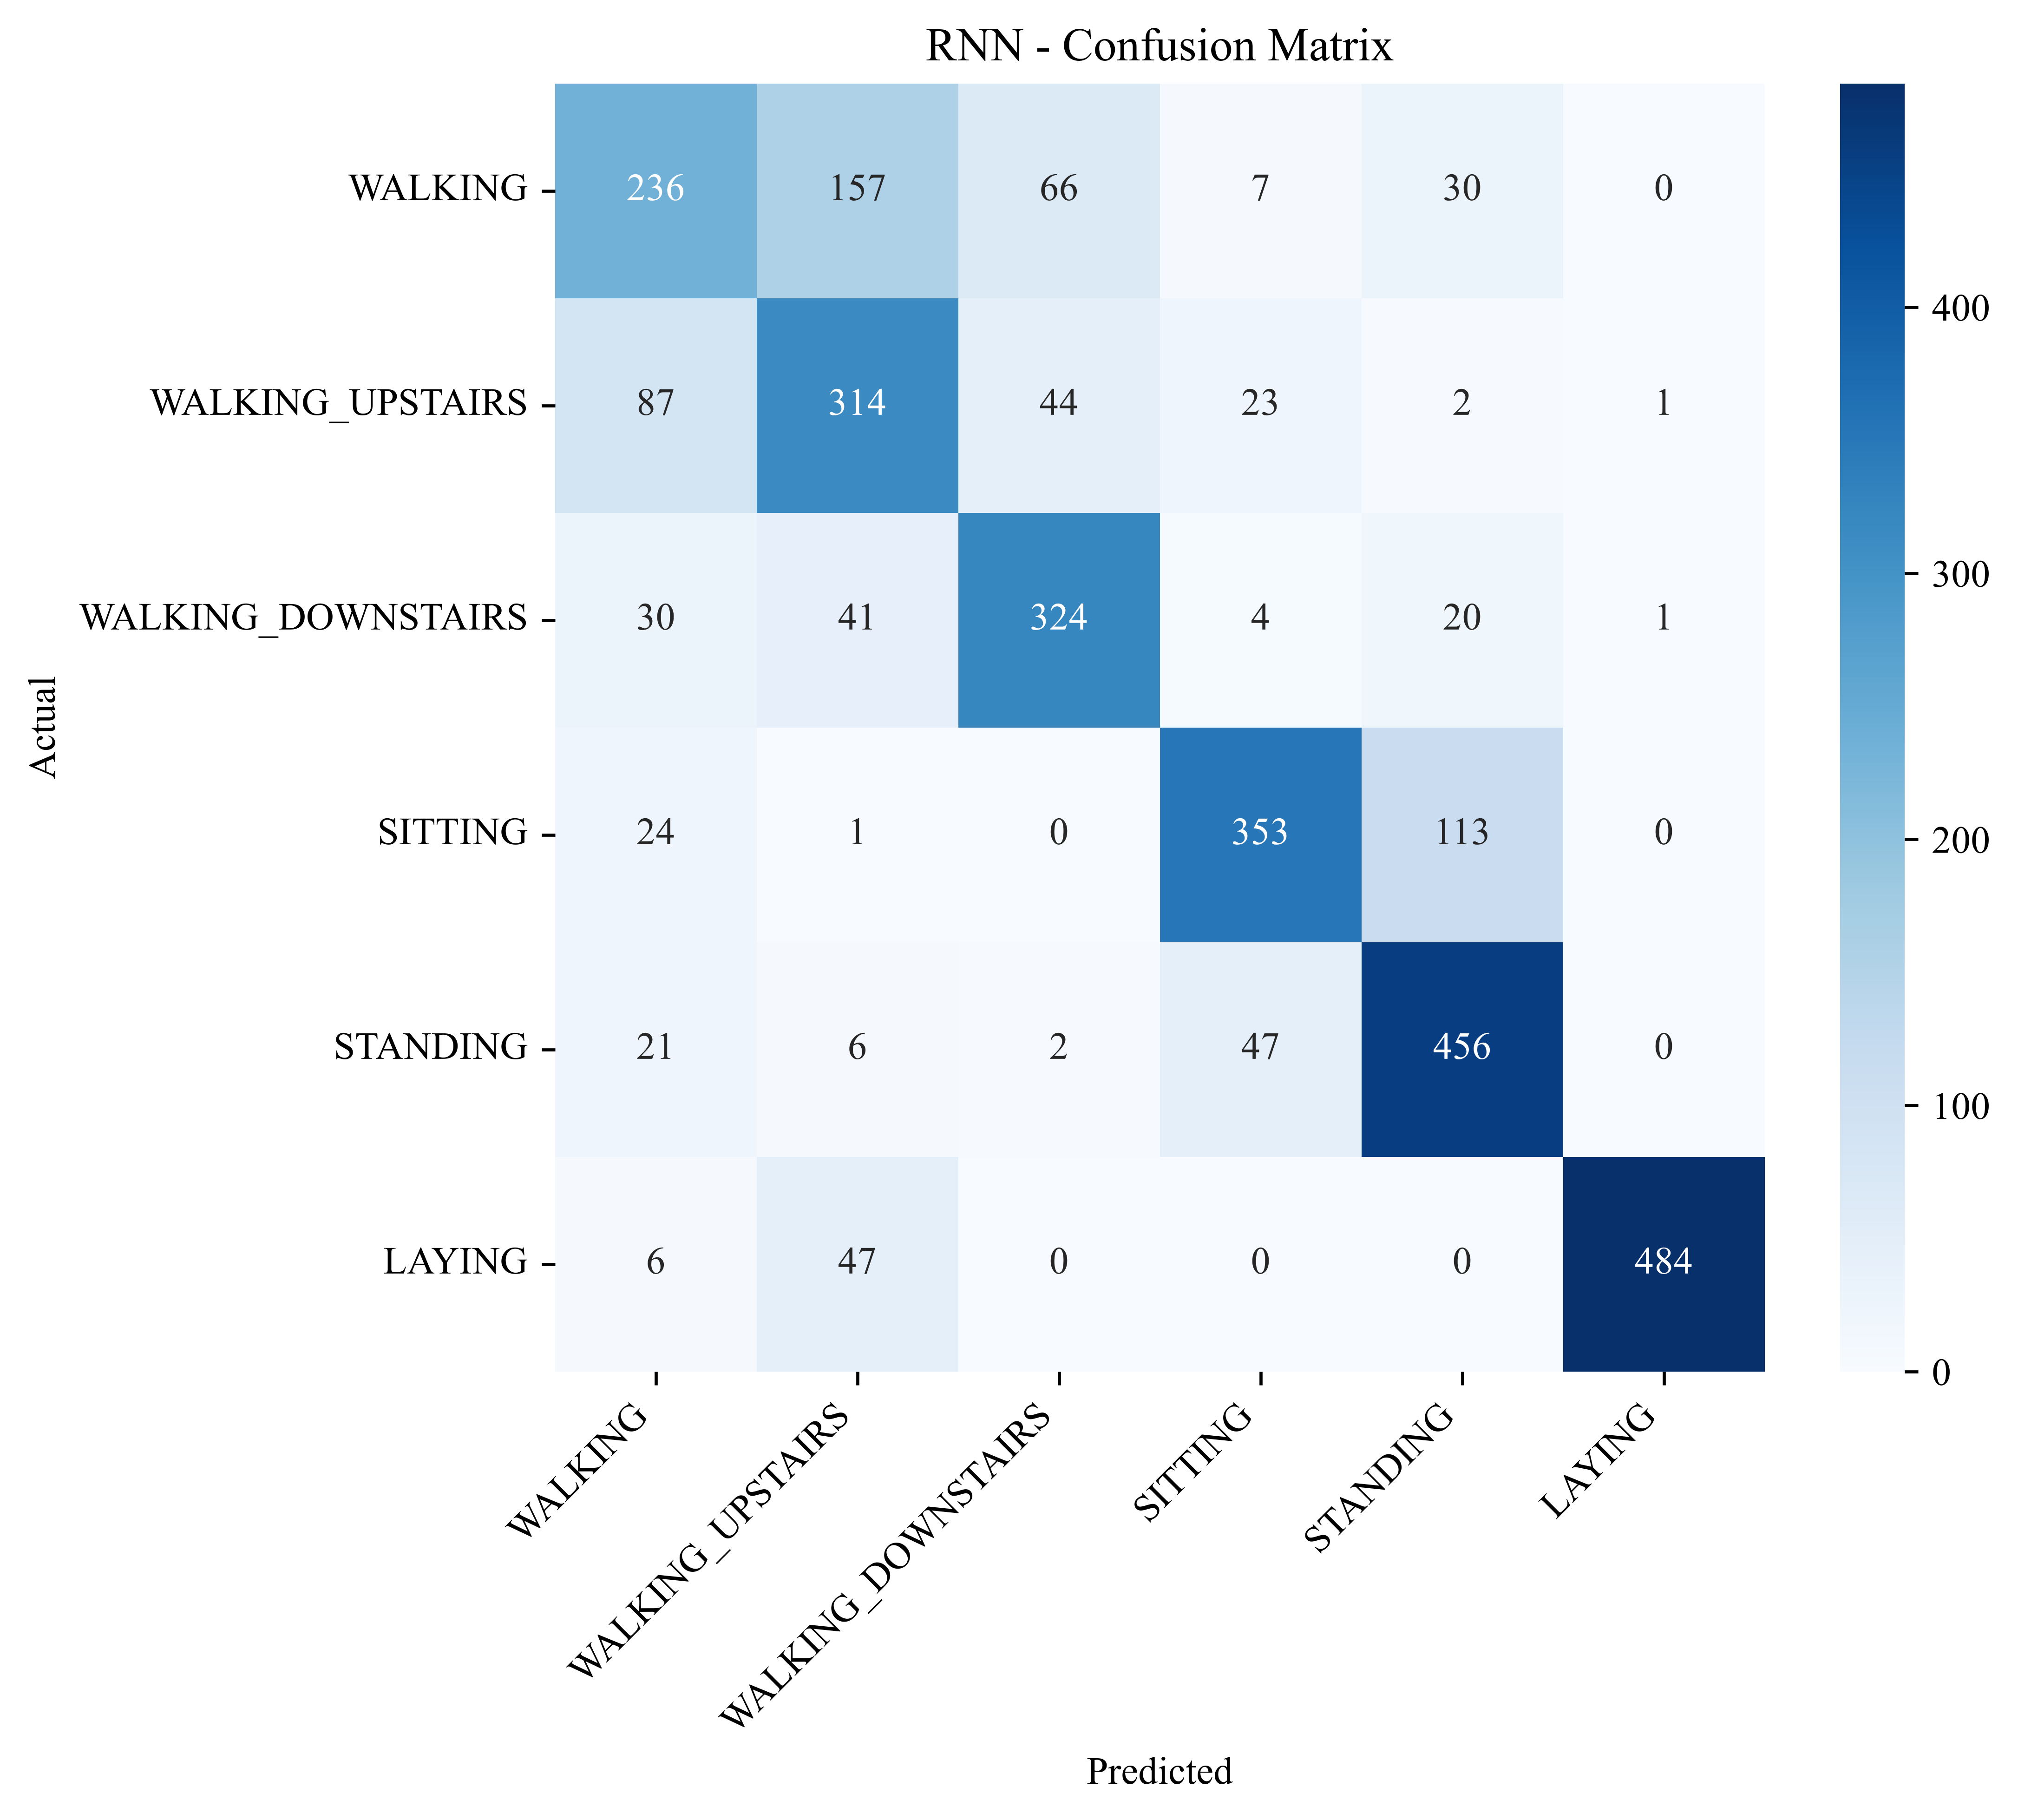

saved lstm_confusion_matrix.eps


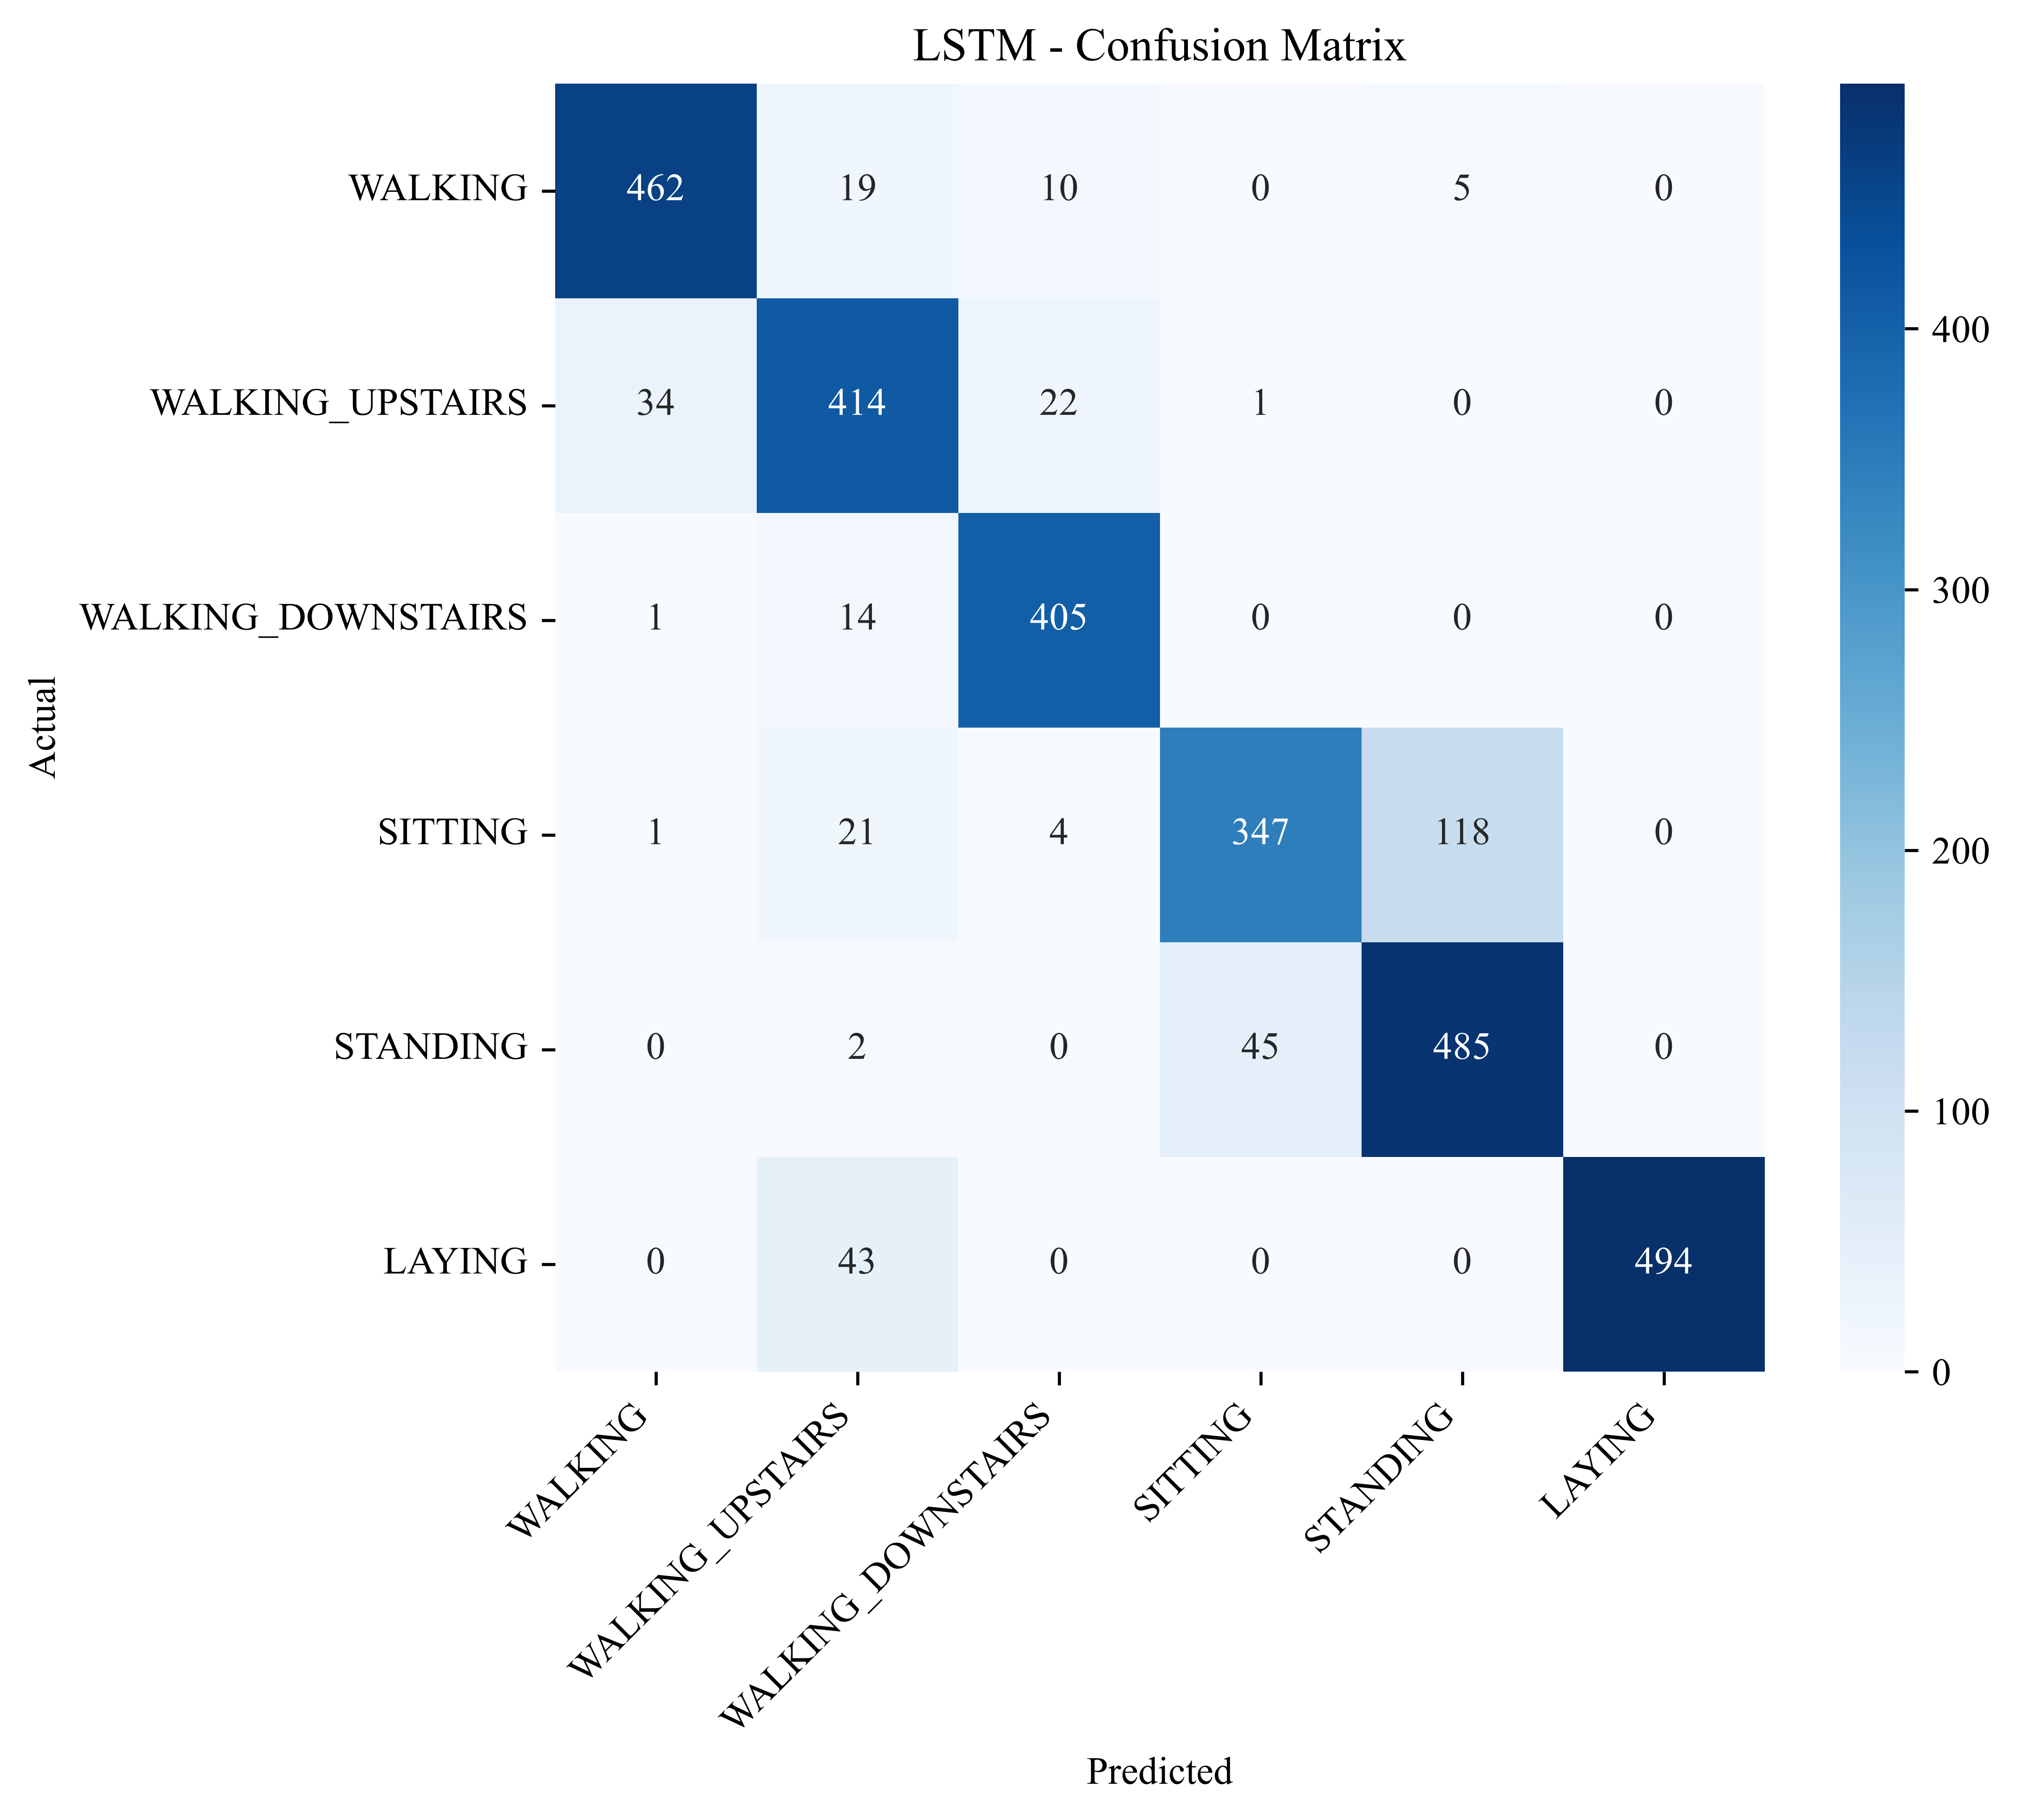

saved gru_confusion_matrix.eps


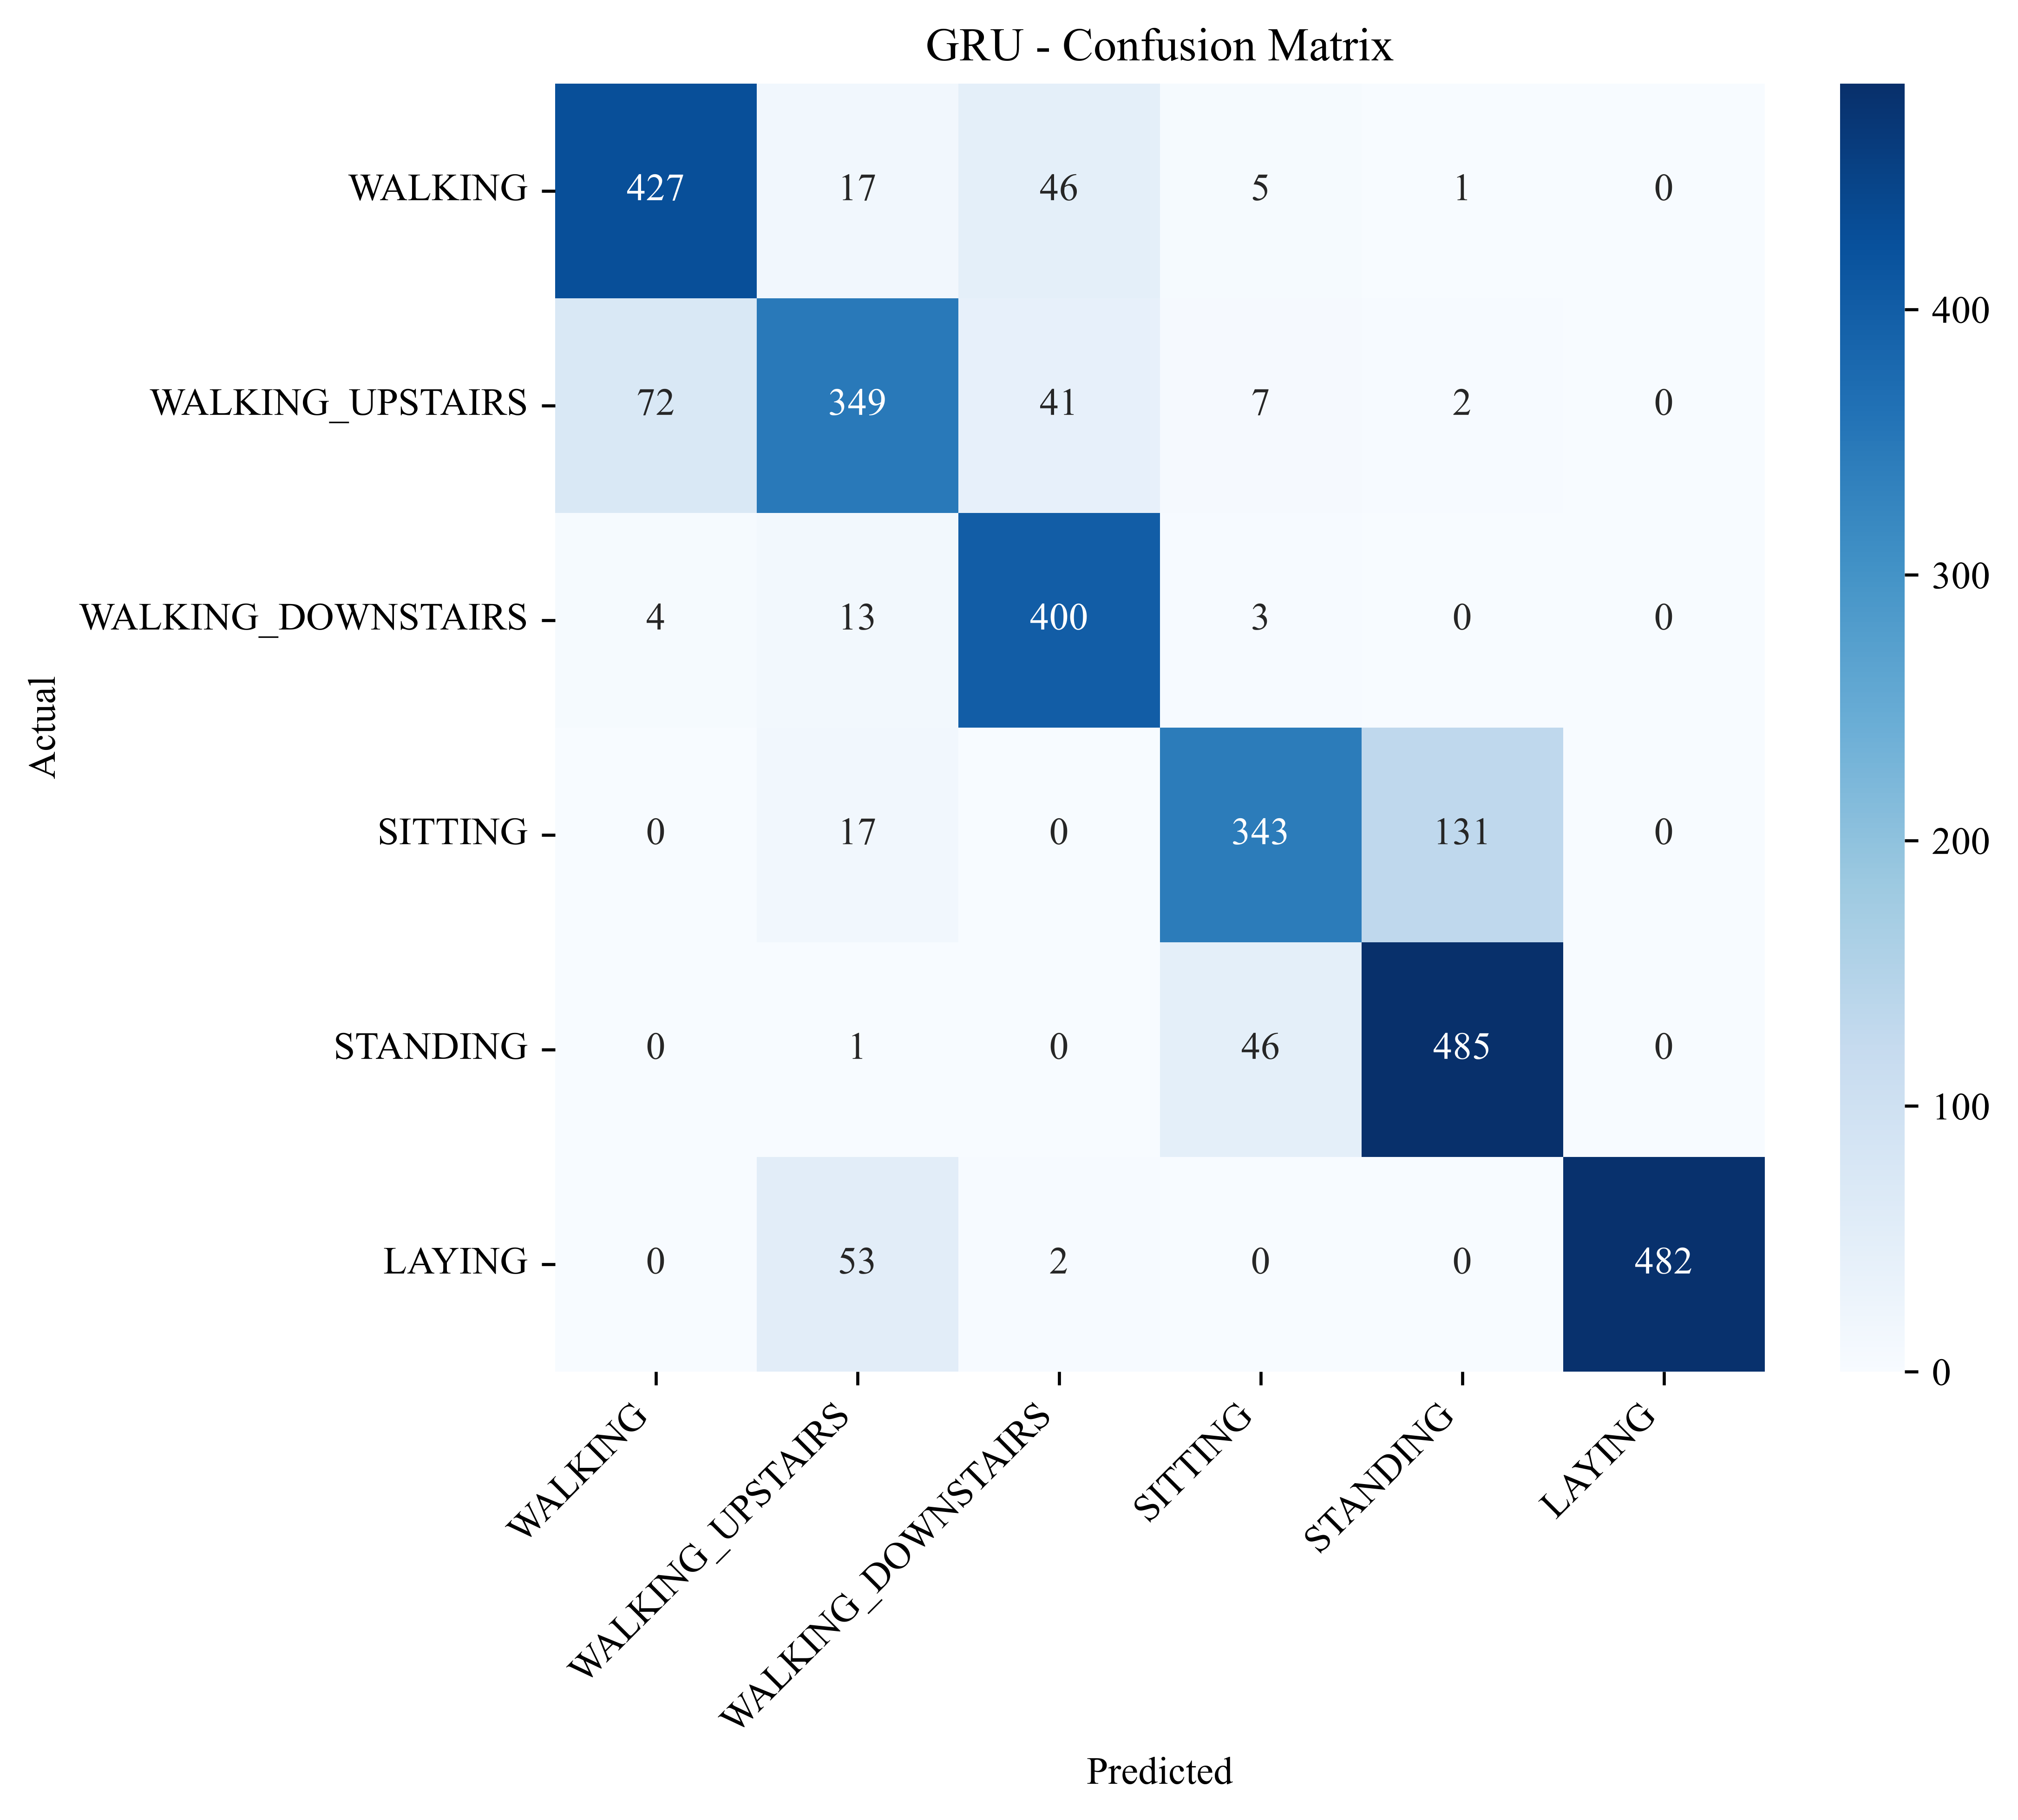

In [16]:
for rec_type in ["RNN", "LSTM", "GRU"]:
    cm = results[rec_type]["confusion_matrix"]
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=ACTIVITY_NAMES, yticklabels=ACTIVITY_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{rec_type} - Confusion Matrix")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    save_plot(f"{rec_type.lower()}_confusion_matrix")
    plt.show()

# Inference (to be finalised against the student's own numbers): LAYING is
# usually the activity with the highest recognition rate since its signal is
# almost static and very distinct. SITTING and STANDING are commonly confused
# with each other because both are low-motion postures with similar sensor
# signatures. WALKING_UPSTAIRS and WALKING_DOWNSTAIRS can also get confused
# since both share the repetitive stepping pattern of WALKING. Whether these
# confusions are consistent across RNN, LSTM and GRU should be checked
# against each model's own confusion matrix above.

In [17]:
gate_comparison = pd.DataFrame({
    "Property": ["Hidden state", "Cell state", "Forget gate", "Input gate",
                 "Output gate", "Update gate", "Reset gate",
                 "Parameters", "Training time (s)", "Test F1-score (%)"],
    "RNN": ["Yes", "No", "No", "No", "No", "No", "No",
            results["RNN"]["params"], f"{results['RNN']['train_time']:.1f}",
            f"{results['RNN']['f1'] * 100:.2f}"],
    "LSTM": ["Yes", "Yes", "Yes", "Yes", "Yes", "No", "No",
             results["LSTM"]["params"], f"{results['LSTM']['train_time']:.1f}",
             f"{results['LSTM']['f1'] * 100:.2f}"],
    "GRU": ["Yes", "No", "No", "No", "No", "Yes", "Yes",
            results["GRU"]["params"], f"{results['GRU']['train_time']:.1f}",
            f"{results['GRU']['f1'] * 100:.2f}"],
})
print(gate_comparison.to_string(index=False))

         Property   RNN  LSTM   GRU
     Hidden state   Yes   Yes   Yes
       Cell state    No   Yes    No
      Forget gate    No   Yes    No
       Input gate    No   Yes    No
      Output gate    No   Yes    No
      Update gate    No    No   Yes
       Reset gate    No    No   Yes
       Parameters  1974  6006  4758
Training time (s)  13.5  26.8  41.2
Test F1-score (%) 73.13 88.43 84.13


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved model_comparison_bar.eps


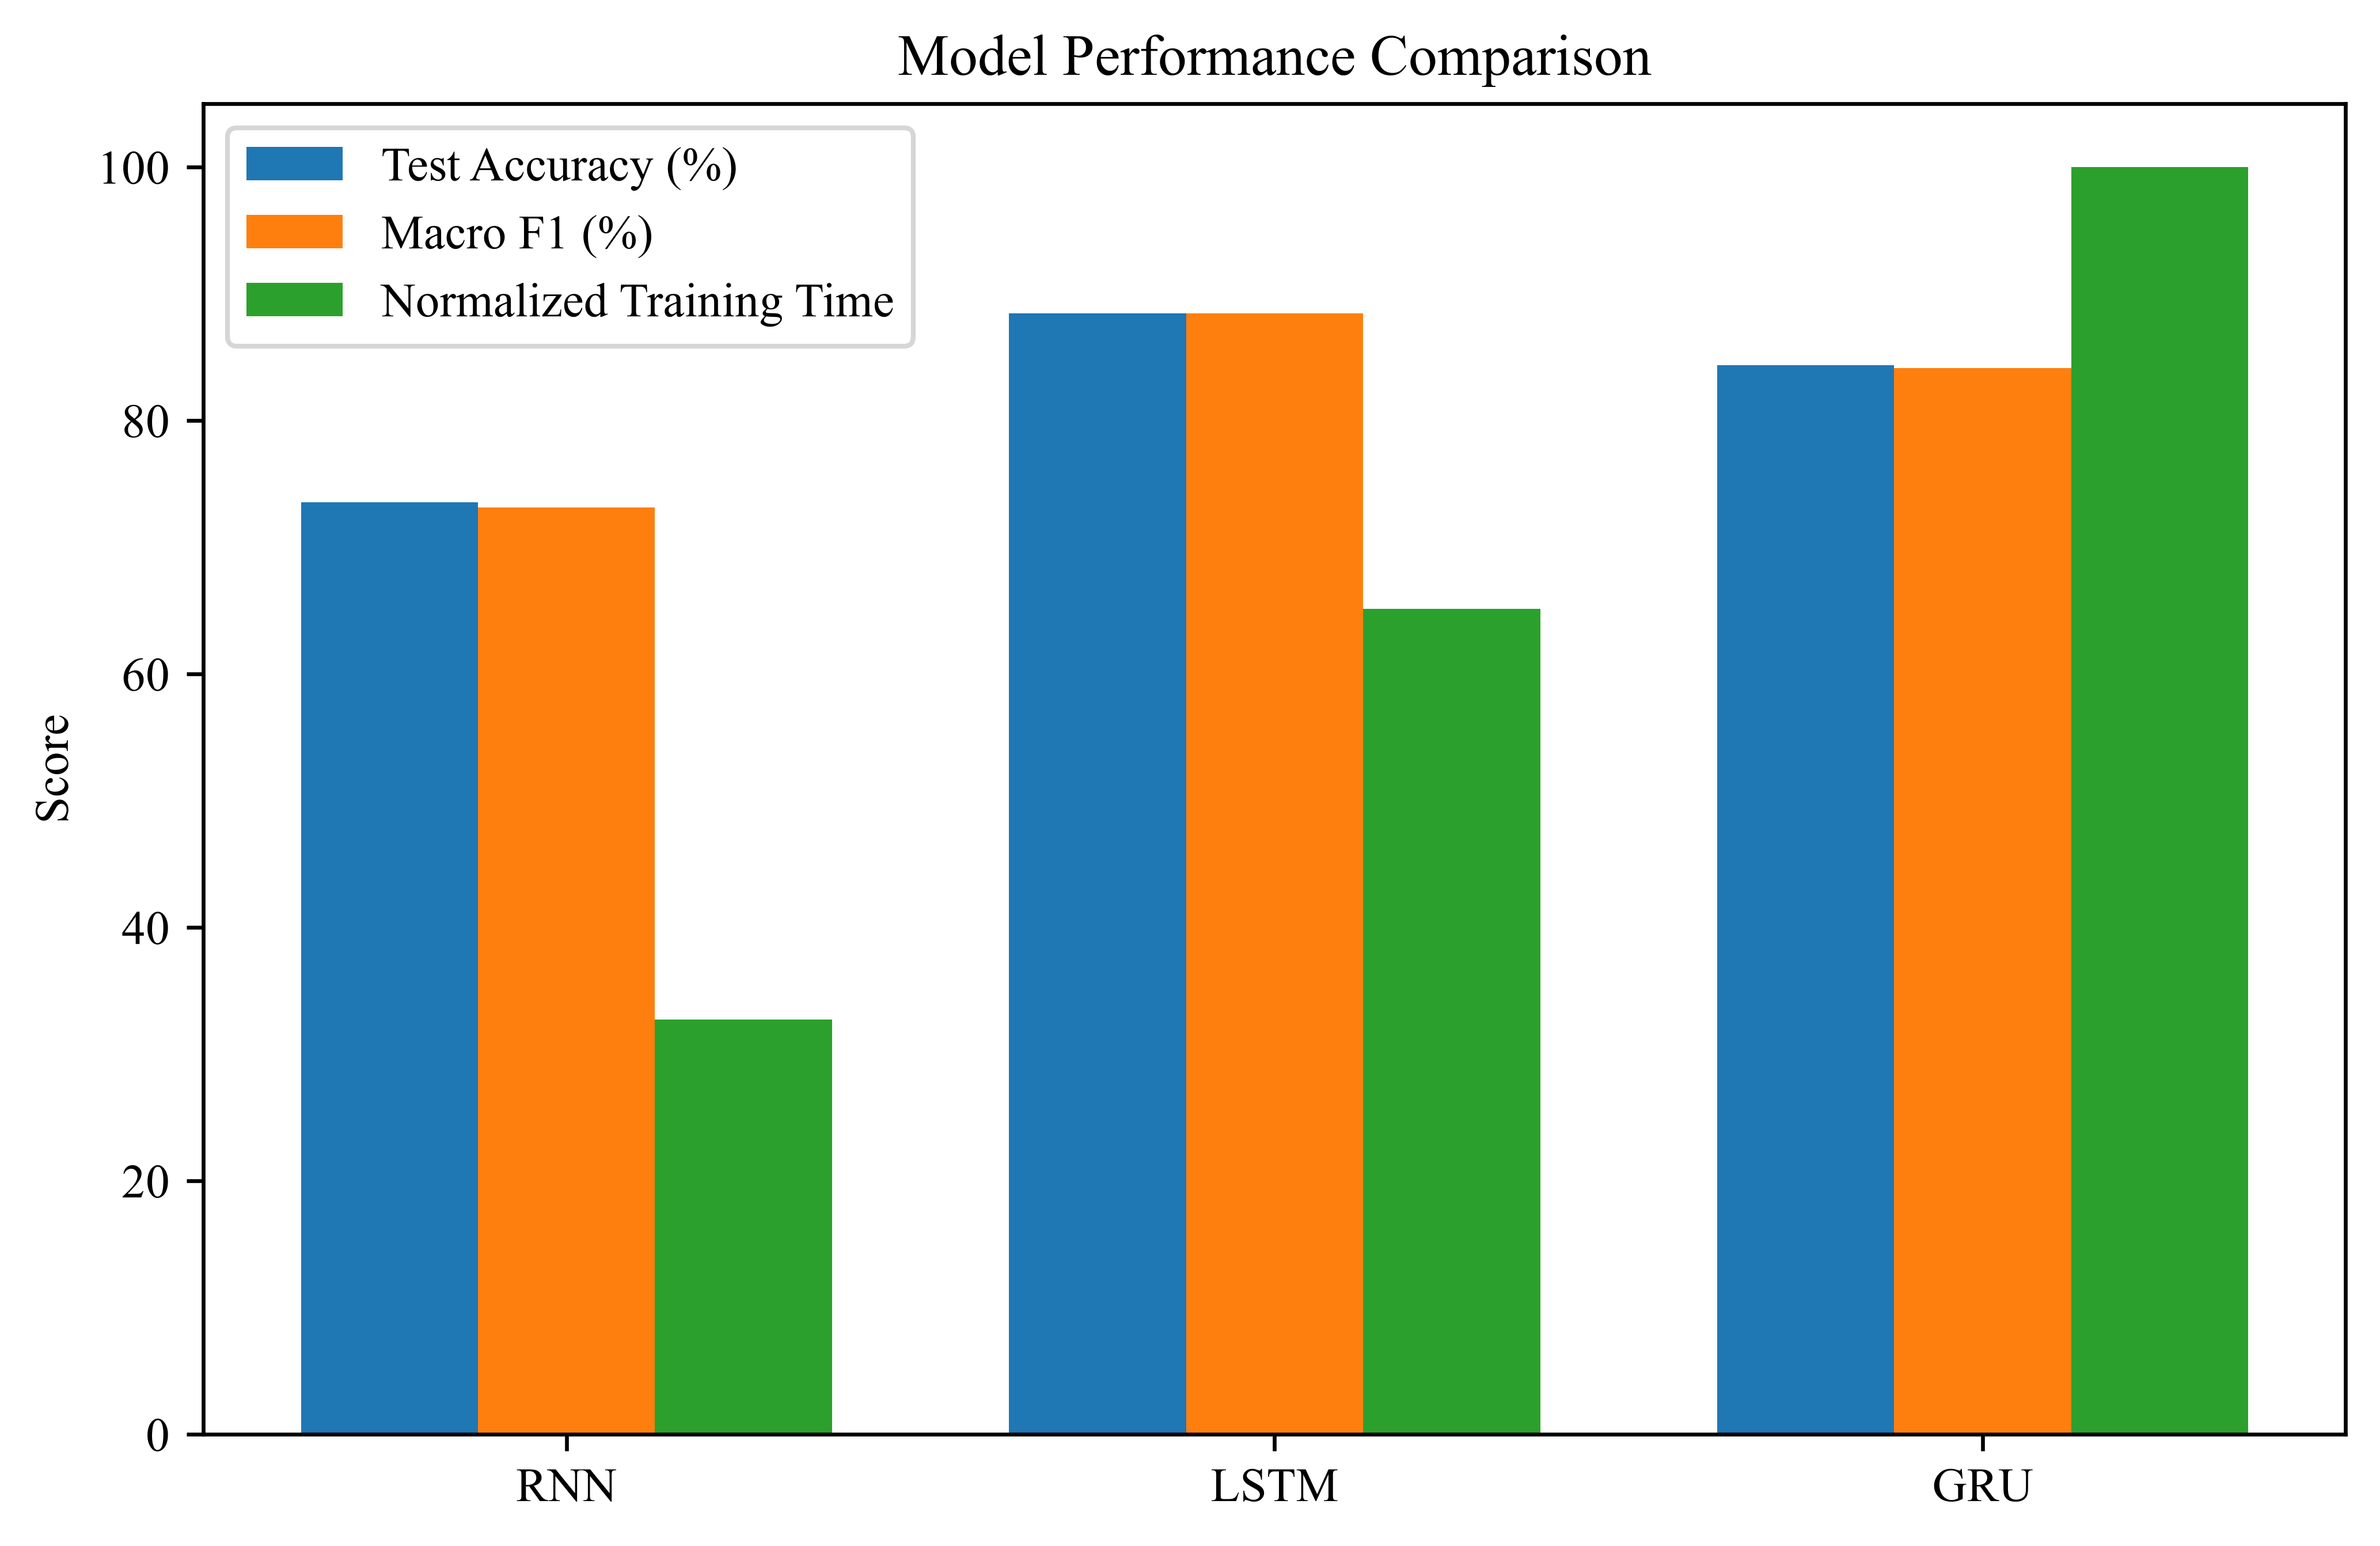

In [18]:
# Plot 5 - bar plot comparing test accuracy, macro F1 and normalized training time
models_list = ["RNN", "LSTM", "GRU"]
acc_vals = [results[m]["accuracy"] * 100 for m in models_list]
f1_vals = [results[m]["f1"] * 100 for m in models_list]
time_vals = [results[m]["train_time"] for m in models_list]
time_norm = [100 * t / max(time_vals) for t in time_vals]  # normalized to 0-100 for same axis

x = np.arange(len(models_list))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, acc_vals, width, label='Test Accuracy (%)')
plt.bar(x, f1_vals, width, label='Macro F1 (%)')
plt.bar(x + width, time_norm, width, label='Normalized Training Time')
plt.xticks(x, models_list)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
save_plot("model_comparison_bar")
plt.show()

# Inference: LSTM and GRU generally outperform the vanilla RNN on accuracy and
# F1-score because their gating mechanisms handle the 128-step dependency
# better, but this comes at the cost of more parameters and typically longer
# training time. GRU usually sits close to LSTM in accuracy while being a bit
# cheaper computationally since it has one fewer gate.
# Trade-off: Predictive Performance <-> Model Complexity <-> Training Cost -
# choosing RNN vs LSTM vs GRU in practice depends on how much of a bump in
# accuracy is worth the extra parameters and training time.



In [19]:
sequence_lengths = [32, 64, 128]
seq_len_results = {"RNN": [], "LSTM": [], "GRU": []}

for T in sequence_lengths:
    # truncating every window to the first T time steps, consistently across splits
    X_tr_T = X_train_norm[:, :T, :]
    X_va_T = X_val_norm[:, :T, :]
    X_te_T = X_test_norm[:, :T, :]

    print(f"\n--- Sequence length T = {T} ---")
    for rec_type in ["RNN", "LSTM", "GRU"]:
        res = train_and_evaluate(rec_type, X_tr_T, y_train, X_va_T, y_val, X_te_T, y_test,
                                  units=32, epochs=20, batch_size=32, verbose=0)
        seq_len_results[rec_type].append(res["f1"] * 100)

seq_len_table = pd.DataFrame({
    "Sequence Length": sequence_lengths,
    "RNN F1": seq_len_results["RNN"],
    "LSTM F1": seq_len_results["LSTM"],
    "GRU F1": seq_len_results["GRU"],
})
print(seq_len_table.to_string(index=False))


--- Sequence length T = 32 ---
[RNN] acc=0.6043  prec=0.5999  rec=0.5994  f1=0.5879  params=1974  time=4.7s
[LSTM] acc=0.8497  prec=0.8561  rec=0.8487  f1=0.8493  params=6006  time=7.0s
[GRU] acc=0.8280  prec=0.8308  rec=0.8271  f1=0.8257  params=4758  time=7.5s

--- Sequence length T = 64 ---
[RNN] acc=0.7058  prec=0.7000  rec=0.6956  f1=0.6948  params=1974  time=6.0s
[LSTM] acc=0.8531  prec=0.8556  rec=0.8533  f1=0.8517  params=6006  time=10.4s
[GRU] acc=0.8463  prec=0.8524  rec=0.8458  f1=0.8444  params=4758  time=13.3s

--- Sequence length T = 128 ---
[RNN] acc=0.6766  prec=0.6743  rec=0.6711  f1=0.6673  params=1974  time=9.2s
[LSTM] acc=0.8694  prec=0.8748  rec=0.8704  f1=0.8688  params=6006  time=17.2s
[GRU] acc=0.8442  prec=0.8504  rec=0.8428  f1=0.8421  params=4758  time=22.4s
 Sequence Length    RNN F1   LSTM F1    GRU F1
              32 58.788837 84.934970 82.565573
              64 69.477726 85.169105 84.438214
             128 66.726748 86.884985 84.214693


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved sequence_length_vs_f1.eps


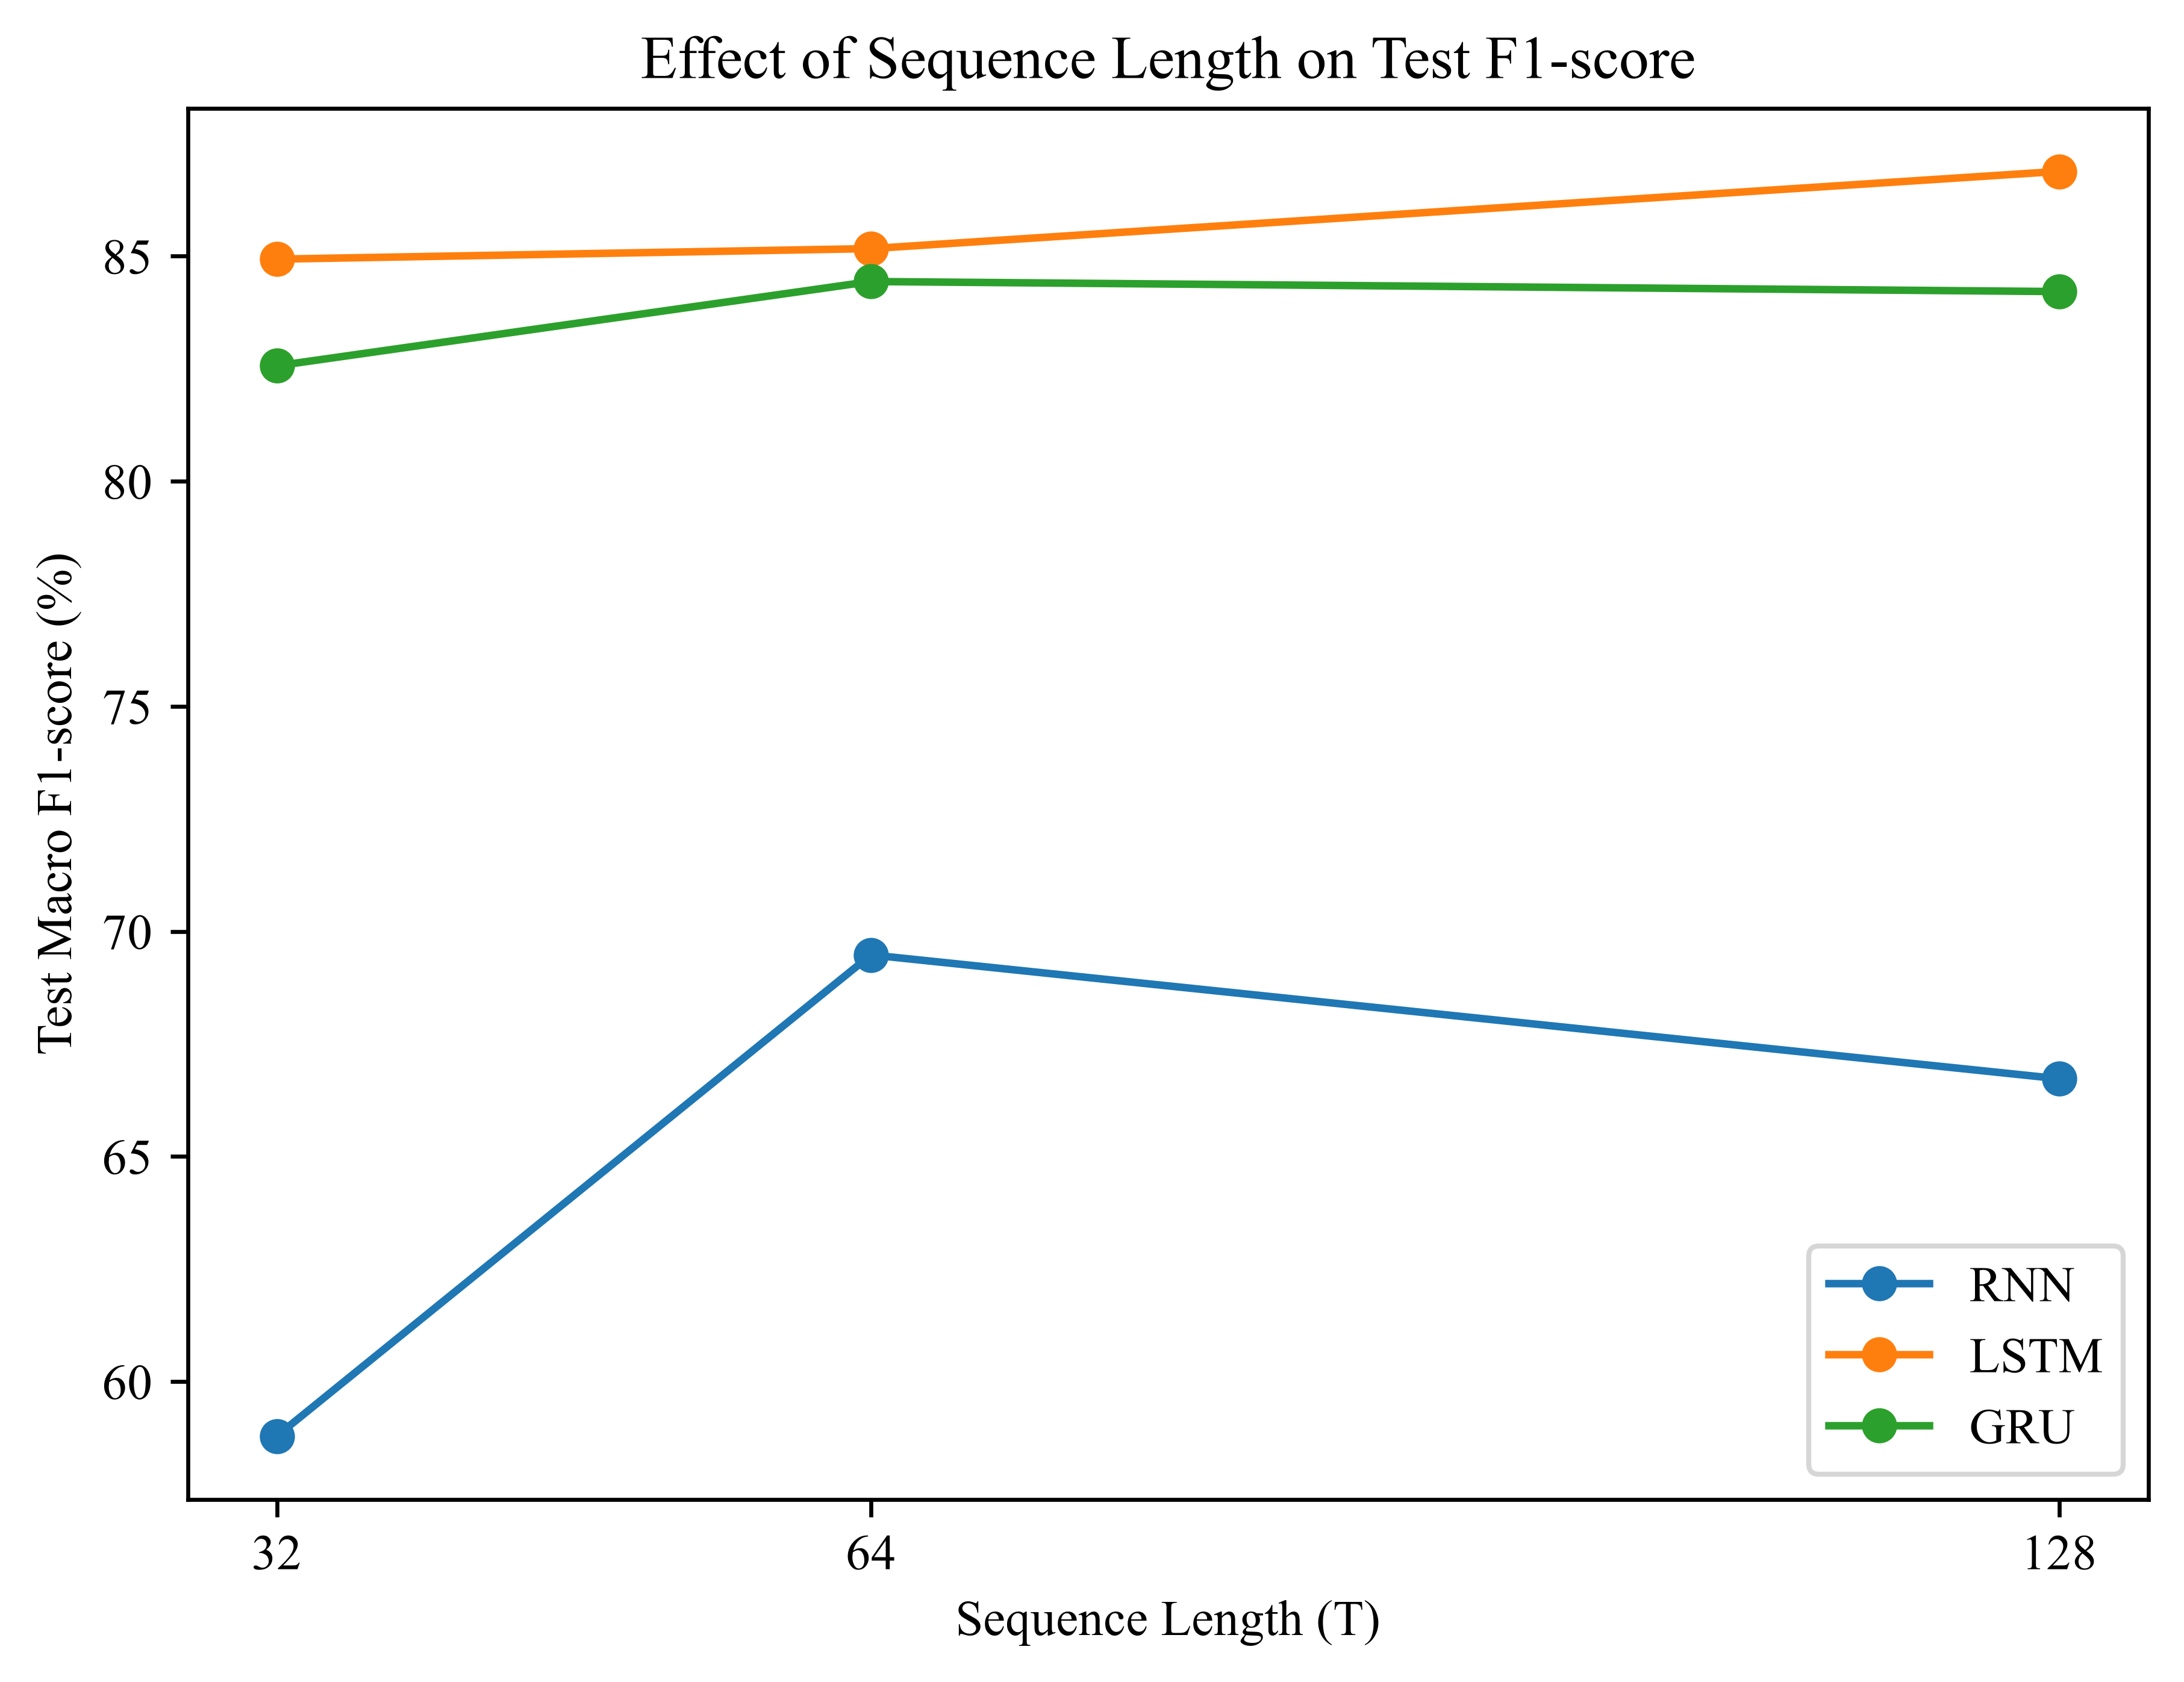

In [20]:
# Plot 6 - sequence length vs test F1-score
plt.figure(figsize=(7, 5))
for rec_type in ["RNN", "LSTM", "GRU"]:
    plt.plot(sequence_lengths, seq_len_results[rec_type], marker='o', label=rec_type)
plt.xlabel("Sequence Length (T)")
plt.ylabel("Test Macro F1-score (%)")
plt.title("Effect of Sequence Length on Test F1-score")
plt.xticks(sequence_lengths)
plt.legend()
save_plot("sequence_length_vs_f1")
plt.show()

# Inference: as the sequence length increases from 32 to 128, the models see
# more temporal context per window, which usually improves F1-score since
# activities like WALKING are better distinguished over a longer window.
# LSTM and GRU tend to benefit more from the extra context than the vanilla
# RNN, which can struggle to make good use of the longer sequence because of
# its weaker long-term memory.

In [21]:
import sys, subprocess

INSTALL_DIR = r"C:\Users\Kishore\cv2_local_install"

subprocess.run([
    sys.executable, "-m", "pip", "install",
    "--target", INSTALL_DIR,
    "opencv-python-headless"
], check=True)

sys.path.insert(0, INSTALL_DIR)

del sys.modules['cv2']
import cv2
print("cv2 loaded OK, version:", cv2.__version__)

cv2 loaded OK, version: 5.0.0


In [23]:
# NOTE: this section expects a small local subset of UCF101 already
# downloaded and organised as:
#   UCF101_subset/<split>/<ClassName>/<video>.avi   (split = train/val/test)
# This is the layout produced by the small "sayakpaul/ucf101-subset" dataset
# on Hugging Face (10 classes, ~405 clips, ~171MB total - used here instead
# of the full ~6.5GB UCF101 release since the lab only asks for 3-5 classes
# and a handful of videos per class). Download + extract it with:
#
#   pip install huggingface_hub
#   from huggingface_hub import hf_hub_download
#   import tarfile
#   p = hf_hub_download(repo_id="sayakpaul/ucf101-subset",
#                        filename="UCF101_subset.tar.gz", repo_type="dataset")
#   with tarfile.open(p) as t: t.extractall(".")

VIDEO_DATASET_DIR = "UCF101_subset"
VIDEO_SPLITS = ["train", "val", "test"]  # the HF subset ships pre-split into these
NUM_VIDEO_CLASSES = 5  # how many classes to use, per the lab's "3-5 classes" instruction
NUM_FRAMES = 10
FRAME_SIZE = (224, 224)
video_metrics = None  # filled in below only if this section actually runs

try:
    import cv2
    CV2_AVAILABLE = True
except ImportError:
    CV2_AVAILABLE = False
    print("opencv-python not installed - install it with 'pip install opencv-python' "
          "to run the video understanding section")


def discover_video_classes(root_dir, splits, n_classes):
    """Picks the n_classes with the most videos out of whatever class
    folders actually exist under root_dir/<split>/, instead of hardcoding
    class names that may not match whichever UCF101 subset got downloaded."""
    counts = {}
    for split in splits:
        split_dir = os.path.join(root_dir, split)
        if not os.path.isdir(split_dir):
            continue
        for cls in os.listdir(split_dir):
            cls_dir = os.path.join(split_dir, cls)
            if os.path.isdir(cls_dir):
                counts[cls] = counts.get(cls, 0) + len(os.listdir(cls_dir))
    ranked = sorted(counts.items(), key=lambda kv: kv[1], reverse=True)
    return [cls for cls, _ in ranked[:n_classes]]


VIDEO_CLASSES = (discover_video_classes(VIDEO_DATASET_DIR, VIDEO_SPLITS, NUM_VIDEO_CLASSES)
                  if os.path.isdir(VIDEO_DATASET_DIR) else [])
print("Video classes selected:", VIDEO_CLASSES)


def sample_frames(video_path, num_frames=NUM_FRAMES, frame_size=FRAME_SIZE):
    """Uniformly samples num_frames frames from a video and resizes them."""
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    total = max(total, num_frames)
    indices = np.linspace(0, total - 1, num_frames).astype(int)

    frames = []
    for i in range(total):
        ret, frame = cap.read()
        if not ret:
            break
        if i in indices:
            frame = cv2.resize(frame, frame_size)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
    cap.release()

    # if the video was shorter than expected, pad by repeating the last frame
    while len(frames) < num_frames:
        frames.append(frames[-1] if frames else np.zeros((*frame_size, 3), dtype=np.uint8))
    return np.array(frames[:num_frames])

Video classes selected: ['Basketball', 'BaseballPitch', 'BabyCrawling', 'BandMarching', 'BenchPress']


In [27]:
# building the pretrained CNN feature extractor (MobileNetV2, frozen, no top)
cnn_base = MobileNetV2(weights='imagenet', include_top=False, pooling='avg',
                            input_shape=(*FRAME_SIZE, 3))
cnn_base.trainable = False  # freezing the pretrained CNN, as instructed
FEATURE_DIM = cnn_base.output_shape[-1]
print("CNN feature dimension D =", FEATURE_DIM)


CNN feature dimension D = 1280


In [28]:
video_paths, video_labels = [], []
for split in VIDEO_SPLITS:
    for cls in VIDEO_CLASSES:
        cls_dir = os.path.join(VIDEO_DATASET_DIR, split, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            video_paths.append(os.path.join(cls_dir, fname))
            video_labels.append(cls)

label_to_idx = {cls: i for i, cls in enumerate(VIDEO_CLASSES)}
y_video = np.array([label_to_idx[lbl] for lbl in video_labels])
print(f"Found {len(video_paths)} videos across {len(VIDEO_CLASSES)} classes")

Found 228 videos across 5 classes


In [29]:
 # extracting 10 CNN feature vectors per video -> X_video shape (B, 10, D)
all_features = []
sample_frame_stack = None
for vp in video_paths:
    frames = sample_frames(vp)
    if sample_frame_stack is None:
        sample_frame_stack = frames  # keep one example for Plot 7
    frames_pre = preprocess_input(frames.astype('float32'))
    feats = cnn_base.predict(frames_pre, verbose=0)  # shape (10, D)
    all_features.append(feats)
X_video = np.array(all_features)  # (B, 10, D)
print("Video feature tensor shape supplied to the recurrent network:", X_video.shape)


Video feature tensor shape supplied to the recurrent network: (228, 10, 1280)


saved video_sample_frames.eps


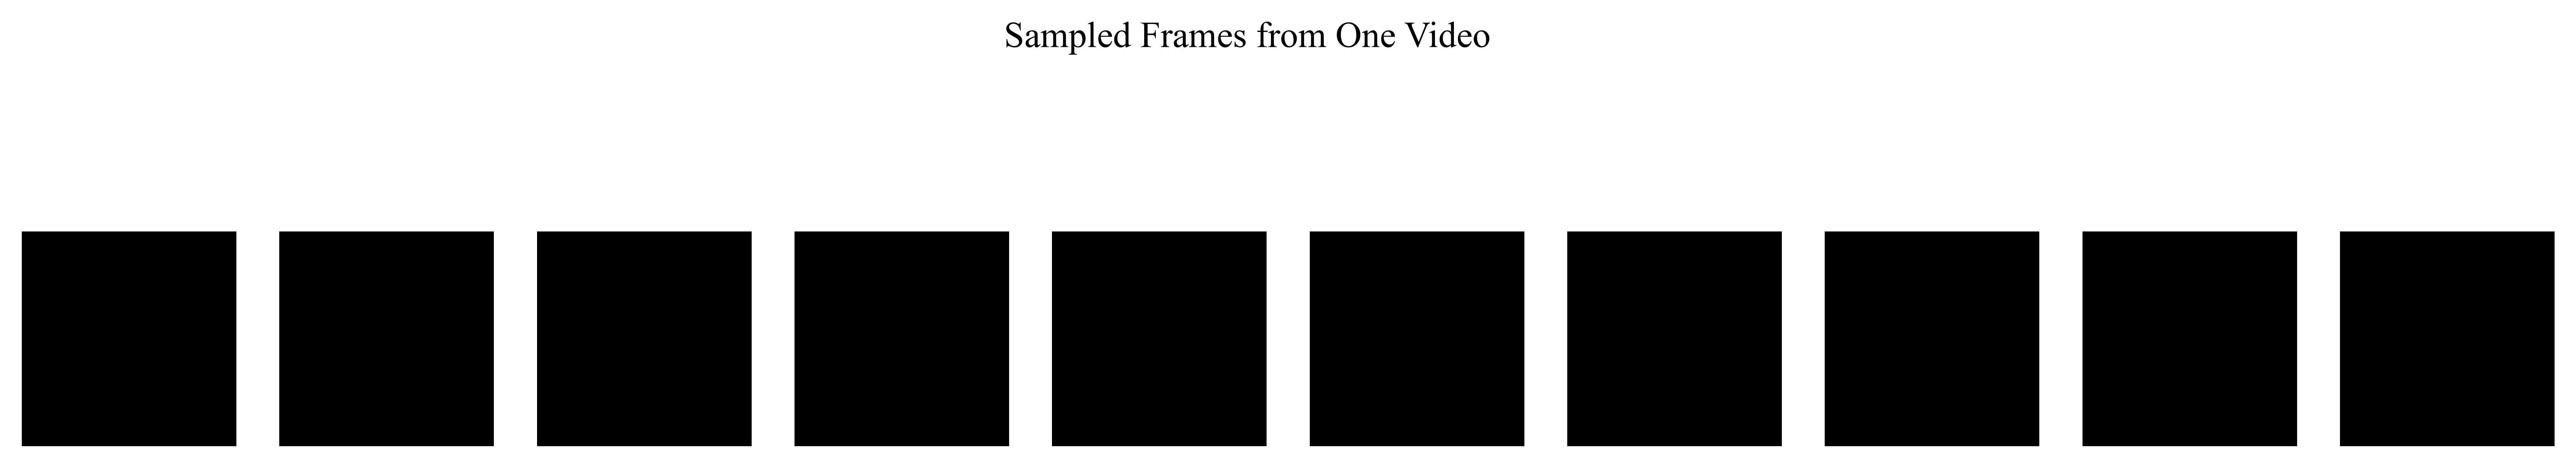

In [30]:
# Plot 7 - sample frames from one video
plt.figure(figsize=(15, 3))
for i in range(NUM_FRAMES):
    plt.subplot(1, NUM_FRAMES, i + 1)
    plt.imshow(sample_frame_stack[i])
    plt.axis('off')
plt.suptitle("Sampled Frames from One Video")
save_plot("video_sample_frames")
plt.show()


In [31]:
Xv_train, Xv_test, yv_train, yv_test = train_test_split(
        X_video, y_video, test_size=0.2, stratify=y_video, random_state=42
    )

def build_video_model(recurrent_type, feature_dim=FEATURE_DIM, num_classes=len(VIDEO_CLASSES)):
    rec_layer = layers.LSTM(32) if recurrent_type == "LSTM" else layers.GRU(32)
    model = models.Sequential([
            layers.Input(shape=(NUM_FRAMES, feature_dim)),
            rec_layer,
            layers.Dense(16, activation='relu'),
            layers.Dense(num_classes, activation='softmax')
        ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
    return model

video_model = build_video_model("LSTM")
video_history = video_model.fit(Xv_train, yv_train, validation_data=(Xv_test, yv_test),
                                     epochs=30, batch_size=8, verbose=0)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved video_loss_curve.eps


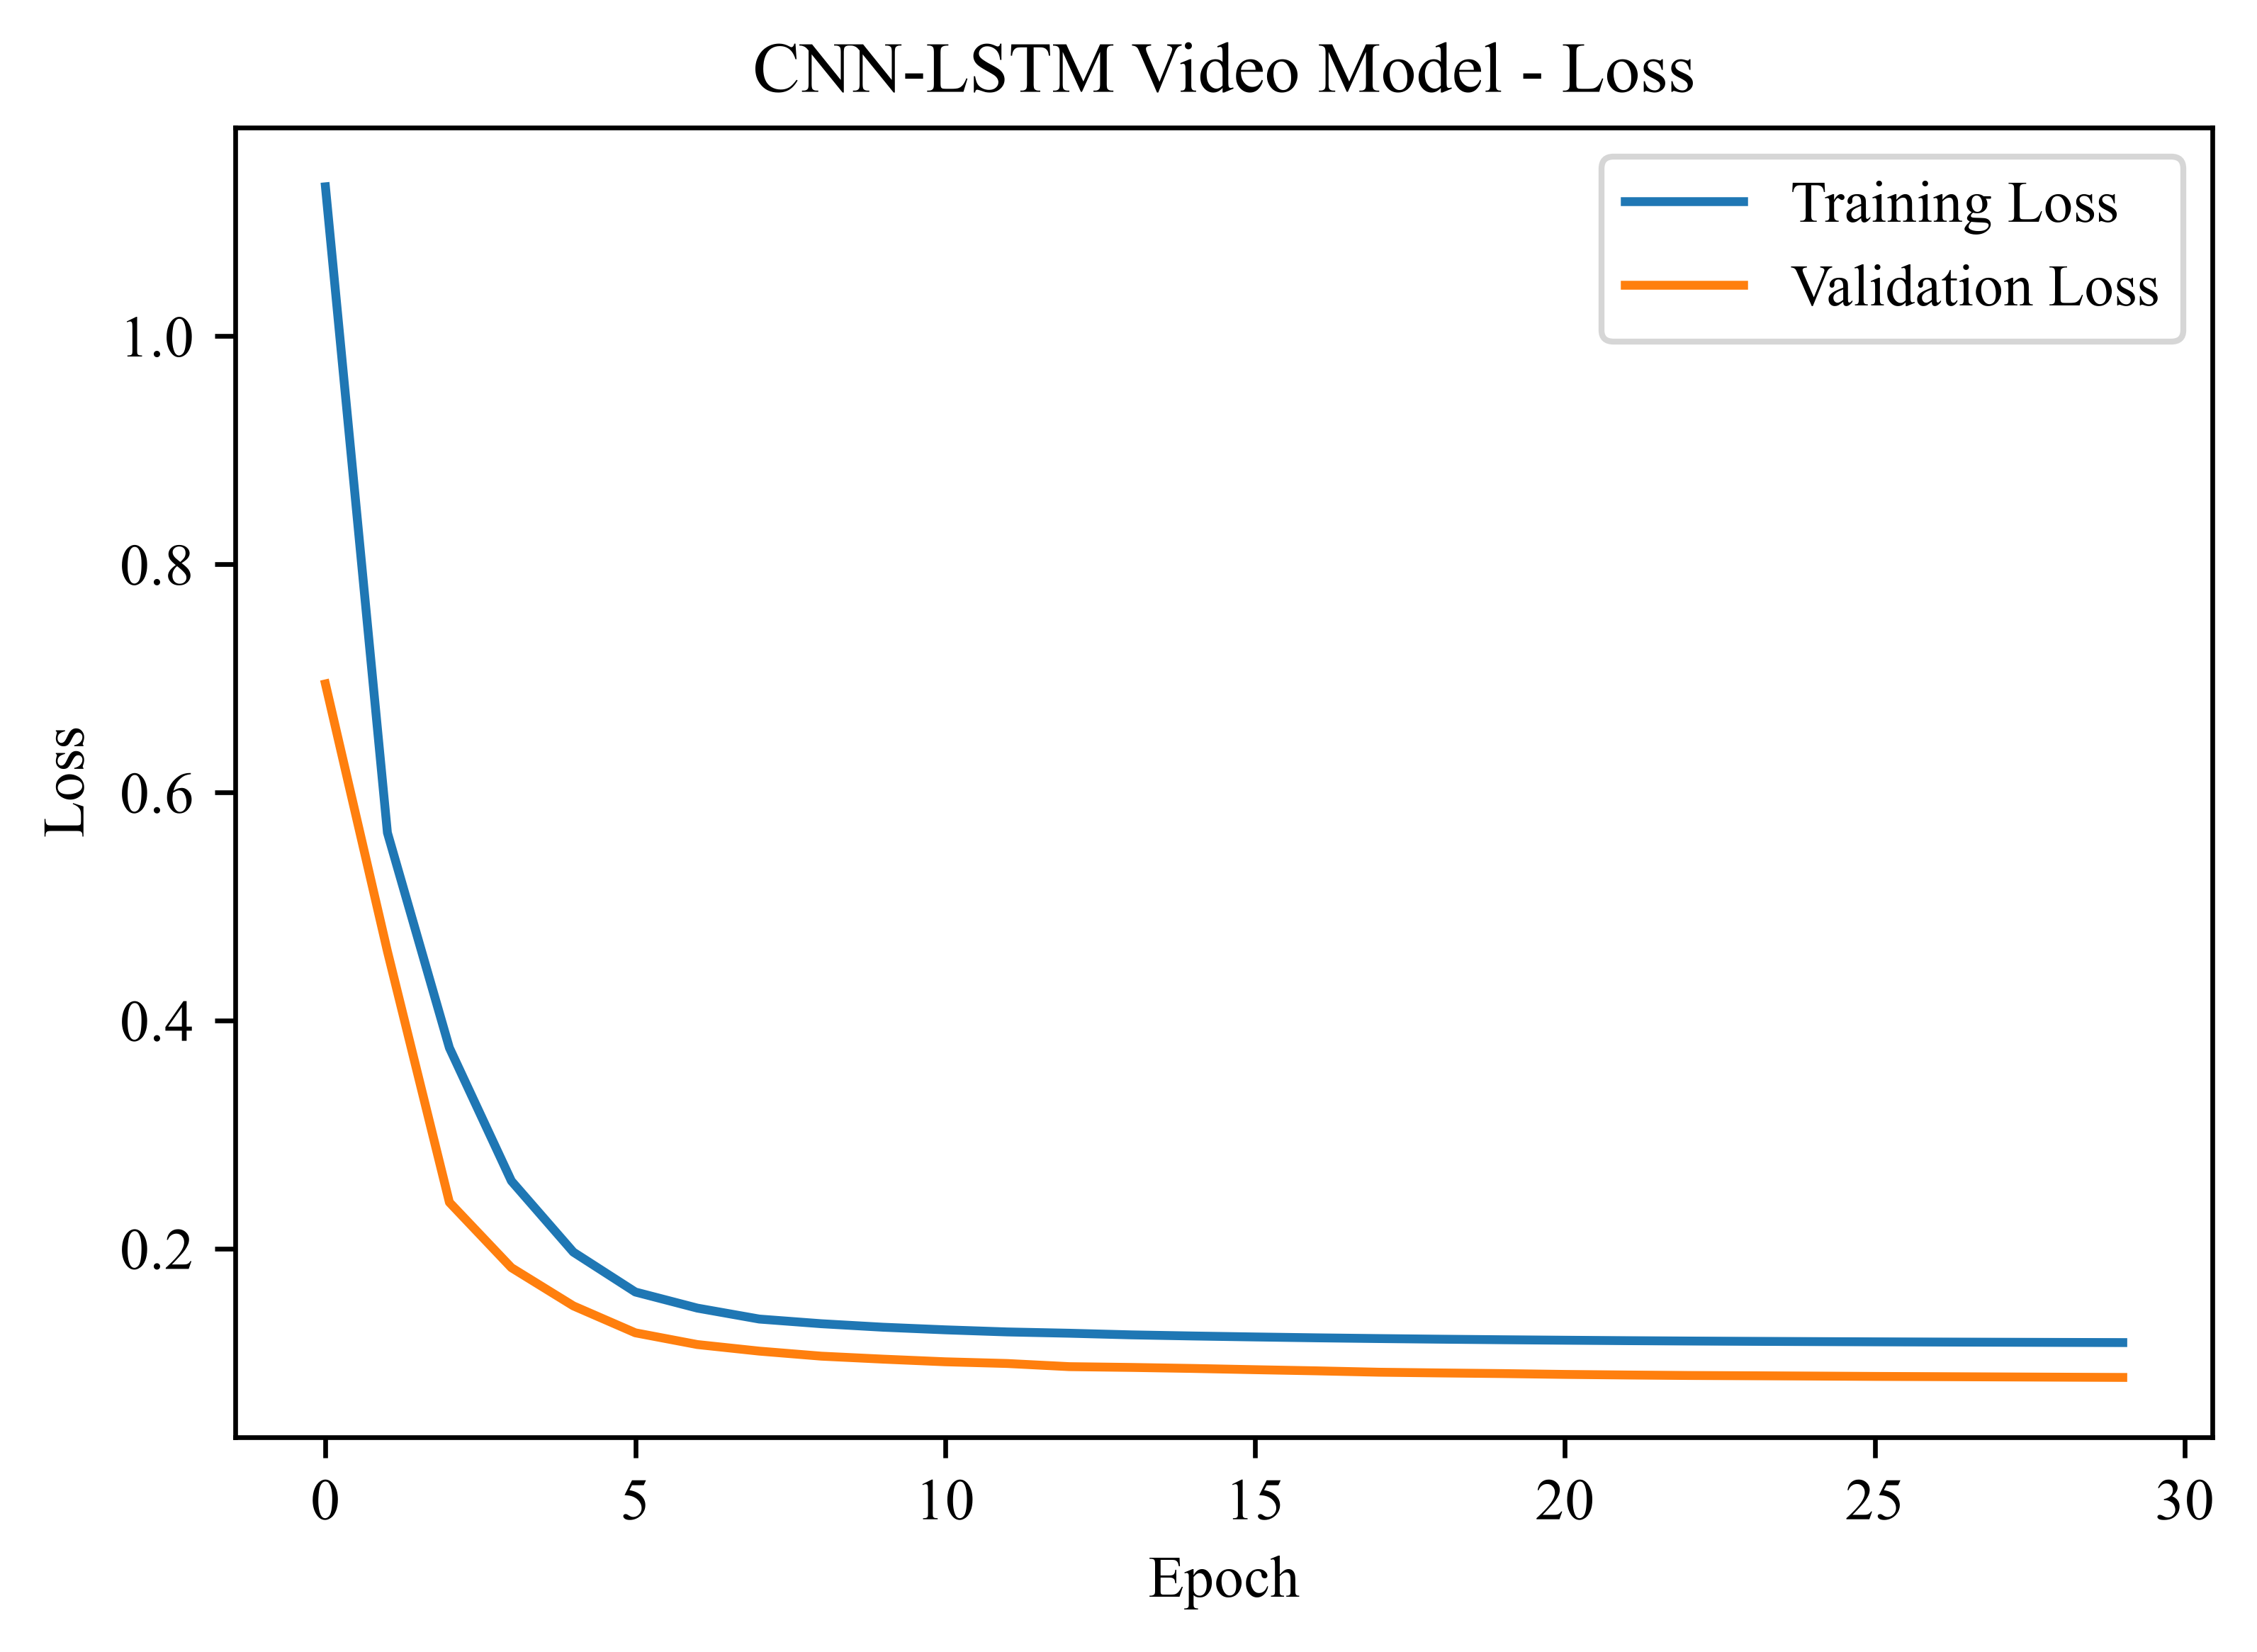

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved video_accuracy_curve.eps


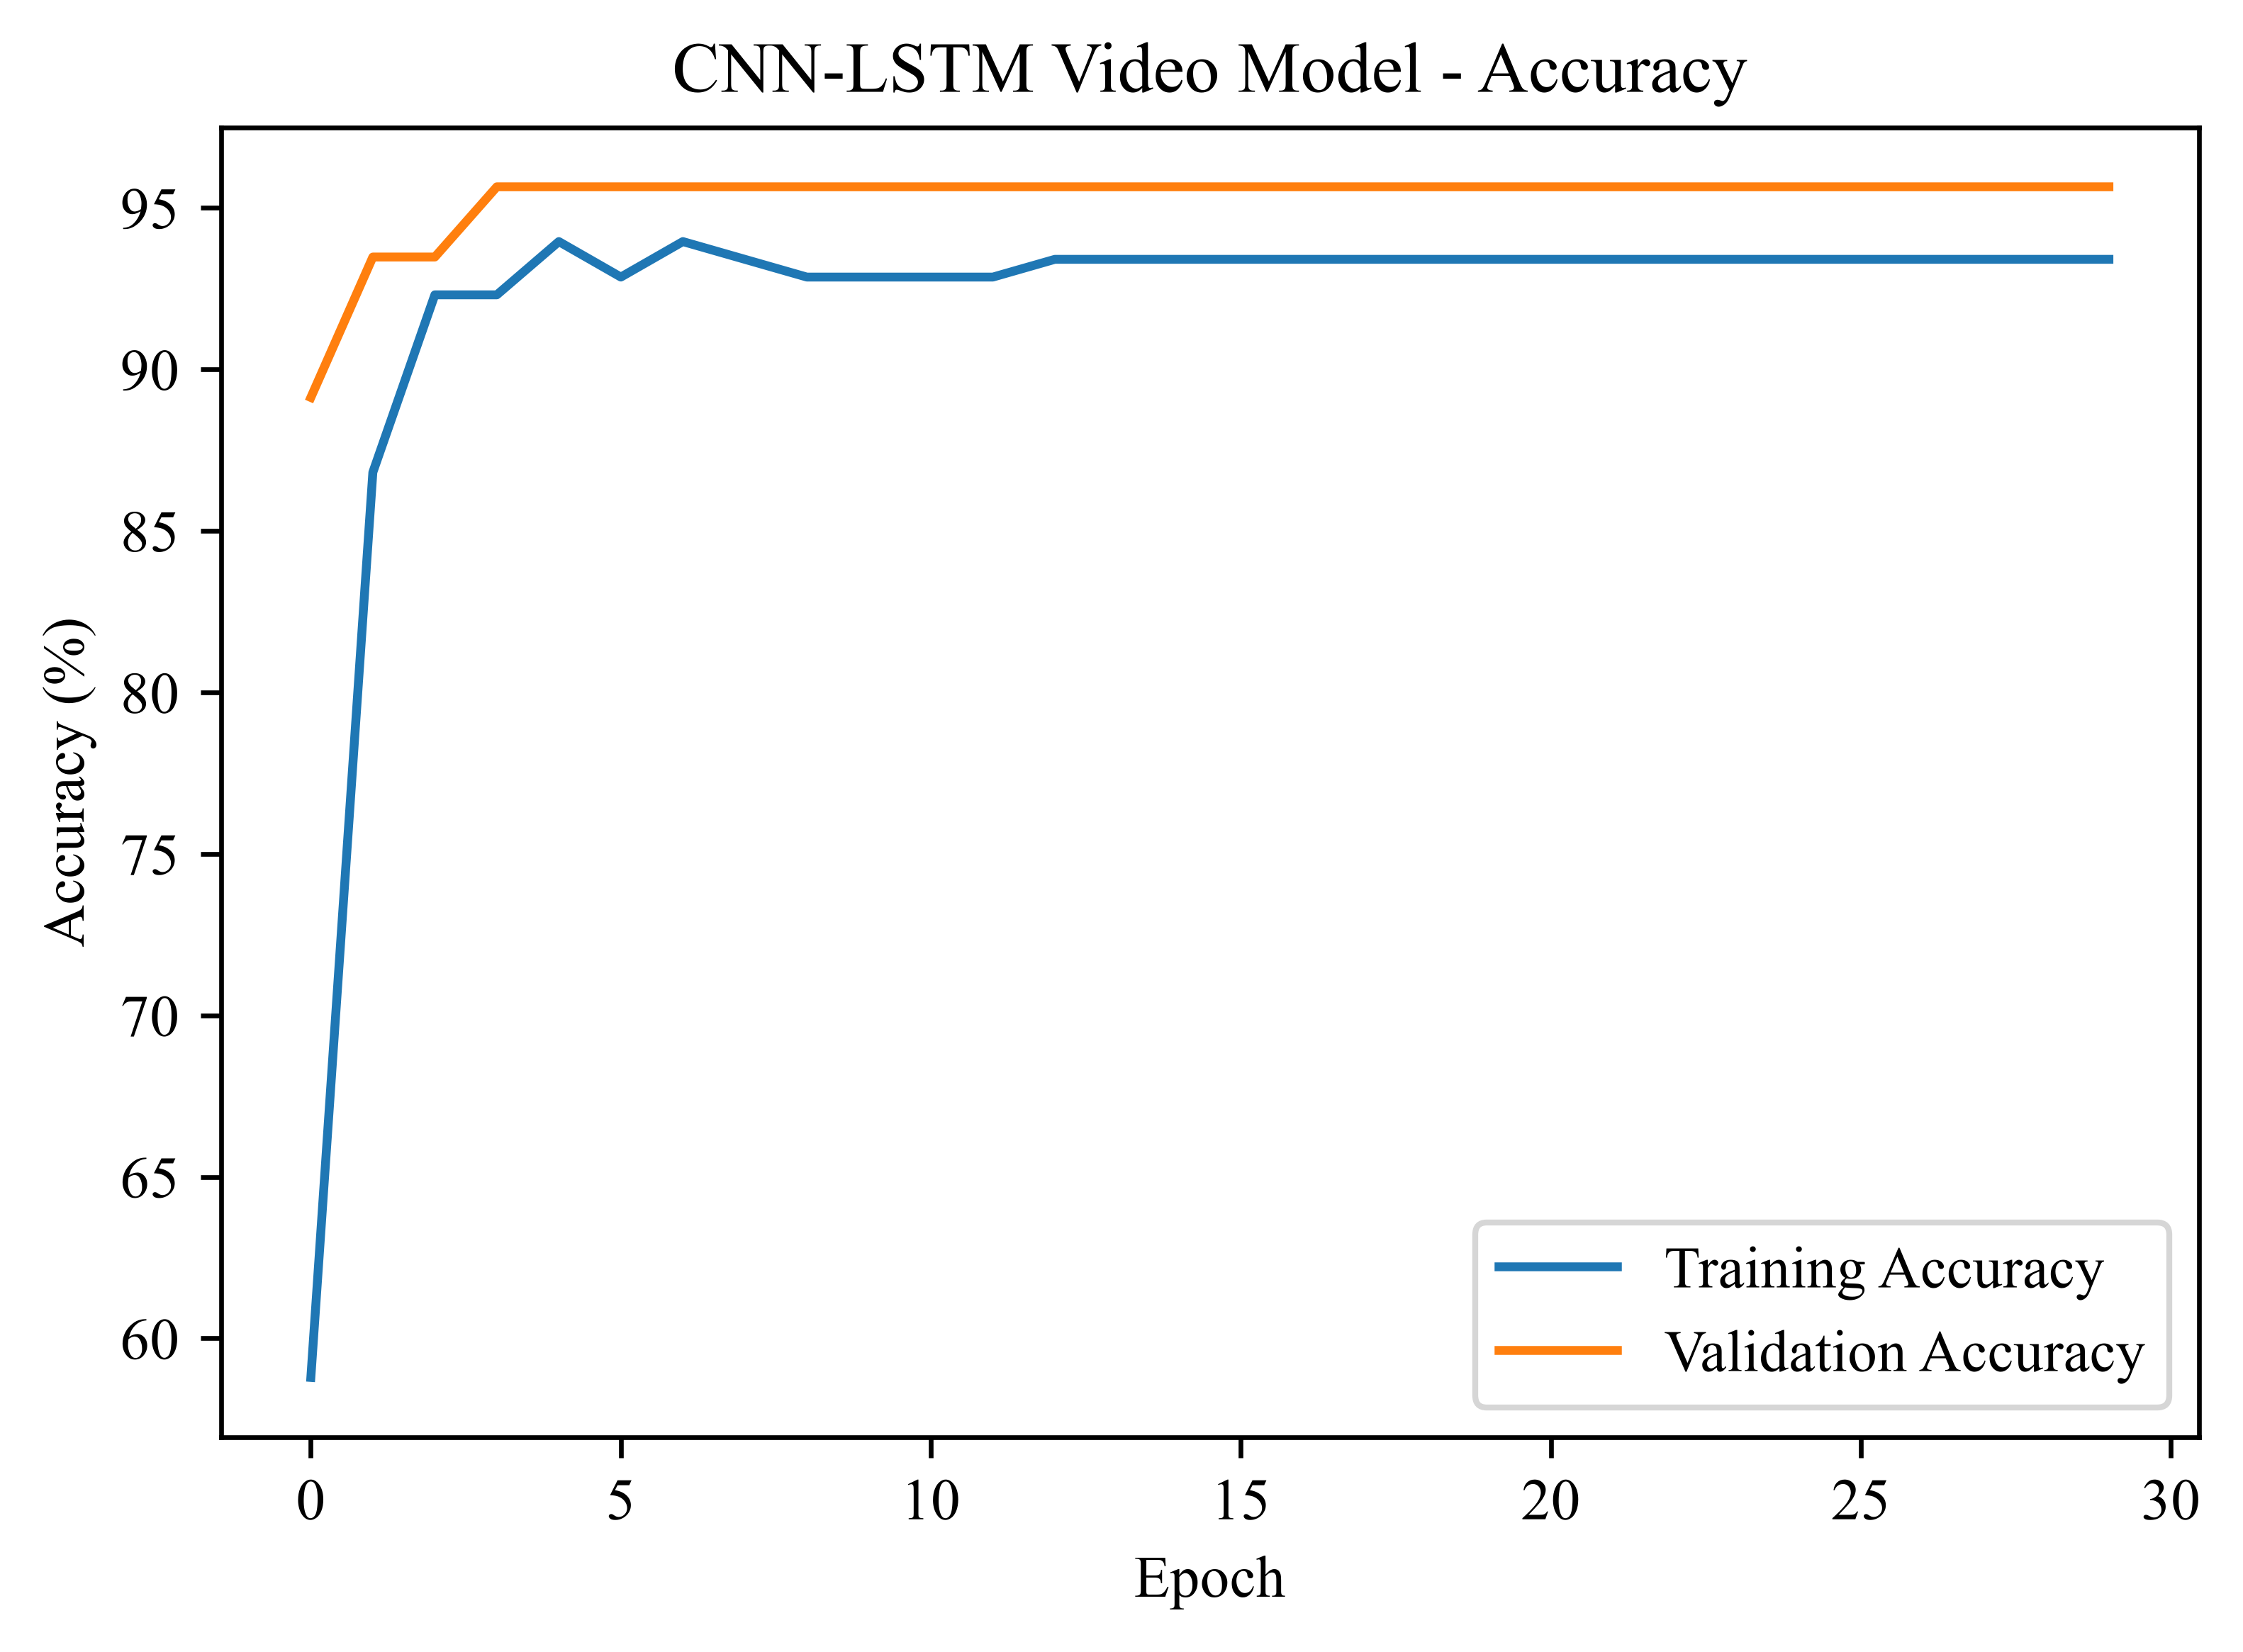

In [32]:
# Plot 8 - video training/validation curves
plt.figure(figsize=(6, 4))
plt.plot(video_history.history['loss'], label='Training Loss')
plt.plot(video_history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("CNN-LSTM Video Model - Loss")
plt.legend()
save_plot("video_loss_curve")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(np.array(video_history.history['accuracy']) * 100, label='Training Accuracy')
plt.plot(np.array(video_history.history['val_accuracy']) * 100, label='Validation Accuracy')
plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)")
plt.title("CNN-LSTM Video Model - Accuracy")
plt.legend()
save_plot("video_accuracy_curve")
plt.show()


In [35]:
yv_pred = np.argmax(video_model.predict(Xv_test, verbose=0), axis=1)
print("Example prediction:")
print("Predicted class:", VIDEO_CLASSES[yv_pred[0]])
print("Actual class   :", VIDEO_CLASSES[yv_test[0]])
print("Confidence     :", np.max(video_model.predict(Xv_test, verbose=0)[0]))

Example prediction:
Predicted class: Basketball
Actual class   : Basketball
Confidence     : 0.9989236


saved video_confusion_matrix.eps


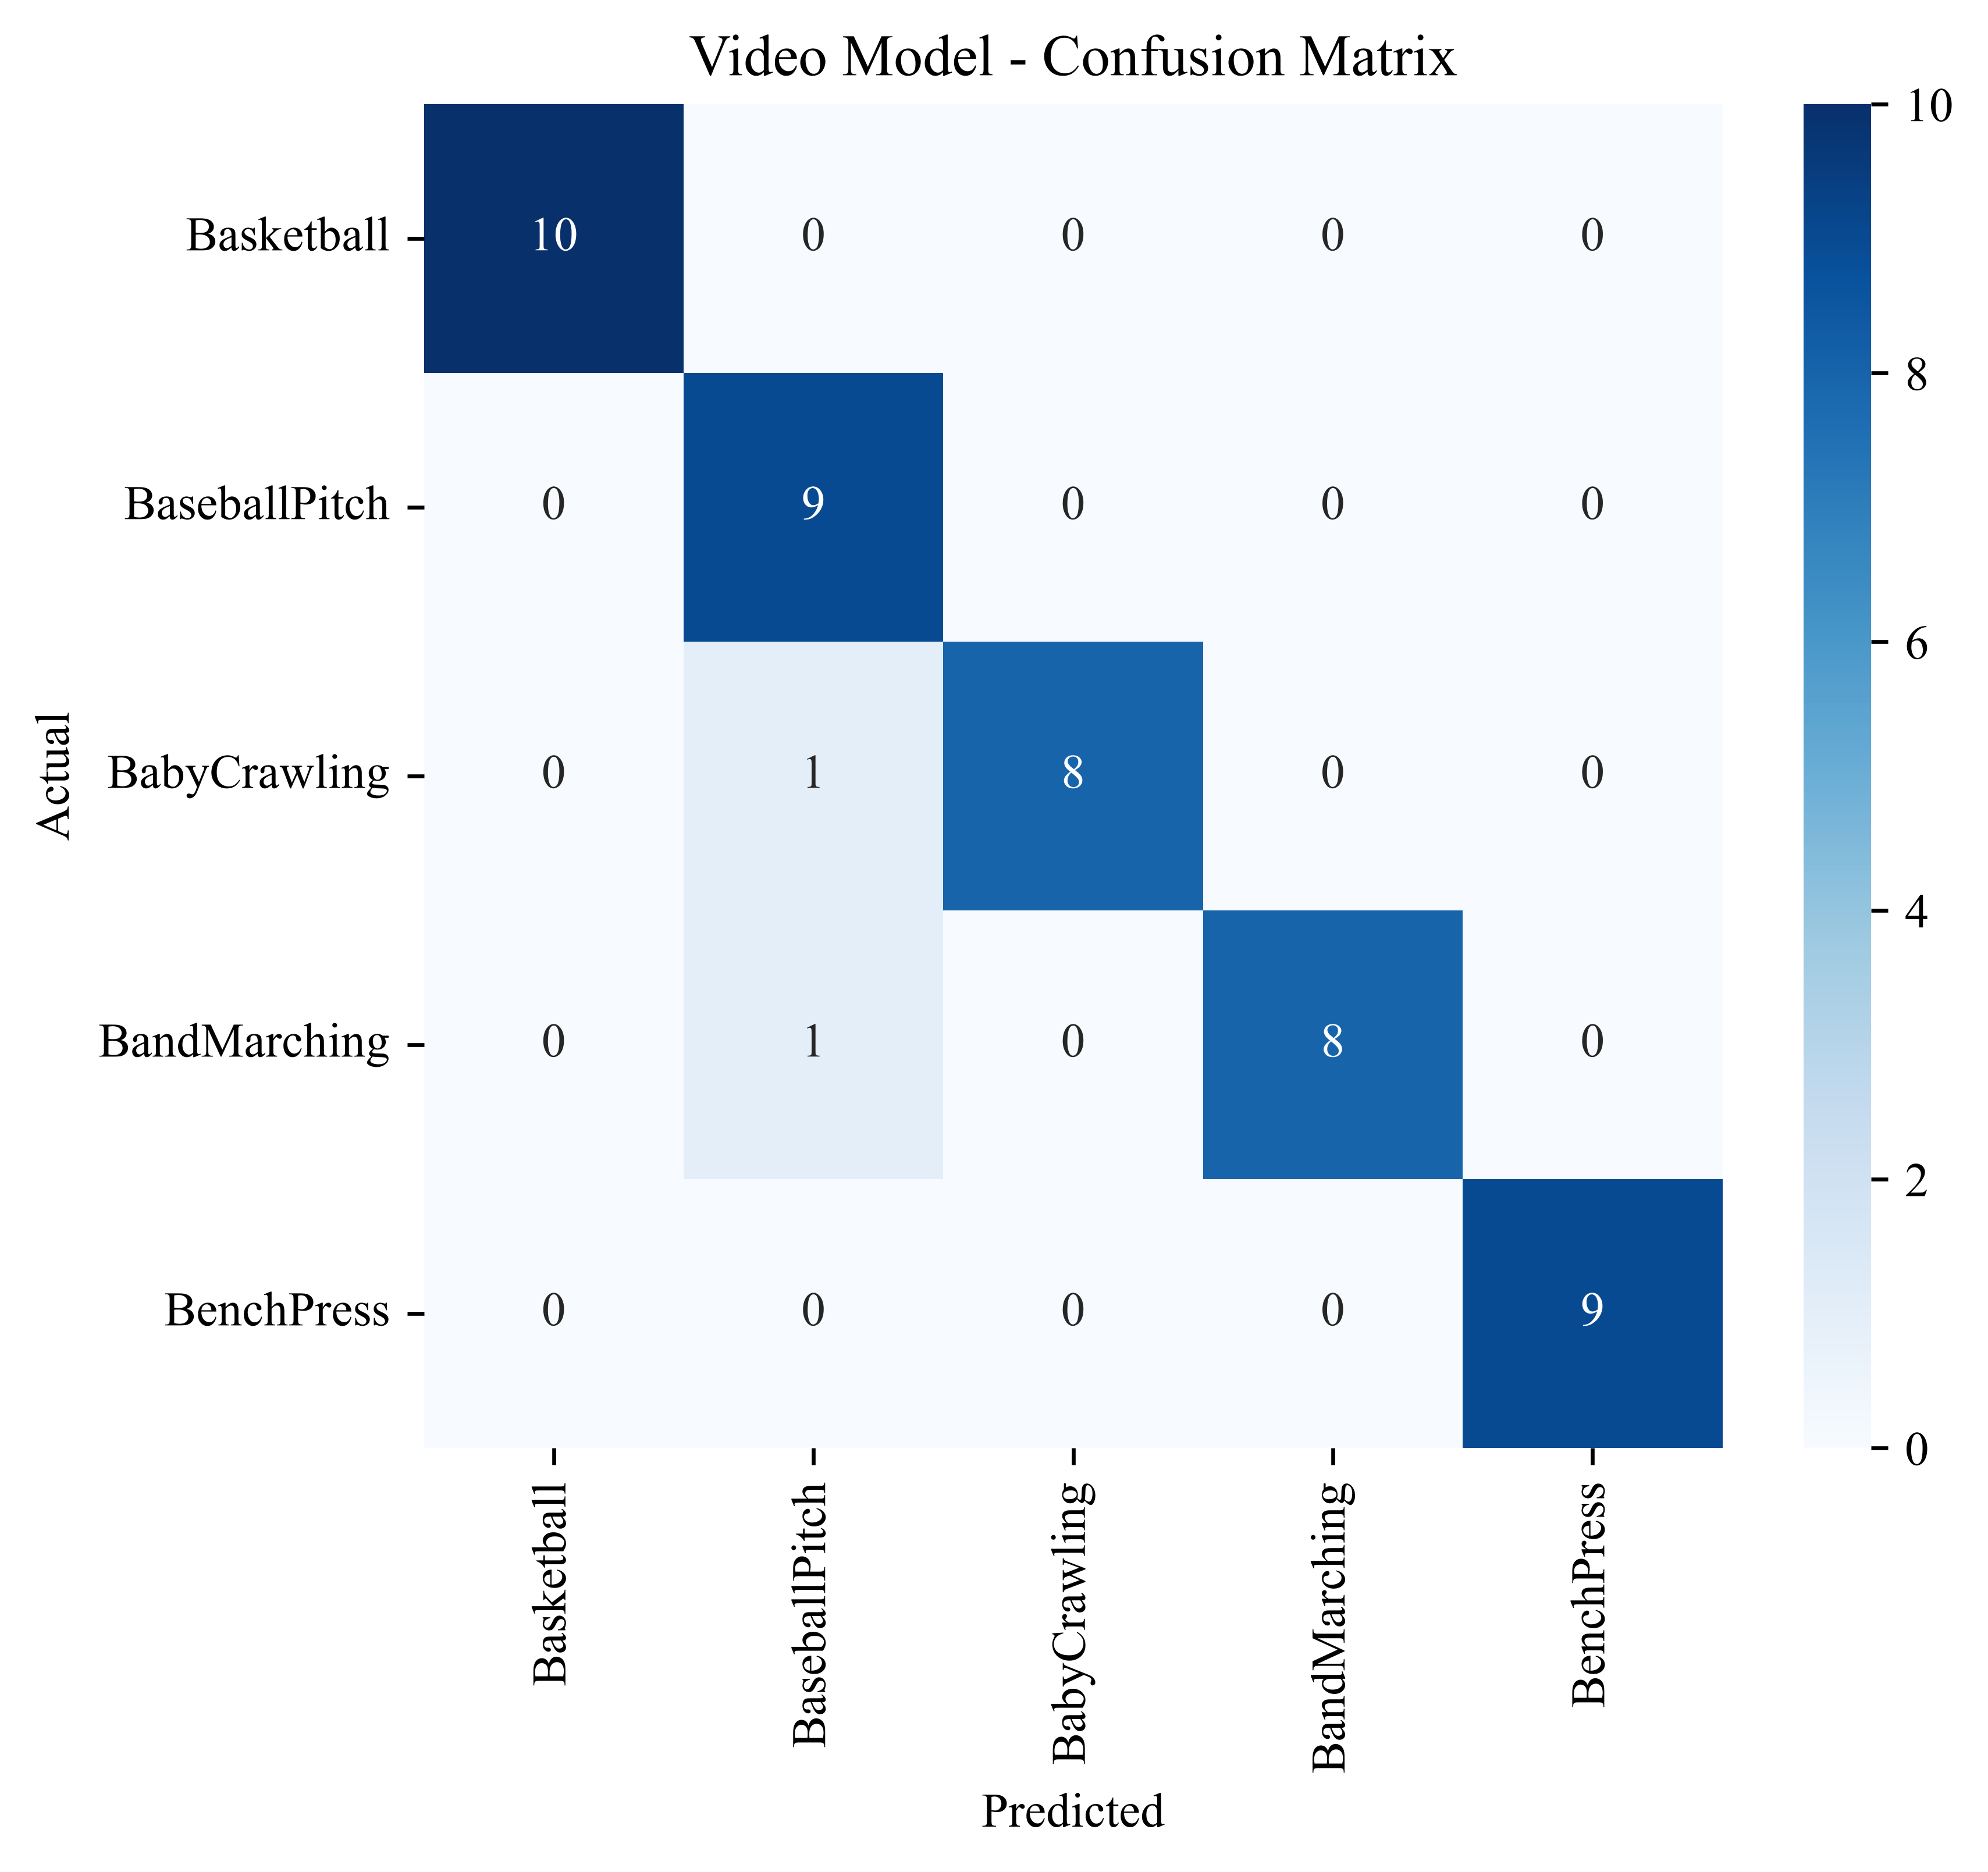

In [36]:
 # Plot 9 - video confusion matrix
cm_video = confusion_matrix(yv_test, yv_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_video, annot=True, fmt='d', cmap='Blues',
            xticklabels=VIDEO_CLASSES, yticklabels=VIDEO_CLASSES)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Video Model - Confusion Matrix")
save_plot("video_confusion_matrix")
plt.show()

# Inference: the CNN captures spatial appearance in each frame (objects,
# scene context, body pose), while the LSTM/GRU on top learns how those
# per-frame features change over time, which is what actually separates
# actions like Basketball vs Biking that can share similar backgrounds.

In [37]:
 # capturing the same metric set as the HAR models so it can go into the
    # Section 25 consolidated results table below
video_metrics = {
    "accuracy": accuracy_score(yv_test, yv_pred),
    "precision": precision_score(yv_test, yv_pred, average='macro', zero_division=0),
    "recall": recall_score(yv_test, yv_pred, average='macro', zero_division=0),
    "f1": f1_score(yv_test, yv_pred, average='macro', zero_division=0),
    "params": video_model.count_params(),
}

In [38]:
# generating a synthetic reversal dataset: input is a short sequence of
# integers, target is the same sequence reversed
VOCAB_SIZE = 10          # digits 0-9
SEQ_LEN = 4              # length of each sequence
NUM_SAMPLES = 5000
PAD_TOKEN = VOCAB_SIZE   # extra token used to mark start-of-sequence for the decoder
START_TOKEN = VOCAB_SIZE

rng = np.random.default_rng(42)
seq_inputs = rng.integers(0, VOCAB_SIZE, size=(NUM_SAMPLES, SEQ_LEN))
seq_targets = seq_inputs[:, ::-1]

# decoder input is the target shifted right with a start token prepended
# (this is "teacher forcing" - the decoder is fed the correct previous token
# during training instead of its own earlier prediction)
decoder_input = np.concatenate(
    [np.full((NUM_SAMPLES, 1), START_TOKEN), seq_targets[:, :-1]], axis=1
)

# one-hot encoding everything since the vocabulary is tiny
enc_in_oh = to_categorical(seq_inputs, num_classes=VOCAB_SIZE + 1)
dec_in_oh = to_categorical(decoder_input, num_classes=VOCAB_SIZE + 1)
dec_out_oh = to_categorical(seq_targets, num_classes=VOCAB_SIZE + 1)

(Xs_enc_train, Xs_enc_test, Xs_dec_train, Xs_dec_test,
 ys_train, ys_test, targets_train_int, targets_test_int) = train_test_split(
    enc_in_oh, dec_in_oh, dec_out_oh, seq_targets, test_size=0.1, random_state=42
)

In [39]:
# building the encoder-decoder LSTM model
LATENT_DIM = 32

encoder_inputs = Input(shape=(SEQ_LEN, VOCAB_SIZE + 1))
encoder_lstm = layers.LSTM(LATENT_DIM, return_state=True)
_, state_h, state_c = encoder_lstm(encoder_inputs)
encoder_states = [state_h, state_c]

decoder_inputs = Input(shape=(SEQ_LEN, VOCAB_SIZE + 1))
decoder_lstm = layers.LSTM(LATENT_DIM, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)
decoder_dense = layers.Dense(VOCAB_SIZE + 1, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

seq2seq_model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
seq2seq_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
seq2seq_model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 4, 11)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_16      │ (None, 4, 11)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ [(None, 32),      │      5,632 │ input_layer_15[0… │
│                     │ (None, 32),       │            │                   │
│                     │ (None, 32)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ [(None, 4, 32),   │      5,632 │ input_layer_16[0… │
│                     │ (None, 32),       │            │ lstm_5[0][1],     │
│                     │ (None, 32)]       │            │ lstm_5[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 4, 11)     │        363 │ lstm_6[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,627 (45.42 KB)

 Trainable params: 11,627 (45.42 KB)

 Non-trainable params: 0 (0.00 B)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved seq2seq_loss_curve.eps


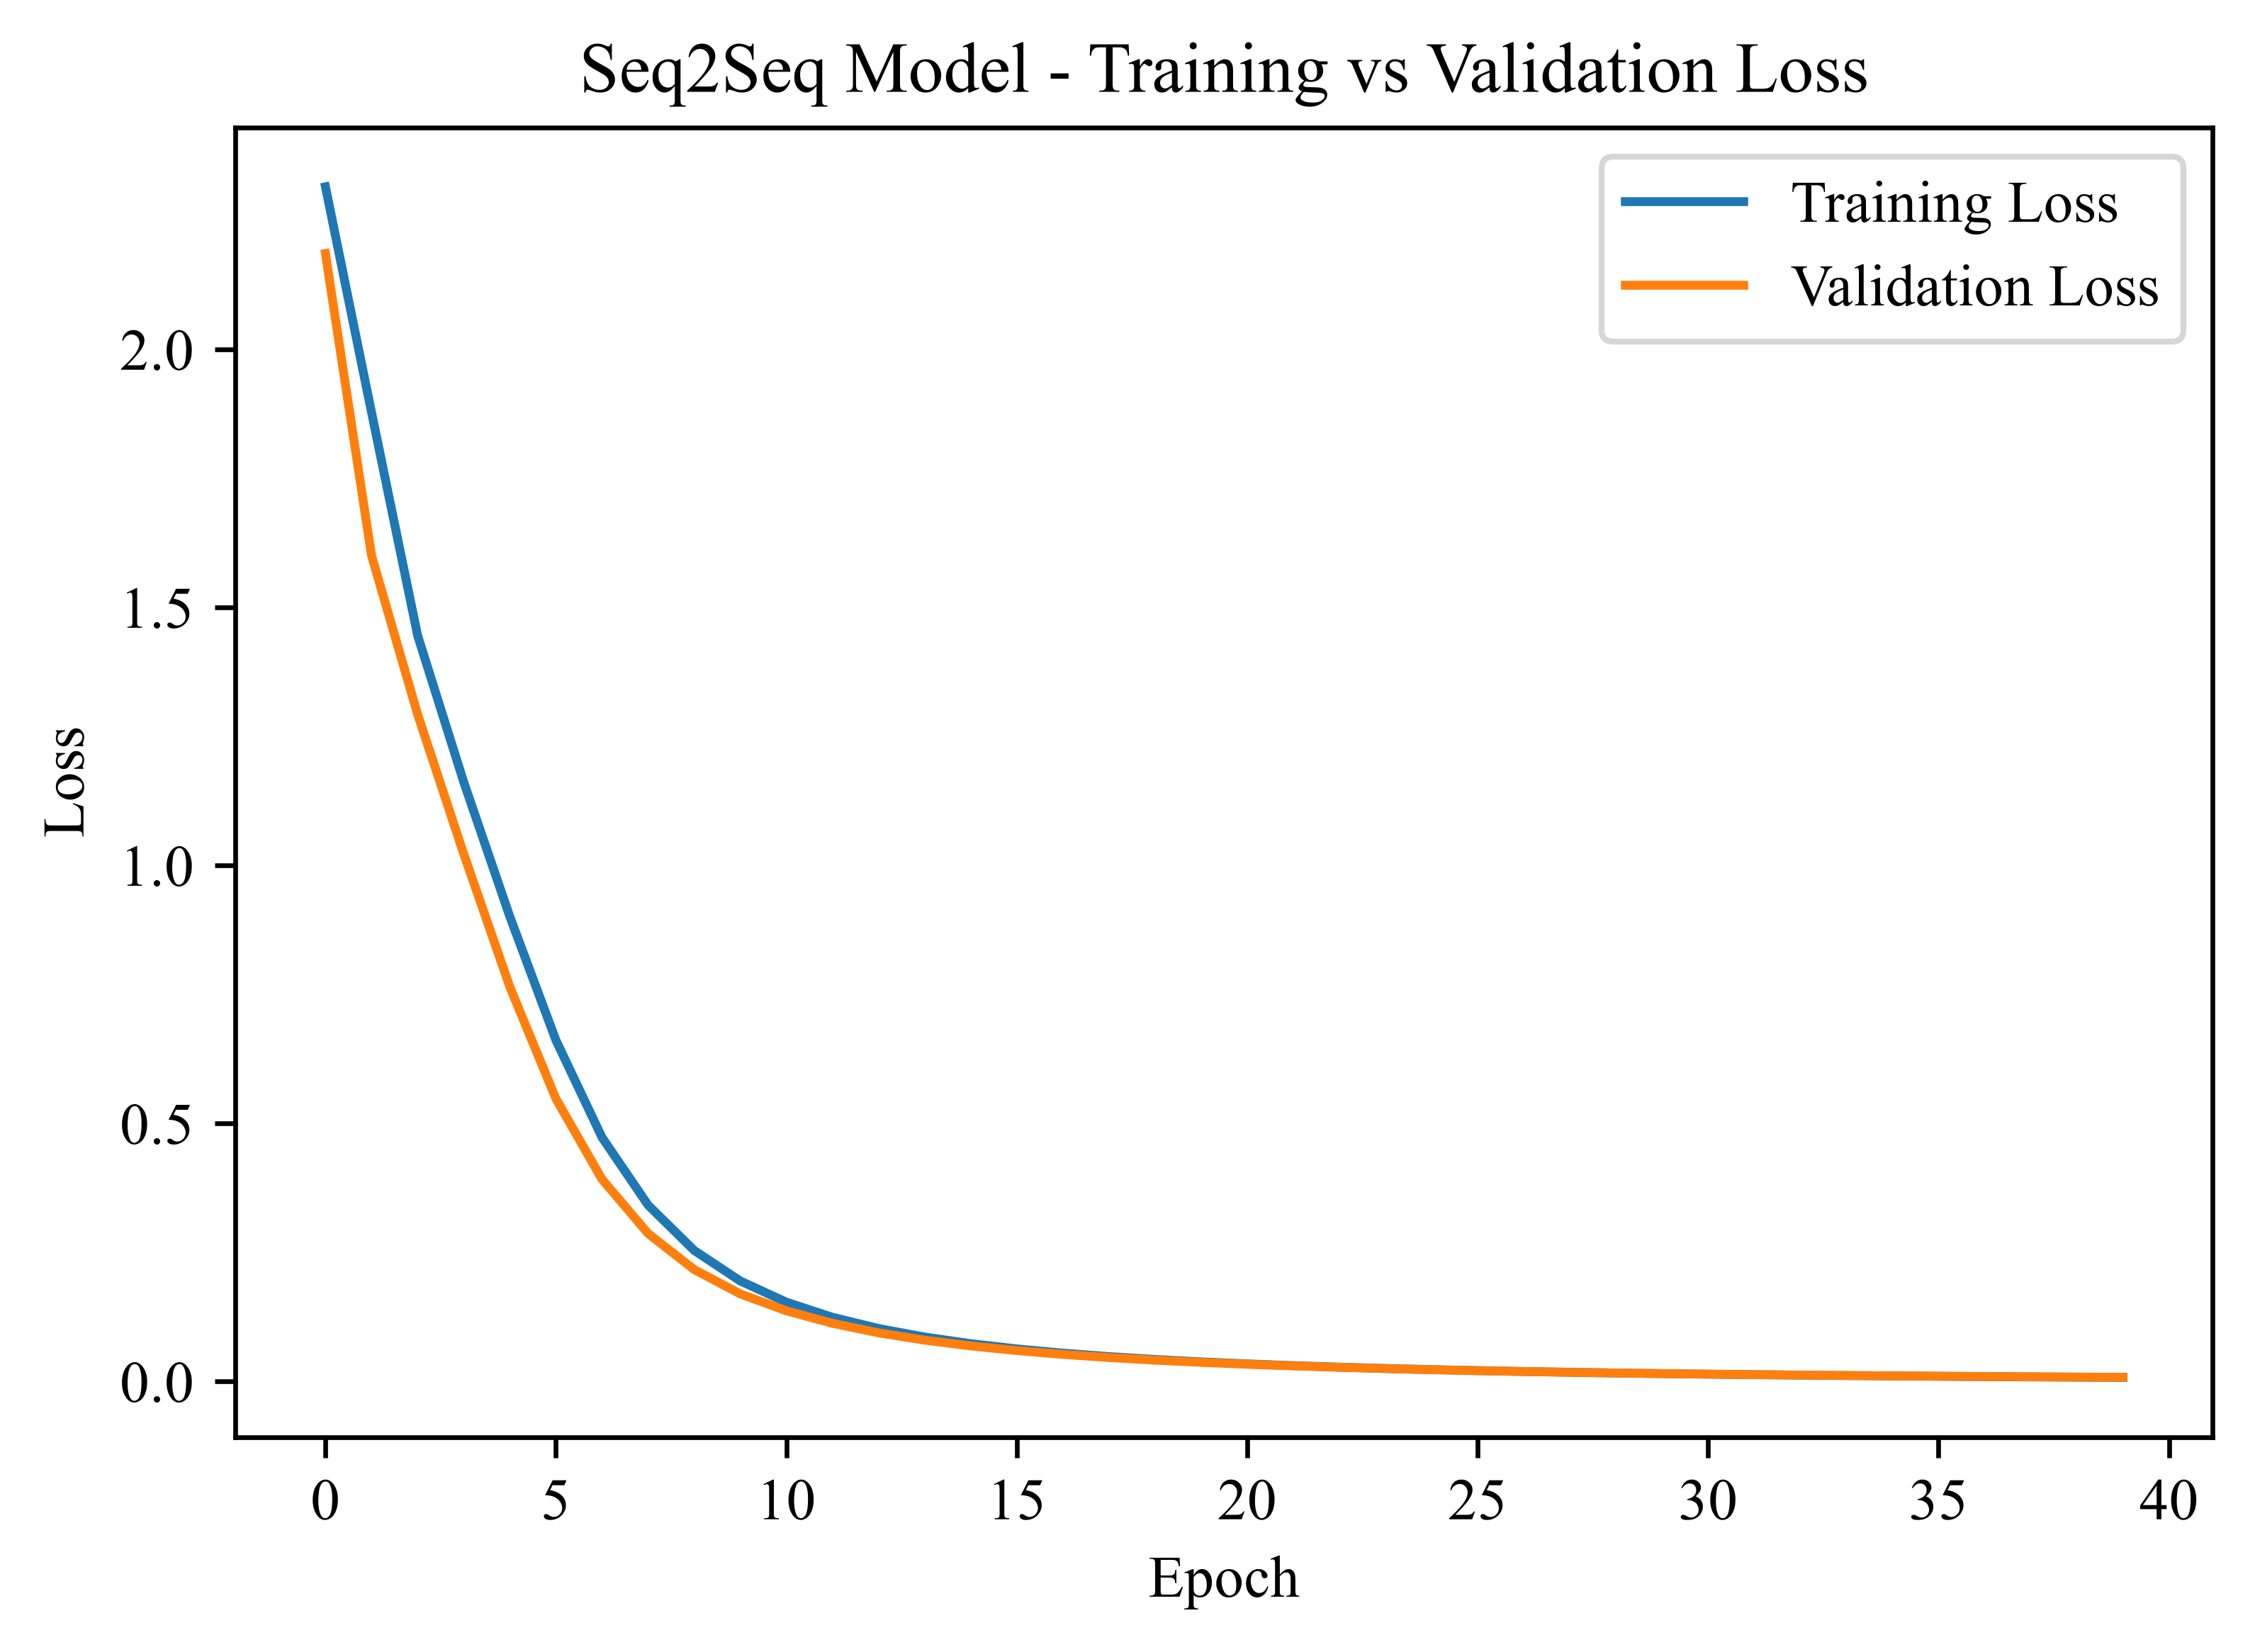

In [40]:
seq2seq_history = seq2seq_model.fit(
    [Xs_enc_train, Xs_dec_train], ys_train,
    validation_split=0.1, epochs=40, batch_size=64, verbose=0
)

plt.figure(figsize=(6, 4))
plt.plot(seq2seq_history.history['loss'], label='Training Loss')
plt.plot(seq2seq_history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Seq2Seq Model - Training vs Validation Loss")
plt.legend()
save_plot("seq2seq_loss_curve")
plt.show()

In [41]:
# building separate inference models for the encoder and decoder so the
# decoder can be run one step at a time at test time (no teacher forcing)
encoder_model = Model(encoder_inputs, encoder_states)

decoder_state_input_h = Input(shape=(LATENT_DIM,))
decoder_state_input_c = Input(shape=(LATENT_DIM,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]
dec_out_step, state_h2, state_c2 = decoder_lstm(decoder_inputs, initial_state=decoder_states_inputs)
dec_out_step = decoder_dense(dec_out_step)
decoder_model = Model([decoder_inputs] + decoder_states_inputs,
                       [dec_out_step, state_h2, state_c2])


def decode_sequence(input_seq_oh):
    states_value = encoder_model.predict(input_seq_oh[np.newaxis, :, :], verbose=0)
    target_seq = np.zeros((1, 1, VOCAB_SIZE + 1))
    target_seq[0, 0, START_TOKEN] = 1.0

    decoded_tokens = []
    for _ in range(SEQ_LEN):
        # pad target_seq to SEQ_LEN timesteps for the decoder input shape,
        # keeping only the first real step filled and the rest as zeros
        step_input = np.zeros((1, SEQ_LEN, VOCAB_SIZE + 1))
        step_input[0, 0, :] = target_seq[0, 0, :]
        output_tokens, h, c = decoder_model.predict([step_input] + states_value, verbose=0)
        sampled_token = np.argmax(output_tokens[0, 0, :])
        decoded_tokens.append(sampled_token)

        target_seq = np.zeros((1, 1, VOCAB_SIZE + 1))
        target_seq[0, 0, sampled_token] = 1.0
        states_value = [h, c]
    return decoded_tokens



In [42]:
# evaluating on the test set: token accuracy and sequence accuracy
correct_tokens, total_tokens = 0, 0
correct_sequences = 0
predicted_sequences = []

for i in range(len(Xs_enc_test)):
    pred_seq = decode_sequence(Xs_enc_test[i])
    true_seq = targets_test_int[i].tolist()
    predicted_sequences.append(pred_seq)

    correct_tokens += sum(p == t for p, t in zip(pred_seq, true_seq))
    total_tokens += SEQ_LEN
    if pred_seq == true_seq:
        correct_sequences += 1

token_accuracy = correct_tokens / total_tokens
sequence_accuracy = correct_sequences / len(Xs_enc_test)

print(f"Token accuracy   : {token_accuracy:.4f}")
print(f"Sequence accuracy: {sequence_accuracy:.4f}")
print(f"Final training loss  : {seq2seq_history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {seq2seq_history.history['val_loss'][-1]:.4f}")


Token accuracy   : 0.4930
Sequence accuracy: 0.0140
Final training loss  : 0.0077
Final validation loss: 0.0079


In [44]:
# displaying five test examples as required
sample_input_ints = np.argmax(Xs_enc_test[:5], axis=-1)
print("Sample Input Sequence -> Predicted Output")
for i in range(5):
    print(f"{i+1}. {sample_input_ints[i].tolist()} -> {predicted_sequences[i]}  "
          f"(actual: {targets_test_int[i].tolist()})")

# Inference: sequence accuracy is almost always lower than token accuracy
# because a sequence only counts as correct if every single token in it is
# right - a model that gets 3 out of 4 tokens correct on most sequences will
# have a high token accuracy (e.g. 90%+) but a much lower sequence accuracy,
# since even one wrong token anywhere ruins the whole sequence.


Sample Input Sequence -> Predicted Output
1. [4, 2, 2, 7] -> [np.int64(7), np.int64(2), np.int64(6), np.int64(6)]  (actual: [7, 2, 2, 4])
2. [7, 8, 9, 0] -> [np.int64(0), np.int64(7), np.int64(5), np.int64(5)]  (actual: [0, 9, 8, 7])
3. [0, 9, 5, 2] -> [np.int64(2), np.int64(5), np.int64(3), np.int64(5)]  (actual: [2, 5, 9, 0])
4. [1, 5, 8, 5] -> [np.int64(5), np.int64(5), np.int64(1), np.int64(1)]  (actual: [5, 8, 5, 1])
5. [5, 8, 1, 9] -> [np.int64(9), np.int64(1), np.int64(3), np.int64(4)]  (actual: [9, 1, 8, 5])


In [46]:
model_names = ["RNN", "LSTM", "GRU", "CNN-LSTM/GRU"]
consolidated = pd.DataFrame({
    "Model": model_names,
    "Accuracy": [results[m]["accuracy"] for m in ["RNN", "LSTM", "GRU"]]
                + [video_metrics["accuracy"] if video_metrics else np.nan],
    "Precision": [results[m]["precision"] for m in ["RNN", "LSTM", "GRU"]]
                 + [video_metrics["precision"] if video_metrics else np.nan],
    "Recall": [results[m]["recall"] for m in ["RNN", "LSTM", "GRU"]]
              + [video_metrics["recall"] if video_metrics else np.nan],
    "F1": [results[m]["f1"] for m in ["RNN", "LSTM", "GRU"]]
          + [video_metrics["f1"] if video_metrics else np.nan],
    "Parameters": [results[m]["params"] for m in ["RNN", "LSTM", "GRU"]]
                  + [video_metrics["params"] if video_metrics else np.nan],
})
print("Consolidated results (HAR models + video CNN-LSTM/GRU model):")
print("(CNN-LSTM/GRU row is NaN if the video understanding section was skipped)")
print(consolidated.to_string(index=False))

print("\nSeq2Seq reversal task - consolidated results:")
seq2seq_summary = pd.DataFrame({
    "Metric": ["Token Accuracy", "Sequence Accuracy", "Final Train Loss", "Final Val Loss"],
    "Value": [token_accuracy, sequence_accuracy,
              seq2seq_history.history['loss'][-1], seq2seq_history.history['val_loss'][-1]]
})
print(seq2seq_summary.to_string(index=False))


Consolidated results (HAR models + video CNN-LSTM/GRU model):
(CNN-LSTM/GRU row is NaN if the video understanding section was skipped)
       Model  Accuracy  Precision   Recall       F1  Parameters
         RNN  0.735324   0.737599 0.731882 0.731251        1974
        LSTM  0.884628   0.888957 0.885503 0.884341        6006
         GRU  0.843570   0.845832 0.843675 0.841344        4758
CNN-LSTM/GRU  0.956522   0.963636 0.955556 0.956471      168677

Seq2Seq reversal task - consolidated results:
           Metric    Value
   Token Accuracy 0.493000
Sequence Accuracy 0.014000
 Final Train Loss 0.007659
   Final Val Loss 0.007896


In [47]:
# 1. Replacing 32 recurrent units with 16 and 64 units, and comparing effect
unit_variation_results = {}
for units in [16, 32, 64]:
    res = train_and_evaluate("LSTM", X_train_norm, y_train, X_val_norm, y_val,
                              X_test_norm, y_test, units=units, epochs=20, verbose=0)
    unit_variation_results[units] = res
    print(f"units={units} -> acc={res['accuracy']:.4f}, f1={res['f1']:.4f}, "
          f"params={res['params']}, time={res['train_time']:.1f}s")

# Inference: increasing the number of recurrent units increases the model's
# capacity to represent more complex temporal patterns, which can raise
# accuracy up to a point, but it also increases the parameter count and
# training time, and beyond a certain size the extra units give diminishing
# returns and risk overfitting on a dataset this size.

[LSTM] acc=0.8273  prec=0.8326  rec=0.8278  f1=0.8257  params=2038  time=20.9s
units=16 -> acc=0.8273, f1=0.8257, params=2038, time=20.9s
[LSTM] acc=0.8371  prec=0.8427  rec=0.8377  f1=0.8356  params=6006  time=26.9s
units=32 -> acc=0.8371, f1=0.8356, params=6006, time=26.9s
[LSTM] acc=0.8802  prec=0.8850  rec=0.8805  f1=0.8796  params=20086  time=26.6s
units=64 -> acc=0.8802, f1=0.8796, params=20086, time=26.6s


In [48]:
# 2. Comparing GRU and LSTM using the same number of recurrent units (32,
#    already trained above) - simply comparing their stored results directly
print("LSTM (32 units): acc={:.4f}, params={}".format(
    results["LSTM"]["accuracy"], results["LSTM"]["params"]))
print("GRU  (32 units): acc={:.4f}, params={}".format(
    results["GRU"]["accuracy"], results["GRU"]["params"]))


LSTM (32 units): acc=0.8846, params=6006
GRU  (32 units): acc=0.8436, params=4758


In [49]:
# 3. Adding a second recurrent layer
def build_stacked_lstm(units=32, input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(units, return_sequences=True),
        layers.LSTM(units),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


stacked_model = build_stacked_lstm()
start = time.time()
stacked_history = stacked_model.fit(X_train_norm, y_train, validation_data=(X_val_norm, y_val),
                                     epochs=20, batch_size=32, verbose=0)
stacked_time = time.time() - start
stacked_pred = np.argmax(stacked_model.predict(X_test_norm, verbose=0), axis=1)
stacked_f1 = f1_score(y_test, stacked_pred, average='macro')
print(f"Single-layer LSTM F1: {results['LSTM']['f1']:.4f}")
print(f"Two-layer   LSTM F1: {stacked_f1:.4f}  (params={stacked_model.count_params()}, "
      f"time={stacked_time:.1f}s)")

# Inference: stacking a second recurrent layer lets the network build a
# higher-level temporal representation on top of the first layer's output,
# which can improve performance slightly, but it roughly doubles the number
# of recurrent parameters and training time, so the benefit needs to be
# weighed against that extra cost.

Single-layer LSTM F1: 0.8843
Two-layer   LSTM F1: 0.8561  (params=14326, time=52.7s)


In [50]:
# 4. Bidirectional LSTM vs unidirectional LSTM
def build_bidirectional_lstm(units=32, input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Bidirectional(layers.LSTM(units)),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


bidir_model = build_bidirectional_lstm()
start = time.time()
bidir_history = bidir_model.fit(X_train_norm, y_train, validation_data=(X_val_norm, y_val),
                                 epochs=20, batch_size=32, verbose=0)
bidir_time = time.time() - start
bidir_pred = np.argmax(bidir_model.predict(X_test_norm, verbose=0), axis=1)
bidir_f1 = f1_score(y_test, bidir_pred, average='macro')
print(f"Unidirectional LSTM F1: {results['LSTM']['f1']:.4f}")
print(f"Bidirectional  LSTM F1: {bidir_f1:.4f}  (params={bidir_model.count_params()}, "
      f"time={bidir_time:.1f}s)")

# Inference: a bidirectional LSTM processes the sequence both forwards and
# backwards and concatenates the two hidden representations, which usually
# improves accuracy since the model can use context from both directions in
# time, at the cost of roughly double the parameters and training time
# compared to a unidirectional LSTM.

Unidirectional LSTM F1: 0.8843
Bidirectional  LSTM F1: 0.8235  (params=11894, time=18.3s)


In [51]:
# 5. Effect of sequence length on computational cost is already covered in
#    Section 17 above (seq_len_results / seq_len_table), where training time
#    per model at T=32, 64 and 128 can be compared directly.


In [52]:
# 6. For the video task, LSTM vs GRU comparison using identical CNN features
#    (only runs if the video understanding section above was executed)
if CV2_AVAILABLE and VIDEO_CLASSES:
    video_model_gru = build_video_model("GRU")
    video_history_gru = video_model_gru.fit(Xv_train, yv_train, validation_data=(Xv_test, yv_test),
                                             epochs=30, batch_size=8, verbose=0)
    yv_pred_gru = np.argmax(video_model_gru.predict(Xv_test, verbose=0), axis=1)
    print("Video LSTM F1:", f1_score(yv_test, yv_pred, average='macro'))
    print("Video GRU  F1:", f1_score(yv_test, yv_pred_gru, average='macro'))


Video LSTM F1: 0.9564705882352941
Video GRU  F1: 0.9564705882352941


In [53]:
# 7. Modifying the seq2seq task so the output has a different length from the
#    input - here the task is: take a length-4 input sequence and output only
#    its first half, reversed (length 4 in, length 2 out)
OUT_LEN = SEQ_LEN // 2  # =2, deliberately different from SEQ_LEN (=4)

short_targets = seq_inputs[:, :OUT_LEN][:, ::-1]
short_decoder_input = np.concatenate(
    [np.full((NUM_SAMPLES, 1), START_TOKEN), short_targets[:, :-1]], axis=1
)

dec_in_short_oh = to_categorical(short_decoder_input, num_classes=VOCAB_SIZE + 1)
dec_out_short_oh = to_categorical(short_targets, num_classes=VOCAB_SIZE + 1)

(Xs2_enc_train, Xs2_enc_test, Xs2_dec_train, Xs2_dec_test,
 ys2_train, ys2_test, short_targets_train, short_targets_test) = train_test_split(
    enc_in_oh, dec_in_short_oh, dec_out_short_oh, short_targets, test_size=0.1, random_state=42
)

# encoder is unchanged (still reads all SEQ_LEN=4 input steps); the decoder
# is now only unrolled for OUT_LEN=2 steps, which is what makes the output
# sequence length different from the input sequence length
encoder_inputs_v2 = Input(shape=(SEQ_LEN, VOCAB_SIZE + 1))
encoder_lstm_v2 = layers.LSTM(LATENT_DIM, return_state=True)
_, state_h_v2, state_c_v2 = encoder_lstm_v2(encoder_inputs_v2)

decoder_inputs_v2 = Input(shape=(OUT_LEN, VOCAB_SIZE + 1))
decoder_lstm_v2 = layers.LSTM(LATENT_DIM, return_sequences=True, return_state=True)
decoder_outputs_v2, _, _ = decoder_lstm_v2(decoder_inputs_v2, initial_state=[state_h_v2, state_c_v2])
decoder_dense_v2 = layers.Dense(VOCAB_SIZE + 1, activation='softmax')
decoder_outputs_v2 = decoder_dense_v2(decoder_outputs_v2)

seq2seq_model_v2 = Model([encoder_inputs_v2, decoder_inputs_v2], decoder_outputs_v2)
seq2seq_model_v2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

seq2seq_v2_history = seq2seq_model_v2.fit(
    [Xs2_enc_train, Xs2_dec_train], ys2_train,
    validation_split=0.1, epochs=40, batch_size=64, verbose=0
)


In [54]:
# quick token/sequence accuracy check using teacher-forced predictions on the
# test set (a full step-by-step inference decoder would follow the same
# pattern as decode_sequence() above, just unrolled OUT_LEN times instead of
# SEQ_LEN times)
pred_probs_v2 = seq2seq_model_v2.predict([Xs2_enc_test, Xs2_dec_test], verbose=0)
pred_tokens_v2 = np.argmax(pred_probs_v2, axis=-1)

token_acc_v2 = np.mean(pred_tokens_v2 == short_targets_test)
seq_acc_v2 = np.mean(np.all(pred_tokens_v2 == short_targets_test, axis=1))

print(f"Variable-length seq2seq (4 -> 2) token accuracy   : {token_acc_v2:.4f}")
print(f"Variable-length seq2seq (4 -> 2) sequence accuracy: {seq_acc_v2:.4f}")
print("Example: input", seq_inputs[0].tolist(), "-> target", short_targets[0].tolist(),
      "-> predicted", pred_tokens_v2[0].tolist())

# Inference: making the decoder shorter than the encoder shows that the
# encoder-decoder framework doesn't require matching input/output lengths -
# the encoder's final state is just a fixed-size context vector, and the
# decoder can be unrolled for as many or as few steps as the target task
# needs, independent of how long the input sequence was.

Variable-length seq2seq (4 -> 2) token accuracy   : 1.0000
Variable-length seq2seq (4 -> 2) sequence accuracy: 1.0000
Example: input [0, 7, 6, 4] -> target [7, 0] -> predicted [2, 4]


In [ ]:
# ## Discussion Questions (to write in report)
#
# 1. A recurrent neural network (RNN) is a network with a hidden state that
#    is updated at every time step and fed back into itself, letting it use
#    information from earlier in the sequence when processing later inputs.
#
# 2. The hidden state is a compressed summary of everything the network has
#    seen in the sequence so far, updated at every time step.
#
# 3. Sequence order matters because the meaning of the data often depends on
#    the order of events (e.g. footstep timing for WALKING); shuffling the
#    time steps would destroy that information.
#
# 4. A feed-forward network maps a fixed input directly to an output with no
#    memory of previous inputs, while an RNN reuses a hidden state across
#    time steps so it can model dependencies between elements of a sequence.
#
# 5. Backpropagation Through Time (BPTT) unrolls the RNN across all time
#    steps and backpropagates the loss gradient through each of those steps,
#    accumulating gradients for the shared weights.
#
# 6. Gradients can vanish during BPTT because the same weight matrix is
#    multiplied repeatedly across many time steps; if its values are less
#    than 1, the repeated multiplication shrinks the gradient toward zero.
#
# 7. Gradients can explode when the repeated weight multiplication instead
#    grows the gradient magnitude very large, causing unstable updates.
#
# 8. Long-term dependencies are relationships between elements that are far
#    apart in the sequence (e.g. the start and end of a long sentence or a
#    long sensor window), which plain RNNs struggle to capture.
#
# 9. The LSTM cell state acts as a memory highway that carries information
#    across many time steps with only minor, gate-controlled modifications,
#    which helps it avoid the vanishing gradient problem of plain RNNs.
#
# 10. The forget gate decides what to discard from the cell state, the input
#     gate decides what new information to add, and the output gate decides
#     what part of the cell state to expose as the hidden state.
#
# 11. The reset gate controls how much of the previous hidden state to forget
#     when computing the candidate state, and the update gate controls the
#     balance between the previous hidden state and the new candidate state.
#
# 12. LSTM has a separate cell state and three gates, while GRU merges the
#     cell and hidden state into one and uses only two gates, making GRU
#     simpler and usually faster to train with comparable accuracy.
#
# 13. GRU uses a simpler gating mechanism than LSTM because it combines the
#     forget and input gates into a single update gate and drops the
#     separate cell state, which reduces the number of parameters while
#     still controlling what information is kept or discarded.
#
# 14. RNN, LSTM and GRU should be compared using the same experimental
#     settings (data, split, optimizer, batch size, epochs) so that any
#     difference in performance can be attributed to the architecture itself
#     rather than to differences in the training setup.
#
# 15. A confusion matrix reveals which specific classes are being confused
#     with each other, something a single overall accuracy number hides
#     completely.
#
# 16. Macro F1-score is reported for multi-class classification because it
#     treats every class equally regardless of how many samples it has,
#     which avoids a model's performance being dominated by the majority
#     class the way plain accuracy can be.
#
# 17. Sequence length determines how much temporal context the model has
#     access to; too short a sequence may not contain enough information to
#     distinguish activities, while a longer sequence gives more context but
#     costs more to process.
#
# 18. A CNN can be used as a feature extractor for video because it has
#     already learned to recognise general visual patterns from large image
#     datasets, so it can turn each frame into a compact, meaningful feature
#     vector without needing to be retrained from scratch.
#
# 19. The CNN extracts spatial information from each individual frame, such
#     as objects, textures and scene layout.
#
# 20. The recurrent network learns temporal information: how the CNN's
#     per-frame features change and evolve across the sequence of frames.
#
# 21. CNN features are arranged as a sequence before being given to the
#     LSTM/GRU because the recurrent network expects an ordered sequence of
#     feature vectors (one per frame, in time order) so it can learn how the
#     visual content evolves over the course of the video.
#
# 22. The encoder reads the entire input sequence and compresses it into a
#     fixed context representation (its final hidden and cell states); the
#     decoder then uses that context to generate the output sequence one
#     element at a time.
#
# 23. Teacher forcing is a training technique where the decoder is fed the
#     ground-truth previous token as input at each step instead of its own
#     prediction, which makes training faster and more stable.
#
# 24. Token accuracy measures the fraction of individual output tokens
#     predicted correctly, while sequence accuracy measures the fraction of
#     entire output sequences that are completely correct; sequence accuracy
#     is stricter since one wrong token anywhere makes the whole sequence wrong.
#
# 25. The test set must remain untouched during model selection so that the
#     final reported performance is an honest estimate of how the model
#     generalises to unseen data, rather than a number inflated by tuning
#     decisions made using that same data.